<a href="https://colab.research.google.com/github/tejasmanojav/P-B-and-Friends/blob/main/PB_index_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# P/B and Friends (v2): Can Cheap, Profitable Stocks Beat the Market?

**Question:** If I buy the cheapest stocks by price-to-book (P/B), and only keep the ones that actually make money, do I beat the market?

I test this in two parts:
- **Part A: sector by sector.** Pick stocks inside each of 11 sectors and compare with that sector's ETF. I add one filter at a time: pure P/B → clean P/B → + ROA → + ROE → both.
- **Part B: one portfolio across all sectors.** Pick from the 500 biggest US stocks and compare with SPY. I start with all 500 stocks and add one filter at a time, to see which filters weed out losers. Each step is run with the same cutoffs for every stock (raw) and with each stock compared only with its own sector (sector-normalized).

**Layout:** 1. Load data → 2. Data sanity checks → 3. How the backtest works → Part A → Part B → Overall comparison → Appendix (engine walkthrough, sanity checks, grid search, report tables).

**Data:** SimFin free tier (US stocks, about the last 5 years): daily prices, quarterly balance sheets and income statements, and sector labels. Benchmark ETFs come from yfinance.

**How to run:** add your `SIMFIN_API_KEY` in Colab Secrets (see below), then **Runtime → Run all**.

**v2 notes:** This is a cleaned-up redo of my first version. SimFin's free data only covers the latest ~5 years, so the numbers are different from v1 anyway. I also made a few small fixes:
- Company numbers are only used after the day they were published (not on the quarter-end date).
- The market cap, book value and P/B percentile filters now really get applied.
- Stocks that stop trading (delisted) drop out instead of sitting in the data with a frozen price.
- CAGR counts every quarter, and QuantStats is set to quarterly data.

# 1. Load the Data

## SimFin API Key Setup


1. Click on the "Secrets" tab in the left-hand panel.
2. Click "+ New secret" and set the **Name** to `SIMFIN_API_KEY`.

3. Paste your SimFin API key into the **Value** field.
4. Make sure to enable "Notebook access" for this secret.

Once done, the notebook will be able to securely access your API key.

### **Setup & Package Installation**

This cell installs necessary Python packages (`yfinance`, `simfin`, `quantstats`) and imports them for use in the notebook. It also configures `matplotlib` for plotting and sets up the `simfin` data directory for caching downloaded data.

In [ ]:
# ==============================================================================
# 1. Setup & Package Installation
# ==============================================================================
!pip install -q yfinance simfin quantstats

import yfinance as yf
import simfin as sf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import quantstats as qs
from collections import Counter


plt.style.use('seaborn-v0_8-whitegrid')

# SimFin Configuration
# Downloads bulk CSVs once and caches them to disk for lightning-fast reloading
sf.set_data_dir('~/Downloads/simfin_data/')

import warnings
warnings.filterwarnings('ignore')
print("✅ Environment configured. SimFin caching directory set up!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.8/96.8 kB 1.9 MB/s eta 0:00:00
✅ Environment configured. SimFin caching directory set up!


### **SimFin API Key Loading**

This cell securely loads your SimFin API key from Colab secrets, ensuring it's not exposed directly in the notebook. It then configures the `simfin` library with this key.

In [ ]:
# Used to securely store your API key
from google.colab import userdata

# Retrieve the API key from Colab secrets, remove all carriage returns and newlines, then strip any remaining whitespace
SIMFIN_API_KEY_RAW = userdata.get('SIMFIN_API_KEY')
SIMFIN_API_KEY = SIMFIN_API_KEY_RAW.replace('\r', '').replace('\n', '').strip()
sf.set_api_key(SIMFIN_API_KEY)

print("✅ SimFin API key loaded from Colab secrets.")

✅ SimFin API key loaded from Colab secrets.


### **Load Raw Data from SimFin**

This cell loads various financial datasets (companies, industries, balance sheets, income statements, and share prices) from SimFin into pandas DataFrames. It also prints the date ranges of the loaded price and fundamental data.

In [ ]:
print("📥 Loading bulk data from SimFin (Local cache will be used if already downloaded)...")

# Load raw dataframes
df_companies_raw = sf.load_companies(market='us')
df_industries_raw = sf.load_industries()
df_balance = sf.load_balance(variant='quarterly', market='us')
df_income = sf.load_income(variant='quarterly', market='us')
df_prices = sf.load_shareprices(variant='daily', market='us')

start_dt = df_prices.index.get_level_values('Date').min().strftime('%Y-%m-%d')
end_dt = df_prices.index.get_level_values('Date').max().strftime('%Y-%m-%d')

print(f"Price data loaded from {start_dt} to {end_dt}")
print(f"Income data loaded from {df_income.index.get_level_values('Report Date').min().strftime('%Y-%m-%d')} to {df_income.index.get_level_values('Report Date').max().strftime('%Y-%m-%d')}")
print(f"Balance data loaded from {df_balance.index.get_level_values('Report Date').min().strftime('%Y-%m-%d')} to {df_balance.index.get_level_values('Report Date').max().strftime('%Y-%m-%d')}")

📥 Loading bulk data from SimFin (Local cache will be used if already downloaded)...
Dataset "us-companies" not on disk.
- Downloading ... 100.0%
- Extracting zip-file ... Done!
- Loading from disk ... Done!
Dataset "industries" not on disk.
- Downloading ... 100.0%
- Extracting zip-file ... Done!
- Loading from disk ... Done!
Dataset "us-balance-quarterly" not on disk.
- Downloading ... 100.0%
- Extracting zip-file ... Done!
- Loading from disk ... Done!
Dataset "us-income-quarterly" not on disk.
- Downloading ... 100.0%
- Extracting zip-file ... Done!
- Loading from disk ... Done!
Dataset "us-shareprices-daily" not on disk.
- Downloading ... 100.0%
- Extracting zip-file ... Done!
- Loading from disk ... Done!
Price data loaded from 2020-10-29 to 2025-10-02
Income data loaded from 2020-10-31 to 2025-09-30
Balance data loaded from 2020-10-31 to 2025-09-30


### **Process `df_companies` with Sector Information**

This cell prepares the `df_companies` DataFrame by merging it with `df_industries` to include `Sector` information for each company. It sets 'Ticker' as the index and displays the head of the processed DataFrame and unique sectors.

In [ ]:
# Reset df_industries_raw index to make 'IndustryId' a column for merging
df_industries = df_industries_raw.reset_index()
# Ensure 'IndustryId' in df_industries is of nullable integer type
df_industries['IndustryId'] = df_industries['IndustryId'].astype('Int64')

# Start with df_companies_raw which has 'Ticker' as its index.
# Reset its index to make 'Ticker' a column, then create df_companies.
df_companies = df_companies_raw.reset_index().copy()
df_companies['IndustryId'] = df_companies['IndustryId'].astype('Int64')

# Merge df_companies (now with 'Ticker' as a column) with df_industries
# The merge is performed on the 'IndustryId' columns.
df_companies = pd.merge(
    df_companies,
    df_industries[['IndustryId', 'Sector']],
    on='IndustryId',
    how='left'
)

# Set 'Ticker' back as the index for df_companies after the merge
df_companies = df_companies.set_index('Ticker')

print("✅ df_companies prepared with 'Sector' column and 'Ticker' as index.")
# Display the first few rows and info to confirm structure
display(df_companies.head())
print(df_companies.info())

# Print distinct sectors available in the dataset
print("\n🌍 Distinct Sectors available for backtesting:")
print(df_companies['Sector'].dropna().unique().tolist())

✅ df_companies prepared with 'Sector' column and 'Ticker' as index.


,SimFinId,Company Name,IndustryId,ISIN,End of financial year (month),Number Employees,Business Summary,Market,CIK,Main Currency,Sector
Ticker,,,,,,,,,,,
A,45846,AGILENT TECHNOLOGIES INC,106001,US00846U1016,10.0,16400.0,Agilent Technologies Inc is engaged in life sc...,us,1090872.0,USD,Healthcare
A21,1333027,Li Auto Inc.,<NA>,NaN,12.0,NaN,NaN,us,1791706.0,USD,NaN
AA,367153,Alcoa Corp,110004,US0138721065,12.0,12900.0,Alcoa Corp is an integrated aluminum company. ...,us,1675149.0,USD,Basic Materials
AAC,7962652,Ares Acquisition Corporation,104002,US0003071083,12.0,NaN,Ares Acquisition Corporation does not have sig...,us,1829432.0,USD,Financial Services
AACB,18959140,Artius II Acquisition Inc. Class A Ordinary Sh...,104002,KYG0509J1076,12.0,NaN,Artius II Acquisition Inc. is a blank check co...,us,2034334.0,USD,Financial Services


<class 'pandas.core.frame.DataFrame'>
Index: 6592 entries, A to nan
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   SimFinId                       6592 non-null   int64  
 1   Company Name                   6556 non-null   object 
 2   IndustryId                     6278 non-null   Int64  
 3   ISIN                           5391 non-null   object 
 4   End of financial year (month)  6557 non-null   float64
 5   Number Employees               5755 non-null   float64
 6   Business Summary               6293 non-null   object 
 7   Market                         6592 non-null   object 
 8   CIK                            6580 non-null   float64
 9   Main Currency                  6592 non-null   object 
 10  Sector                         6278 non-null   object 
dtypes: Int64(1), float64(3), int64(1), object(6)
memory usage: 624.4+ KB
None

🌍 Distinct Sectors available for backte

### **Data Cleanup: Share Counts**

While building Part B I found a data problem. On 2023-06-30 the "biggest" company in my top 500 was Dolby (DLB) at \$7.56 trillion, bigger than Apple. Dolby is really worth about \$7.5 billion. BLKB and MRTX had the same problem. Their share counts in the data are about 1,000 times too big (probably a units mix-up), so their market cap and P/B come out 1,000 times too big too. These fake giants push real companies out of the top 500 and bend the size percentiles.

A company's value can jump 100x when it is tiny, but its **share count** almost never changes 50x from one report to the next. So I check every balance-sheet share count three ways:
1. **Time series:** against the company's **baseline** = the average of its last 3 good reports. A jump or drop of 50x+ from the baseline is flagged, and it stays flagged for as long as it lasts (so a mistake that repeats for 2-3 quarters is caught too). If a new level lasts 4 reports in a row and is steady, I accept it as real (like a merger).
2. **Second source:** against the share count in SimFin's daily price file (if the file has one).
3. **Does it add up:** a P/B above 1,000 means the share count and the book value don't fit together.

A share count that fails is removed (treated as missing), not guessed. Then I spot-check the biggest ones against yfinance.

The details (the biggest flagged companies, DLB/BLKB/MRTX report by report, and the yfinance spot check) are in **Appendix B**.

In [ ]:
# ==============================================================================
# 1b. Data cleanup: balance-sheet share counts
# ==============================================================================
UNIT_JUMP = 50    # a real share count almost never moves 50x; a units mix-up moves it ~1000x
MAX_PB = 1000     # P/B above this = the numbers don't fit together
ANCHOR_N = 3      # baseline = average of the last 3 accepted values
PERSIST = 4       # a new level that lasts 4 reports in a row (and is steady) is accepted as real

def baseline_flags(df, col, k, persist=PERSIST):
    # True where a value is k times above or below the company's baseline (average of its last ANCHOR_N
    # accepted values). Flagged values don't enter the baseline, so a mistake that repeats is still caught.
    # If a new level lasts `persist` reports in a row and is steady (within 3x), it's accepted as real.
    flags = pd.Series(False, index=df.index)
    d = df[['Ticker', 'Report Date', col]].dropna().sort_values(['Ticker', 'Report Date'])
    for _, grp in d.groupby('Ticker', sort=False):
        vals, idx = grp[col].abs().to_numpy(), grp.index.to_numpy()
        pos = vals[vals > 0]
        if len(pos) == 0:
            continue
        start = np.median(pos)             # before there are 3 accepted values: the company's median
        accepted, run, flagged = [], [], set()
        for i, x in enumerate(vals):
            base = np.mean(accepted[-ANCHOR_N:]) if accepted else start
            if x > 0 and base / k <= x <= base * k:
                accepted.append(x)
                run = []
                continue
            run.append(i)
            flagged.add(i)
            last = vals[run[-persist:]]
            if len(run) >= persist and last.min() > 0 and last.max() / last.min() <= 3:
                flagged -= set(run[-persist:])     # a real new level (merger, split, ...)
                accepted = list(last)
                run = []
        if flagged:
            flags.loc[idx[sorted(flagged)]] = True
    return flags

print("Price file columns:", list(df_prices.columns))
price_col = 'Adj. Close'

sh = df_balance.reset_index()[['Ticker', 'Report Date', 'Shares (Basic)', 'Total Equity']].copy()
sh['Report Date'] = pd.to_datetime(sh['Report Date'])
sh = sh[sh['Shares (Basic)'] > 0].sort_values(['Ticker', 'Report Date'])
sh['Company median'] = sh.groupby('Ticker')['Shares (Basic)'].transform('median')
sh['vs median'] = sh['Shares (Basic)'] / sh['Company median']

# Price on the report date -> apparent market cap and P/B
px = (df_prices[price_col].reset_index().dropna()
      .rename(columns={'Date': 'Report Date', price_col: 'Price at report'}).sort_values('Report Date'))
sh = pd.merge_asof(sh.sort_values('Report Date'), px, on='Report Date', by='Ticker',
                   direction='backward', tolerance=pd.Timedelta(days=10))
sh['Apparent market cap'] = sh['Shares (Basic)'] * sh['Price at report']
sh['Apparent P/B'] = sh['Apparent market cap'] / sh['Total Equity'].where(sh['Total Equity'] > 0)

# Second source: share count in the daily price file
if 'Shares Outstanding' in df_prices.columns:
    so = (df_prices['Shares Outstanding'].reset_index().dropna()
          .rename(columns={'Date': 'Report Date', 'Shares Outstanding': 'Price-file shares'}))
    so = so[so['Price-file shares'] > 0].sort_values('Report Date')
    sh = pd.merge_asof(sh.sort_values('Report Date'), so, on='Report Date', by='Ticker',
                       direction='nearest', tolerance=pd.Timedelta(days=45))
    sh['vs price file'] = sh['Shares (Basic)'] / sh['Price-file shares']
else:
    sh['Price-file shares'] = np.nan
    sh['vs price file'] = np.nan

check1 = baseline_flags(sh, 'Shares (Basic)', UNIT_JUMP)
check2 = (sh['vs price file'] >= UNIT_JUMP) | (sh['vs price file'] <= 1 / UNIT_JUMP)
check3 = sh['Apparent P/B'] > MAX_PB
second_source_agrees = sh['vs price file'].between(1 / 5, 5)
sh['Flag'] = check2 | ((check1 | check3) & ~second_source_agrees)
flagged = sh[sh['Flag']].copy()
names = df_companies['Company Name']
flagged['Company'] = flagged['Ticker'].map(names[~names.index.duplicated()])

print(f"Checked {len(sh):,} balance-sheet share counts from {sh['Ticker'].nunique():,} companies")
print(f"  1. time series (vs company baseline): {check1.sum():,}")
print(f"  2. second source (price file):       {check2.sum():,}"
      + ("" if 'Shares Outstanding' in df_prices.columns else "  (price file has no share count)"))
print(f"  3. P/B above {MAX_PB:,}:                  {check3.sum():,}")
print(f"→ removed {len(flagged):,} share counts from {flagged['Ticker'].nunique()} companies")
biggest = flagged.sort_values('Apparent market cap', ascending=False).drop_duplicates('Ticker').head(15)
share_audit = {'sh': sh, 'flagged': flagged, 'biggest': biggest}   # shown in Appendix B

# Remove the flagged share counts (they become missing, so the stock is skipped that quarter)
bad_keys = set(zip(flagged['Ticker'], flagged['Report Date']))
idx_names = [n for n in df_balance.index.names if n is not None]
bal_flat = df_balance.reset_index()
is_bad = [(t, pd.Timestamp(d)) in bad_keys for t, d in zip(bal_flat['Ticker'], bal_flat['Report Date'])]
bal_flat.loc[is_bad, 'Shares (Basic)'] = np.nan
df_balance = bal_flat.set_index(idx_names) if idx_names else bal_flat
print(f"✅ Cleaned df_balance: {sum(is_bad):,} share counts set to missing")

Price file columns: ['SimFinId', 'Open', 'High', 'Low', 'Close', 'Adj. Close', 'Volume', 'Dividend', 'Shares Outstanding']
Checked 47,535 balance-sheet share counts from 3,690 companies
  1. time series (vs company baseline): 399
  2. second source (price file):       526
  3. P/B above 1,000:                  144
→ removed 592 share counts from 265 companies
✅ Cleaned df_balance: 592 share counts set to missing


### **Data Cleanup: Assets, Equity, Net Income and Prices**

If the share count can be 1,000x off, other numbers can be too. P/B uses equity, ROA uses net income and assets, ROE uses net income and equity. I use the same idea: a number that is way off from where it should be is a mistake, not real business.
- **Total assets and total liabilities:** the same baseline check as share counts (50x+ away from the average of the last 3 good reports; a new level that lasts 4 reports is accepted). These numbers are steady for a real business: it doesn't go 100M → 100B → 100B → 100M.
- Equity and net income can honestly swing through zero (a loss, a big write-off), so a baseline doesn't work for them. I check them against total assets instead, which were already baseline-checked.
- **The balance sheet must add up:** assets = liabilities + equity. If one side is 50x+ bigger than the other, one of the numbers is wrong.
- **Equity** can't be bigger than assets (1.5x allowed for rounding). (Negative equity bigger than the assets can be real: a tiny company deep in debt.)
- **Net income** for one quarter can't be 10x+ the company's total assets. (A tiny shell can lose more than it owns, but not 10x in one quarter.)
- **Prices (daily blips):** a price 3x+ away from the median of the 11 trading days around it is a bad print, and is removed (the last good price is used instead). A real jump that lasts, like CODQL going from \$0.01 to \$0.78, moves the median too, so it isn't touched. This matters: in the first run, a bad last price for Eargo (EAR) before it stopped trading showed up as a +2,622% quarter.

Numbers that fail are removed (treated as missing), not guessed.

Examples of each kind of bad number are in **Appendix B**.

In [ ]:
# ==============================================================================
# 1c. Data cleanup: assets, equity, net income (and a report on price ticks)
# ==============================================================================
bal_flat = df_balance.reset_index()
bal_flat['Report Date'] = pd.to_datetime(bal_flat['Report Date'])
inc_flat = df_income.reset_index()
inc_flat['Report Date'] = pd.to_datetime(inc_flat['Report Date'])

A, E = bal_flat['Total Assets'], bal_flat['Total Equity']
ratio_A = A / bal_flat['Total Assets'].where(A > 0).groupby(bal_flat['Ticker']).transform('median')
bad_assets_ts = baseline_flags(bal_flat, 'Total Assets', UNIT_JUMP) | (A <= 0)
has_L = 'Total Liabilities' in bal_flat.columns
bad_liab_ts = baseline_flags(bal_flat, 'Total Liabilities', UNIT_JUMP) if has_L else pd.Series(False, index=bal_flat.index)
if has_L:
    bal_flat.loc[bad_liab_ts, 'Total Liabilities'] = np.nan   # so a bad liabilities number can't fail the add-up check

if 'Total Liabilities' in bal_flat.columns:
    side_a, side_b = A.abs(), (bal_flat['Total Liabilities'] + E).abs()
    mismatch = np.maximum(side_a, side_b) / np.minimum(side_a, side_b).where(np.minimum(side_a, side_b) > 0)
    bad_identity = mismatch >= UNIT_JUMP
else:
    print("(no 'Total Liabilities' column, skipping the add-up check)")
    bad_identity = pd.Series(False, index=bal_flat.index)

bad_equity = (E > 1.5 * A) & (A > 0)   # negative equity bigger than assets can be real (deeply indebted shells)

# Net income vs the total assets from the same report
NI_MAX_X_ASSETS = 10   # tiny shells can lose more than their assets; 10x+ in one quarter = a units mistake
ni = inc_flat[['Ticker', 'Report Date', 'Net Income']].merge(
    bal_flat[['Ticker', 'Report Date', 'Total Assets']].drop_duplicates(['Ticker', 'Report Date']),
    on=['Ticker', 'Report Date'], how='left')
bad_ni = (ni['Net Income'].abs() > NI_MAX_X_ASSETS * ni['Total Assets']) & (ni['Total Assets'] > 0)

summary = pd.DataFrame({
    'Checked': [A.notna().sum(), (bal_flat['Total Liabilities'].notna() | bad_liab_ts).sum() if has_L else 0,
                bal_flat[['Total Assets', 'Total Equity']].notna().all(axis=1).sum(),
                E.notna().sum(), ni['Net Income'].notna().sum()],
    'Removed': [bad_assets_ts.sum(), bad_liab_ts.sum(), bad_identity.sum(), bad_equity.sum(), bad_ni.sum()]},
    index=['Total assets (vs baseline)', 'Total liabilities (vs baseline)', 'Balance sheet adds up',
           'Equity vs assets', 'Net income vs assets'])
summary['Companies'] = [bal_flat.loc[bad_assets_ts, 'Ticker'].nunique(), bal_flat.loc[bad_liab_ts, 'Ticker'].nunique(),
                        bal_flat.loc[bad_identity, 'Ticker'].nunique(),
                        bal_flat.loc[bad_equity, 'Ticker'].nunique(), ni.loc[bad_ni, 'Ticker'].nunique()]
num_audit = {'summary': summary, 'examples': []}   # shown in Appendix B

names = df_companies['Company Name']
names = names[~names.index.duplicated()]
for title, frame, mask, cols in [
        ('Total assets far from the company baseline', bal_flat.assign(**{'vs median': ratio_A}), bad_assets_ts,
         ['Ticker', 'Report Date', 'Total Assets', 'vs median']),
        ("Balance sheet doesn't add up", bal_flat, bad_identity, ['Ticker', 'Report Date', 'Total Assets', 'Total Equity']),
        ('Equity bigger than assets', bal_flat, bad_equity, ['Ticker', 'Report Date', 'Total Assets', 'Total Equity']),
        ('Net income bigger than assets', ni, bad_ni, ['Ticker', 'Report Date', 'Net Income', 'Total Assets'])]:
    rows = frame.loc[mask, cols].copy()
    if len(rows):
        rows.insert(1, 'Company', rows['Ticker'].map(names))
        num_audit['examples'].append((title, rows, cols))

# Remove the bad numbers
bal_flat.loc[bad_assets_ts | bad_identity, 'Total Assets'] = np.nan
bal_flat.loc[bad_equity | bad_identity, 'Total Equity'] = np.nan
bad_ni_keys = set(zip(ni.loc[bad_ni, 'Ticker'], ni.loc[bad_ni, 'Report Date']))
is_bad_ni = [(t, d) in bad_ni_keys for t, d in zip(inc_flat['Ticker'], inc_flat['Report Date'])]
inc_flat.loc[is_bad_ni, 'Net Income'] = np.nan
bal_idx = [n for n in df_balance.index.names if n is not None]
inc_idx = [n for n in df_income.index.names if n is not None]
df_balance = bal_flat.set_index(bal_idx) if bal_idx else bal_flat
df_income = inc_flat.set_index(inc_idx) if inc_idx else inc_flat
print(f"\n✅ Removed {int((bad_assets_ts | bad_identity).sum()):,} asset values, "
      f"{int((bad_equity | bad_identity).sum()):,} equity values and {sum(is_bad_ni):,} net income values")

# ---- Price blips (daily): a price 3x+ away from the median of the 11 trading days around it.
# A real jump that lasts (like CODQL going from $0.01 to $0.78) moves the median too, so it is NOT flagged.
# Only short-lived prints (a few days) that snap back, or a bad last print before a stock stops trading, are.
blip_audit = pd.DataFrame()   # shown in Appendix B
adj = df_prices['Adj. Close'].unstack('Ticker').sort_index()
adj = adj.where(adj > 0)   # a price of 0 is missing data, not a price
around = adj.rolling(11, center=True, min_periods=5).median()
ratio_px = adj / around
bad_list = ratio_px.where((ratio_px > 3) | (ratio_px < 1 / 3)).stack()
print(f"\nDaily price blips (3x+ away from the 11 trading days around them): {len(bad_list):,} prices "
      f"from {bad_list.index.get_level_values('Ticker').nunique()} stocks (out of {int(adj.notna().values.sum()):,})")
if len(bad_list):
    show_px = bad_list.rename('Price / nearby median').reset_index()
    show_px['Price'] = [adj.at[d, t] for d, t in zip(show_px['Date'], show_px['Ticker'])]
    show_px['Nearby median'] = [around.at[d, t] for d, t in zip(show_px['Date'], show_px['Ticker'])]
    show_px['size'] = np.abs(np.log(show_px['Price / nearby median']))
    blip_audit = show_px.sort_values('size', ascending=False).drop(columns='size')
    keys = pd.MultiIndex.from_arrays([bad_list.index.get_level_values(n) for n in df_prices.index.names])
    hit = df_prices.index.isin(keys)
    df_prices.loc[hit, 'Adj. Close'] = np.nan
    print(f"✅ Removed {int(hit.sum()):,} bad prices (the last good price before them is used instead)")


✅ Removed 75 asset values, 10 equity values and 63 net income values

Daily price blips (3x+ away from the 11 trading days around them): 630 prices from 174 stocks (out of 6,160,806)
✅ Removed 630 bad prices (the last good price before them is used instead)


# 2. Data Sanity Checks

Before any backtest: when company numbers became public, and when the backtest can start. (The data audits, including how complete the data is and a cross-check with yfinance, are in Appendix B.)

### **Build Point-in-Time Quarterly Matrices**

`load_and_prep_simfin_data` turns the raw SimFin tables into one row per quarter-end (the rebalance dates) and one column per stock: price, market cap, book value (equity), P/B, ROA and ROE.

Two rules keep the backtest honest:
- **Only use numbers after they were public.** A company's Q1 report (quarter ending March 31) usually comes out weeks later. Each report is used from its SimFin `Publish Date`. If that date is missing or looks wrong, I assume the report came out 90 days after the quarter ended.
- **Only pick stocks that are still trading.** A stock counts as trading if it had a price in the last 7 days. If a stock I own stops trading during the quarter, I sell it at its last traded price.

ROA and ROE use a single quarter of net income. With only ~5 years of data, this keeps as many quarters as possible.

In [ ]:
# ==============================================================================
# 2. Build point-in-time quarterly matrices
# ==============================================================================
PUBLISH_LAG_FALLBACK_DAYS = 90   # used only when Publish Date is missing or earlier than Report Date
ALIVE_WINDOW_DAYS = 7            # a stock counts as trading if it had a price in the last 7 days

def quarter_ends(start, end):
    try:
        return pd.date_range(start=start, end=end, freq='QE')
    except ValueError:
        return pd.date_range(start=start, end=end, freq='Q')

def as_of(wide, dates):
    """For each date, take the last row on or before that date."""
    return wide.reindex(wide.index.union(dates)).ffill().reindex(dates)

def add_available_date(df, fallback_days=PUBLISH_LAG_FALLBACK_DAYS):
    """Date each report became public: Publish Date, or Report Date + 90 days if Publish Date is missing/invalid."""
    d = df.reset_index().copy()
    rep = pd.to_datetime(d['Report Date'])
    pub = pd.to_datetime(d['Publish Date']) if 'Publish Date' in d.columns else pd.Series(pd.NaT, index=d.index)
    valid = pub.notna() & (pub >= rep) & (pub <= rep + pd.Timedelta(days=365))
    d['Report Date'] = rep
    d['Publish Date'] = pub
    d['Used Fallback'] = ~valid
    d['Available'] = pub.where(valid, rep + pd.Timedelta(days=fallback_days))
    return d

def pivot_asof(df, col, dates, tickers):
    """For each quarter end and ticker, take the latest report that had been published by that date."""
    wide = df.sort_values(['Report Date', 'Available']).dropna(subset=[col]).pivot_table(
        index='Available', columns='Ticker', values=col, aggfunc='last')
    return as_of(wide.sort_index(), dates).reindex(columns=tickers)

def load_and_prep_simfin_data(start_date, end_date):
    print("🔄 Building point-in-time quarterly matrices...")
    rebalance_dates = quarter_ends(start_date, end_date)

    # Prices: last traded adjusted close price on or before each quarter end
    prices_daily = df_prices.reset_index().pivot(index='Date', columns='Ticker', values='Adj. Close').sort_index()
    tickers = prices_daily.columns
    prices_q = as_of(prices_daily.ffill(), rebalance_dates)

    # Trading on that date? (had a price in the last ALIVE_WINDOW_DAYS days)
    alive_q = pd.DataFrame({d: prices_daily.loc[d - pd.Timedelta(days=ALIVE_WINDOW_DAYS):d].notna().any()
                            for d in rebalance_dates}).T.reindex(columns=tickers, fill_value=False).astype(bool)

    # Fundamentals: used from the day they were published
    bal = add_available_date(df_balance)
    inc = add_available_date(df_income)
    equity_q = pivot_asof(bal, 'Total Equity', rebalance_dates, tickers)
    assets_q = pivot_asof(bal, 'Total Assets', rebalance_dates, tickers)
    shares_q = pivot_asof(bal, 'Shares (Basic)', rebalance_dates, tickers)
    net_income_q = pivot_asof(inc, 'Net Income', rebalance_dates, tickers)

    shares_q = shares_q.where(shares_q > 0)

    # Share count for market cap: the price file's daily share count is the most up to date,
    # but it is wrong for some foreign stocks (ADRs, e.g. BBVA) and has its own unit mix-ups.
    # So I use it when it agrees (within 2x) with the cleaned balance-sheet count; otherwise the balance sheet.
    if 'Shares Outstanding' in df_prices.columns:
        so_daily = (df_prices.reset_index().pivot(index='Date', columns='Ticker', values='Shares Outstanding')
                    .sort_index().reindex(columns=tickers))
        so_q = as_of(so_daily.ffill(), rebalance_dates)
        ratio_so = so_q / shares_q
        agree = (ratio_so >= 0.5) & (ratio_so <= 2.0)
        best_shares = so_q.where(agree, shares_q)
        print(f"Price-file share count used for {agree.values.sum() / shares_q.notna().values.sum():.1%} "
              f"of stock-quarters; balance-sheet count for the rest")
    else:
        best_shares = shares_q

    mcap_q = prices_q * best_shares
    clean = lambda m: m.replace([np.inf, -np.inf], np.nan)
    matrices = {
        'prices': prices_q,
        'alive': alive_q,
        'mcap': mcap_q,
        'equity': equity_q,
        'pb': clean(mcap_q / equity_q),          # = price / (equity per share)
        'roa': clean(net_income_q / assets_q),   # single quarter
        'roe': clean(net_income_q / equity_q),   # single quarter
        'shares': shares_q,
    }
    print(f"✅ Data Preparation Complete! Quarter-ends: {len(rebalance_dates)} "
          f"({rebalance_dates[0].date()} to {rebalance_dates[-1].date()}), Tickers: {len(tickers)}")
    return matrices, rebalance_dates, prices_daily, bal, inc

start_dt = pd.to_datetime('2020-10-01')
end_dt = pd.to_datetime('2025-10-01')
data_matrices, rebalance_dates, prices_daily, balance_pit, income_pit = load_and_prep_simfin_data(start_dt, end_dt)
FILTER_CACHE = {}  # reset the backtest cache whenever the data is rebuilt

🔄 Building point-in-time quarterly matrices...
Price-file share count used for 94.5% of stock-quarters; balance-sheet count for the rest
✅ Data Preparation Complete! Quarter-ends: 20 (2020-12-31 to 2025-09-30), Tickers: 6553


### **Sanity Check: When Do Companies Publish, and When Can the Backtest Start?**

This shows how many days after the quarter end companies publish their numbers. It also shows what share of companies have published numbers at each quarter end. The backtest starts at the first quarter end where at least half of them do, so the first basket isn't picked from almost nothing.

In [ ]:
for name, d in [('Income statements', income_pit), ('Balance sheets', balance_pit)]:
    lag = (d['Available'] - d['Report Date']).dt.days
    print(f"{name}: median {lag.median():.0f} days after quarter end, "
          f"75% within {lag.quantile(0.75):.0f} days, 95% within {lag.quantile(0.95):.0f} days; "
          f"fallback (+{FALLBACK_LAG_DAYS} days) used for {d['Used_Fallback'].mean():.1%} of reports")

alive = data_matrices['alive']
has_numbers = data_matrices['equity'].notna().any()          # companies that ever report
coverage = (data_matrices['equity'].notna() & alive).loc[:, has_numbers].sum(axis=1) / alive.loc[:, has_numbers].sum(axis=1)
coverage_table = pd.DataFrame({'Trading stocks': alive.sum(axis=1),
                               'Have published numbers': (data_matrices['equity'].notna() & alive).sum(axis=1),
                               'Coverage': coverage})
coverage_table.index = coverage_table.index.date
display(coverage_table.style.format({'Coverage': '{:.0%}'}))

START_DATE = coverage[coverage >= MIN_COVERAGE].index[0]
bt_dates = rebalance_dates[rebalance_dates >= START_DATE]
print(f"\n📅 Backtest: pick stocks on {bt_dates[0].date()}, last return ends {bt_dates[-1].date()} "
      f"→ {len(bt_dates) - 1} quarterly returns (~{(len(bt_dates) - 1) / 4:.1f} years)")

Income statements: median 39 days after quarter end, 75% within 45 days, 95% within 75 days; fallback (+90 days) used for 0.1% of reports
Balance sheets: median 39 days after quarter end, 75% within 46 days, 95% within 75 days; fallback (+90 days) used for 0.1% of reports


,Trading stocks,Have published numbers,Coverage
2020-12-31,4685,130,5%
2021-03-31,4822,2094,74%
2021-06-30,4972,2190,75%
2021-09-30,5099,2244,75%
2021-12-31,5219,2297,75%
2022-03-31,5246,2310,75%
2022-06-30,5264,2384,77%
2022-09-30,5272,2372,77%
2022-12-31,5259,2362,77%
2023-03-31,5238,2340,77%



📅 Backtest: pick stocks on 2021-03-31, last return ends 2025-09-30 → 18 quarterly returns (~4.5 years)


# 3. How the Backtest Works

These cells only define things; no results yet. They cover the sector → ETF map, the settings, which stocks can be picked, the sector percentiles, the stock pickers, the backtest engine and the metrics.

### **Define Sector-Benchmark Mapping**

This cell defines a dictionary `sector_benchmark_map` that maps each sector to a list of relevant ETF benchmark tickers. The primary ETF in each list is used for backtesting comparisons.

In [ ]:
sector_benchmark_map = {
    'Technology': ['XLK', 'VGT', 'VITAX'],
    'Healthcare': ['XLV', 'VHT', 'VGHCX'],
    'Financial Services': ['XLF', 'VFH', 'VFAIX'],
    'Consumer Defensive': ['XLP', 'VDC', 'VCSAX'],
    'Consumer Cyclical': ['XLY', 'VCR', 'VCDAX'],
    'Industrials': ['XLI', 'VIS', 'VSPIX'],
    'Energy': ['XLE', 'VDE', 'VENAX'],
    'Basic Materials': ['XLB', 'VAW', 'VMIAX'],
    'Real Estate': ['XLRE', 'VNQ', 'VGSLX'],
    'Utilities': ['XLU', 'VPU', 'VUIAX'],
    'Business Services': ['IYZ', 'VOX', 'VTCAX']
}


### **`selector_kwargs` Template**

These are all the settings a stock picker understands. The backtest stops with an error if it sees a setting it doesn't know, so a typo can't silently switch a filter off.

In [ ]:
# selector_kwargs = {
#     'mcap_min_percentile_level': 25,   # keep stocks with market cap >= 25th percentile of their sector
#     'bv_min_percentile_level': 50,     # keep stocks with book value (equity) >= 50th percentile of their sector
#     'pb_max_percentile_level': 50,     # keep stocks with P/B <= 50th percentile of their sector (the cheaper half)
#     'min_roa': 0.001,                  # absolute ROA floor (0.1% for the quarter)
#     'min_roa_percentile_level': 75,    # or: ROA >= 75th percentile of the sector
#     'min_roe': 0.001,                  # absolute ROE floor
#     'min_roe_percentile_level': 75,    # or: ROE >= 75th percentile of the sector
#     'min_price': 1.0,                  # skip penny stocks (added after the CODQL spike)
#     'percentile_pool': 'sector',       # 'sector' = whole sector, 'TOP500' = top-500 stocks in the same sector,
#                                        # 'TOP500_ALL' = all top-500 stocks, ignoring sectors (raw / unnormalized)
#     'ranking_metric': 'pb',            # 'pb', 'pb_pct' / 'pb_pct_top500' (P/B rank within its sector), 'equity' or 'mcap'
#     'rank_order': 'Asc',               # 'Asc' = smallest first, 'Desc' = largest first
#     'basket_size': 10                  # number of stocks to hold
# }
# Percentile levels must be one of: 0, 1, 5, 10, 25, 50, 75, 80, 90, 95, 99, 100

### **Helper Functions: Which Stocks Can I Pick From?**

*   `get_constituents_at_date`: all stocks in a sector that are trading on a date (SimFin's sector labels; the free data doesn't include actual ETF holdings).
*   `get_top_n_at_date`: for the broad-market test, the 500 largest trading stocks by market cap on that date. This is my stand-in for the S&P 500, which SPY tracks. It's rebuilt every quarter, so it only uses what was known at the time.
*   `ranking_function`: sorts the stocks that passed the filters by the chosen metric.

In [ ]:
# ==============================================================================
# 3a. Universe & ranking helpers
# ==============================================================================
sector_of = df_companies['Sector'].to_dict()
TOP_N = 500

def get_constituents_at_date(sector, date, matrices):
    """Stocks in a sector that were actually trading on this date."""
    alive = matrices['alive'].loc[date]
    return [t for t in alive.index[alive.values] if sector_of.get(t) == sector]

def get_top_n_at_date(date, matrices, n=TOP_N):
    """The n largest trading stocks by market cap on this date (stand-in for the S&P 500)."""
    mcap = matrices['mcap'].loc[date].where(matrices['alive'].loc[date]).dropna()
    mcap = mcap[[sector_of.get(t) in sector_benchmark_map for t in mcap.index]]
    return mcap.nlargest(n).index.tolist()

def get_universe(universe, date, matrices):
    """universe = a sector name (e.g. 'Energy') or 'TOP500'."""
    if universe == 'TOP500':
        return get_top_n_at_date(date, matrices)
    return get_constituents_at_date(universe, date, matrices)

def ranking_function(filtered_candidates, date, matrices, **kwargs):
    metric = kwargs.get('ranking_metric', 'pb')
    ascending = kwargs.get('rank_order', 'Asc') == 'Asc'
    # stable sort: ties keep the candidate order (for the top 500: bigger company first)
    ranked = matrices[metric].loc[date, filtered_candidates].sort_values(ascending=ascending, kind='mergesort')
    return ranked.index.tolist()

### **Sector-Quarter Percentiles for Each Factor**

For every sector and quarter, this calculates percentiles of market cap, P/B, ROA, ROE and book value, using only the stocks trading at that time. This way a "cheap" bank is compared with other banks, not with tech stocks. It also builds `pb_pct`, each stock's P/B rank inside its own sector (0 = cheapest, 1 = most expensive). The broad-market test uses it ("Sector Neutrality").

In [ ]:
import json

print("📊 Calculating Sector-Quarter Percentile Distributions for Factors...")

percentile_data = []
pb_pct = pd.DataFrame(np.nan, index=rebalance_dates, columns=data_matrices['pb'].columns)
metrics_to_analyze = ['mcap', 'pb', 'roa', 'roe', 'equity']
percentiles_to_calculate = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99, 1.0]

# Iterate through each sector defined in the benchmark map
for sector in sector_benchmark_map.keys():
    # Iterate through each rebalance date
    for r_date in rebalance_dates:
        row_data = {'Sector': sector, 'Date': r_date}

        # Get active tickers for the current sector and date
        active_tickers = get_constituents_at_date(sector, r_date, data_matrices)

        if not active_tickers: # If no active tickers, skip this sector-date combination
            for metric in metrics_to_analyze:
                for p in percentiles_to_calculate:
                    row_data[f'{metric}_{int(round(p*100))}'] = np.nan
            percentile_data.append(row_data)
            continue

        for metric in metrics_to_analyze:
            # Extract metric values for active tickers at the current date
            metric_series = data_matrices[metric].loc[r_date, active_tickers].dropna()

            if not metric_series.empty:
                for p in percentiles_to_calculate:
                    percentile_value = metric_series.quantile(p)
                    row_data[f'{metric}_{int(round(p*100))}'] = percentile_value
            else:
                # If no data, set percentiles to NaN
                for p in percentiles_to_calculate:
                    row_data[f'{metric}_{int(round(p*100))}'] = np.nan

        percentile_data.append(row_data)

        # P/B rank inside the sector (0 = cheapest), only for stocks with positive P/B
        pb_now = data_matrices['pb'].loc[r_date, active_tickers]
        pb_now = pb_now[pb_now > 0]
        pb_pct.loc[r_date, pb_now.index] = pb_now.rank(pct=True)

# Create a DataFrame from the collected data
df_factor_percentiles = pd.DataFrame(percentile_data)

# Set a meaningful index for easier access and analysis
df_factor_percentiles = df_factor_percentiles.set_index(['Sector', 'Date'])

print("✅ Sector-Quarter Factor Percentiles Calculated!")

data_matrices['pb_pct'] = pb_pct

# Add the df_factor_percentiles to data_matrices
data_matrices['percentiles_by_sector'] = df_factor_percentiles
print("✅ Percentile distributions added to data_matrices!")
display(data_matrices['percentiles_by_sector'].head())

# Initialize an empty dictionary for the multi-dimensional structure
multi_dimensional_percentiles = {}

# Iterate through each row of the df_factor_percentiles DataFrame
for (sector, date), row_data in df_factor_percentiles.iterrows():
    # Ensure the sector key exists
    if sector not in multi_dimensional_percentiles:
        multi_dimensional_percentiles[sector] = {}

    # Ensure the date key exists within the sector
    if date not in multi_dimensional_percentiles[sector]:
        multi_dimensional_percentiles[sector][date] = {}

    # Iterate through each metric_percentile column and its value
    for col, value in row_data.items():
        # Split the column name to extract the metric and the percentile key
        # Example: 'mcap_25' -> metric='mcap', percentile_key='25'
        parts = col.split('_', 1) # Split only on the first underscore
        metric = parts[0]
        percentile_key = parts[1]

        # Ensure the metric key exists within the sector and date
        if metric not in multi_dimensional_percentiles[sector][date]:
            multi_dimensional_percentiles[sector][date][metric] = {}

        # Assign the percentile value
        multi_dimensional_percentiles[sector][date][metric][percentile_key] = value

# Add the new multi-dimensional structure to data_matrices
data_matrices['multi_dimensional_percentiles'] = multi_dimensional_percentiles

print("✅ Multi-dimensional percentile data structured and added to data_matrices!")

# Display a sample of the new structure for verification
# We'll pick a specific sector, date, and metric to show the nested structure
sample_sector = list(multi_dimensional_percentiles.keys())[0]
sample_date = list(multi_dimensional_percentiles[sample_sector].keys())[0]
sample_metric = list(multi_dimensional_percentiles[sample_sector][sample_date].keys())[0]

print(f"\nSample data for Sector: '{sample_sector}', Date: '{sample_date.strftime('%Y-%m-%d')}', Metric: '{sample_metric}':")
print(json.dumps(multi_dimensional_percentiles[sample_sector][sample_date][sample_metric], indent=2))

# Same percentiles, but only among the top-500 stocks in each sector (used by the broad-market test)
multi_dimensional_percentiles_top500 = {}
pb_pct_top500 = pd.DataFrame(np.nan, index=rebalance_dates, columns=data_matrices['pb'].columns)
for r_date in rebalance_dates:
    top = get_top_n_at_date(r_date, data_matrices)
    top_sectors = pd.Series({t: sector_of.get(t) for t in top}, dtype=object)
    for sector, members in top_sectors.groupby(top_sectors).groups.items():
        members = list(members)
        d = multi_dimensional_percentiles_top500.setdefault(sector, {}).setdefault(r_date, {})
        for metric in metrics_to_analyze:
            s = data_matrices[metric].loc[r_date, members].dropna()
            d[metric] = {str(int(round(p * 100))): (s.quantile(p) if not s.empty else np.nan)
                         for p in percentiles_to_calculate}
        pb_now = data_matrices['pb'].loc[r_date, members]
        pb_now = pb_now[pb_now > 0]
        pb_pct_top500.loc[r_date, pb_now.index] = pb_now.rank(pct=True)
data_matrices['multi_dimensional_percentiles_top500'] = multi_dimensional_percentiles_top500
data_matrices['pb_pct_top500'] = pb_pct_top500
print("✅ Top-500 sector percentiles added (for the broad-market test)")

# Raw (unnormalized) version: percentiles across the whole top 500, ignoring sectors (Part B)
multi_dimensional_percentiles_top500_all = {'ALL': {}}
for r_date in rebalance_dates:
    top = get_top_n_at_date(r_date, data_matrices)
    multi_dimensional_percentiles_top500_all['ALL'][r_date] = {
        metric: {str(int(round(p * 100))): data_matrices[metric].loc[r_date, top].dropna().quantile(p)
                 for p in percentiles_to_calculate}
        for metric in metrics_to_analyze}
data_matrices['multi_dimensional_percentiles_top500_all'] = multi_dimensional_percentiles_top500_all
print("✅ Top-500 whole-market percentiles added (raw version for Part B)")

# One helper for every percentile lookup (keys are '0', '1', '5', ..., '100')
VALID_LEVELS = [0, 1, 5, 10, 25, 50, 75, 80, 90, 95, 99, 100]

def get_cutoff(matrices, sector, date, metric, level, pool='sector'):
    """The sector's `level`-th percentile of `metric` on `date` (None if there's no data).
    pool='sector': compared with every trading stock in the sector.
    pool='TOP500': compared only with the top-500 stocks in the same sector.
    pool='TOP500_ALL': compared with all top-500 stocks, ignoring sectors (raw)."""
    if level not in VALID_LEVELS:
        raise ValueError(f"Percentile level {level} not available. Use one of {VALID_LEVELS}.")
    if pool == 'TOP500_ALL':
        table, sector = matrices['multi_dimensional_percentiles_top500_all'], 'ALL'
    else:
        table = matrices['multi_dimensional_percentiles_top500' if pool == 'TOP500' else 'multi_dimensional_percentiles']
    val = table.get(sector, {}).get(date, {}).get(metric, {}).get(str(int(level)))
    return None if val is None or pd.isna(val) else val


📊 Calculating Sector-Quarter Percentile Distributions for Factors...
✅ Sector-Quarter Factor Percentiles Calculated!
✅ Percentile distributions added to data_matrices!


mcap_0        mcap_1        mcap_5       mcap_10  \
Sector     Date                                                                
Technology 2020-12-31  52578400.00  6.157386e+07  1.114732e+09  1.423745e+09   
           2021-03-31   8584335.24  1.739124e+07  7.765591e+07  2.040088e+08   
           2021-06-30   8804446.40  2.061601e+07  9.417443e+07  2.072771e+08   
           2021-09-30  12876502.86  1.882263e+07  9.431278e+07  1.743474e+08   
           2021-12-31   4356818.44  1.805912e+07  7.889935e+07  1.493000e+08   

                            mcap_25       mcap_50       mcap_75       mcap_80  \
Sector     Date                                                                 
Technology 2020-12-31  2.944529e+09  1.821752e+10  5.559538e+10  6.065173e+10   
           2021-03-31  7.730113e+08  3.448292e+09  1.247633e+10  1.773946e+10   
           2021-06-30  8.173115e+08  3.560937e+09  1.391542e+10  1.910357e+10   
           2021-09-30  7.274856e+08  3.434416e+09  1.126392e+10  1.766326e+10   
           2021-12-31  7.181833e+08  2.894629e+09  1.093544e+10  1.679507e+10   

                            mcap_90       mcap_95  ...    equity_5  \
Sector     Date                                    ...               
Technology 2020-12-31  1.057375e+11  1.911078e+11  ...   5557100.0   
           2021-03-31  3.974223e+10  8.914915e+10  ... -13524006.7   
           2021-06-30  4.195846e+10  9.516927e+10  ...  -4455500.0   
           2021-09-30  4.365809e+10  7.976055e+10  ...   2049791.3   
           2021-12-31  4.544274e+10  7.438364e+10  ...  -9696700.0   

                        equity_10    equity_25    equity_50     equity_75  \
Sector     Date                                                             
Technology 2020-12-31  33780300.0  275214750.0  713824000.0  2.651711e+09   
           2021-03-31  10834700.0   98372500.0  413433000.0  1.410199e+09   
           2021-06-30  14553900.0  124985250.0  422697000.0  1.362084e+09   
           2021-09-30  26205200.0  130001500.0  454749000.0  1.356032e+09   
           2021-12-31  18629800.0  126385750.0  461307000.0  1.334086e+09   

                          equity_80     equity_90     equity_95     equity_99  \
Sector     Date                                                                 
Technology 2020-12-31  4.923457e+09  8.812200e+09  1.647515e+10  3.947033e+10   
           2021-03-31  1.992383e+09  4.931514e+09  9.389500e+09  7.052006e+10   
           2021-06-30  2.007411e+09  4.933719e+09  9.766350e+09  7.119751e+10   
           2021-09-30  1.970386e+09  4.842078e+09  1.032163e+10  6.553562e+10   
           2021-12-31  1.933623e+09  4.811432e+09  1.096494e+10  6.266748e+10   

                         equity_100  
Sector     Date                      
Technology 2020-12-31  4.031000e+10  
           2021-03-31  2.225440e+11  
           2021-06-30  2.300130e+11  
           2021-09-30  2.375650e+11  
           2021-12-31  2.445670e+11  

[5 rows x 60 columns]

✅ Multi-dimensional percentile data structured and added to data_matrices!

Sample data for Sector: 'Technology', Date: '2020-12-31', Metric: 'mcap':
{
  "0": 52578400.0,
  "1": 61573856.6572,
  "5": 1114731826.8430002,
  "10": 1423745432.64,
  "25": 2944529062.055,
  "50": 18217515208.8,
  "75": 55595380508.774994,
  "80": 60651728318.404015,
  "90": 105737485847.05113,
  "95": 191107828986.99997,
  "99": 276511810499.99994,
  "100": 323118000000.0
}
✅ Top-500 sector percentiles added (for the broad-market test)
✅ Top-500 whole-market percentiles added (raw version for Part B)


### **Stock Selector: Price-to-Book (P/B)**

`selector_pb` is the base filter. In order, a stock is removed if:
1. It's missing financial data.
2. It has zero or negative equity. That also blocks the "zombie ROE" glitch, where negative income ÷ negative equity looks like a positive ROE.
3. Its price is below `min_price` (added after the CODQL spike).
4. It's too small (market cap or book value below the chosen sector percentile), or too expensive (P/B above the chosen sector percentile).

`check_value_filters` returns *why* a stock was removed, so later I can count how many stocks each filter removes.

In [ ]:
def check_value_filters(ticker, date, matrices, **kwargs):
    """Returns the reason a stock fails the value (P/B) filters, or None if it passes."""
    pb = matrices['pb'].at[date, ticker]
    mcap = matrices['mcap'].at[date, ticker]
    equity = matrices['equity'].at[date, ticker]
    price = matrices['prices'].at[date, ticker]

    if pd.isna(pb) or pd.isna(mcap) or pd.isna(equity):
        return 'missing financials'
    if equity <= 0 or pb <= 0 or mcap <= 0:
        return 'zero/negative equity'
    if pd.isna(price) or price < (kwargs.get('min_price') or 0.0):
        return 'price below floor'

    sector = sector_of.get(ticker)
    for metric, value, key, side, label in [
            ('mcap', mcap, 'mcap_min_percentile_level', 'min', 'market cap too small'),
            ('equity', equity, 'bv_min_percentile_level', 'min', 'book value too small'),
            ('pb', pb, 'pb_max_percentile_level', 'max', 'P/B too high')]:
        level = kwargs.get(key)
        if level is None:
            continue
        cutoff = get_cutoff(matrices, sector, date, metric, level, kwargs.get('percentile_pool', 'sector'))
        if cutoff is None:
            return 'no sector data'
        if (side == 'min' and value < cutoff) or (side == 'max' and value > cutoff):
            return label
    return None

def selector_pb(ticker, date, sector_tickers, matrices, **kwargs):
    return check_value_filters(ticker, date, matrices, **kwargs) is None

### **Stock Selector: P/B + Return on Assets (ROA)**

`selector_pb_roa` adds a profit check on top of `selector_pb`. ROA can be checked against an absolute floor (`min_roa`, e.g. 0.001 = 0.1%) or against a sector percentile (`min_roa_percentile_level`).

In [ ]:
def check_quality_filter(ticker, date, matrices, metric, min_abs, min_level, pool='sector'):
    """ROA/ROE check. Returns the reason a stock fails, or None if it passes."""
    if min_abs is None and min_level is None:
        raise ValueError(f"Set 'min_{metric}' or 'min_{metric}_percentile_level' for this selector.")
    value = matrices[metric].at[date, ticker]
    if pd.isna(value):
        return f'missing {metric.upper()}'
    if min_abs is not None and value < min_abs:
        return f'{metric.upper()} too low'
    if min_level is not None and min_level > 0:
        cutoff = get_cutoff(matrices, sector_of.get(ticker), date, metric, min_level, pool)
        if cutoff is None:
            return 'no sector data'
        if value < cutoff:
            return f'{metric.upper()} too low'
    return None

def selector_pb_roa(ticker, date, sector_tickers, matrices, **kwargs):
    return (selector_pb(ticker, date, sector_tickers, matrices, **kwargs) and
            check_quality_filter(ticker, date, matrices, 'roa', kwargs.get('min_roa'),
                                 kwargs.get('min_roa_percentile_level'), kwargs.get('percentile_pool', 'sector')) is None)

### **Stock Selector: P/B + Return on Equity (ROE)**

`selector_pb_roe` is the same idea, but with ROE (`min_roe` or `min_roe_percentile_level`).

In [ ]:
def selector_pb_roe(ticker, date, sector_tickers, matrices, **kwargs):
    return (selector_pb(ticker, date, sector_tickers, matrices, **kwargs) and
            check_quality_filter(ticker, date, matrices, 'roe', kwargs.get('min_roe'),
                                 kwargs.get('min_roe_percentile_level'), kwargs.get('percentile_pool', 'sector')) is None)

### **Stock Selector: P/B + ROA + ROE**

`selector_pb_roa_roe` requires cheap P/B plus both profit checks. `why_rejected` gives the first filter a stock fails, and `filter_funnel` counts those reasons across many stocks.

In [ ]:
def selector_pb_roa_roe(ticker, date, sector_tickers, matrices, **kwargs):
    return (selector_pb_roa(ticker, date, sector_tickers, matrices, **kwargs) and
            check_quality_filter(ticker, date, matrices, 'roe', kwargs.get('min_roe'),
                                 kwargs.get('min_roe_percentile_level'), kwargs.get('percentile_pool', 'sector')) is None)

def why_rejected(selector_func, ticker, date, matrices, **kwargs):
    """First filter this stock fails, or None if it passes."""
    reason = check_value_filters(ticker, date, matrices, **kwargs)
    if reason is None and selector_func in (selector_pb_roa, selector_pb_roa_roe):
        reason = check_quality_filter(ticker, date, matrices, 'roa', kwargs.get('min_roa'),
                                      kwargs.get('min_roa_percentile_level'), kwargs.get('percentile_pool', 'sector'))
    if reason is None and selector_func in (selector_pb_roe, selector_pb_roa_roe):
        reason = check_quality_filter(ticker, date, matrices, 'roe', kwargs.get('min_roe'),
                                      kwargs.get('min_roe_percentile_level'), kwargs.get('percentile_pool', 'sector'))
    return reason

### **Backtesting Engine (`run_backtest`)**

One engine for both the sector tests and the broad-market test. Every quarter:
1. On the rebalance date, take the stocks I can pick from (a sector, or the top 500).
2. Keep the ones that pass the selector, using only data that was public by then.
3. Rank them and buy the top `basket_size`, equal weight.
4. Hold until the next quarter end. If nothing passes, hold cash (0% return).

The benchmark ETF's return is measured on exactly the same dates. The log records, for every quarter, how many stocks were available, how many passed, what was bought and sold, any holdings that stopped trading, and each stock's return.

To keep sweeps fast, benchmark prices are downloaded only once, and the filter step is saved and reused when only the ranking or basket size changes.

In [ ]:
ALLOWED_KWARGS = {'mcap_min_percentile_level', 'bv_min_percentile_level', 'pb_max_percentile_level',
                  'min_roa', 'min_roa_percentile_level', 'min_roe', 'min_roe_percentile_level',
                  'min_price', 'percentile_pool', 'ranking_metric', 'rank_order', 'basket_size'}
RANK_ONLY = {'ranking_metric', 'rank_order', 'basket_size'}
_benchmark_cache = {}

def clean_kwargs(selector_func, kwargs):
    """Checks the settings so a typo can't silently turn a filter off."""
    kw = {k: (None if isinstance(v, float) and np.isnan(v) else v) for k, v in kwargs.items()}
    unknown = set(kw) - ALLOWED_KWARGS
    if unknown:
        raise ValueError(f"Unknown setting(s): {sorted(unknown)}")
    if 'basket_size' not in kw:
        raise ValueError("basket_size is required")
    if kw.get('percentile_pool', 'sector') not in ('sector', 'TOP500', 'TOP500_ALL'):
        raise ValueError("percentile_pool must be 'sector', 'TOP500' or 'TOP500_ALL'")
    for k in ['mcap_min_percentile_level', 'bv_min_percentile_level', 'pb_max_percentile_level',
              'min_roa_percentile_level', 'min_roe_percentile_level']:
        if kw.get(k) is not None and kw[k] not in VALID_LEVELS:
            raise ValueError(f"{k}={kw[k]} not available. Use one of {VALID_LEVELS}.")
    for metric, funcs in [('roa', (selector_pb_roa, selector_pb_roa_roe)), ('roe', (selector_pb_roe, selector_pb_roa_roe))]:
        if selector_func in funcs and kw.get(f'min_{metric}') is None and kw.get(f'min_{metric}_percentile_level') is None:
            raise ValueError(f"{selector_func.__name__} needs 'min_{metric}' or 'min_{metric}_percentile_level'.")
    return kw

def get_benchmark_prices(ticker):
    """Benchmark prices on our quarter-end dates (downloaded once, then reused)."""
    if ticker not in _benchmark_cache:
        end_plus_one = (pd.Timestamp(end_dt) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
        data = yf.download(ticker, start=start_dt, end=end_plus_one, progress=False, auto_adjust=True)
        if data.empty:
            raise ValueError(f"No yfinance data for {ticker}")
        close = data['Close']
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        close.index = pd.to_datetime(close.index)
        if close.index.tz is not None:
            close.index = close.index.tz_localize(None)
        _benchmark_cache[ticker] = as_of(close.dropna(), rebalance_dates)
    return _benchmark_cache[ticker]

def filter_candidates(universe, date, selector_func, **kw):
    """Stocks that pass the selector on this date (saved, so sweeps don't redo it)."""
    key = (universe, date, selector_func.__name__,
           tuple(sorted((k, v) for k, v in kw.items() if k not in RANK_ONLY)))
    if key not in FILTER_CACHE:
        candidates = get_universe(universe, date, data_matrices)
        passed = [t for t in candidates if selector_func(t, date, candidates, data_matrices, **kw)]
        FILTER_CACHE[key] = (len(candidates), passed)
    return FILTER_CACHE[key]

def run_backtest(universe, benchmark, selector_func, dates=None, verbose=False, **selector_kwargs):
    """universe: a sector name (e.g. 'Energy') or 'TOP500'. benchmark: ETF ticker (e.g. 'XLE', 'SPY')."""
    kw = clean_kwargs(selector_func, selector_kwargs)
    dates = bt_dates if dates is None else dates
    prices, alive = data_matrices['prices'], data_matrices['alive']

    rebalance_log, previous_basket, port = [], set(), {}
    for d0, d1 in zip(dates[:-1], dates[1:]):
        n_candidates, passed = filter_candidates(universe, d0, selector_func, **kw)
        basket = ranking_function(passed, d0, data_matrices, **kw)[:kw['basket_size']]

        if basket:
            stock_returns = prices.loc[d1, basket] / prices.loc[d0, basket] - 1
            port[d1] = stock_returns.mean()
        else:
            stock_returns = pd.Series(dtype=float)
            port[d1] = 0.0  # nothing passed -> hold cash

        curr = set(basket)
        rebalance_log.append({
            'Date': d0,
            'Candidates': n_candidates,
            'Passed': len(passed),
            'Basket_Size': len(basket),
            'Added': sorted(curr - previous_basket),
            'Removed': sorted(previous_basket - curr),
            'Delisted': [t for t in basket if not alive.at[d1, t]],  # stopped trading during the quarter
            'Stock_Returns': stock_returns.round(4).to_dict(),
        })
        previous_basket = curr
        if verbose:
            print(f"  {d0.date()}: {n_candidates} trading, {len(passed)} passed, holding {len(basket)}")

    portfolio_returns = pd.Series(port).sort_index()
    bench_prices = get_benchmark_prices(benchmark).loc[dates]
    benchmark_returns = bench_prices.pct_change().iloc[1:]
    benchmark_returns.index = portfolio_returns.index
    portfolio_returns.name = benchmark_returns.name = None
    return portfolio_returns, benchmark_returns, pd.DataFrame(rebalance_log).set_index('Date')

def filter_funnel(universes, date, selector_func, **kwargs):
    """How many stocks each filter removes on one date (first filter each stock fails)."""
    kw = clean_kwargs(selector_func, {**kwargs, 'basket_size': 1})
    counts = Counter()
    for u in universes:
        candidates = get_universe(u, date, data_matrices)
        counts['1. trading stocks'] += len(candidates)
        for t in candidates:
            counts[why_rejected(selector_func, t, date, data_matrices, **kw) or 'PASSED'] += 1
    return pd.Series(counts)

### **Performance Evaluation Function (`evaluate_performance`)**

This function takes portfolio and benchmark returns, calculates cumulative equity curves, and plots them for visual comparison. It also displays a summary of periodic returns and calculates total returns for both the strategy and the benchmark, providing a high-level performance overview.

In [ ]:
def evaluate_performance(portfolio_ret, benchmark_ret, sector, benchmark_name):
    # Compute Cumulative Equity Curves
    start = pd.Series([1.0], index=[bt_dates[0]])  # both start at $1 on the first pick date
    port_cum = pd.concat([start, (1.0 + portfolio_ret).cumprod()])
    bench_cum = pd.concat([start, (1.0 + benchmark_ret).cumprod()])

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(port_cum.index, port_cum.values, label=f'Custom {sector} Basket', color='#2ca02c', linewidth=2)
    plt.plot(bench_cum.index, bench_cum.values, label=f'{benchmark_name} Benchmark', color='#1f77b4', linewidth=2, linestyle='--')

    plt.title(f"Performance: {sector} vs {benchmark_name}", fontsize=14, fontweight='bold')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

    # Summary Statistics
    summary = pd.DataFrame({
        'Strategy': portfolio_ret,
        'Benchmark': benchmark_ret,
        'Excess': portfolio_ret - benchmark_ret
    })

    # Ensure date-only index for display
    summary.index = summary.index.date

    total_port_ret = port_cum.iloc[-1] - 1.0
    total_bench_ret = bench_cum.iloc[-1] - 1.0

    print(f"\n📊 Total Return: Strategy {total_port_ret:.2%}, Benchmark {total_bench_ret:.2%}")

    # Pretty print using the correct variable name 'summary'
    display(summary.style.format("{:.2%}").set_caption("📈 Strategy vs Benchmark Summary"))

### **Helper Functions for Performance Metrics (CAGR, Volatility, Sharpe, Information Ratio, Beta, Max Drawdown)**

This cell defines several functions to explicitly calculate key performance and risk metrics:

*   `calc_cagr`: Calculates Compound Annual Growth Rate.
*   `calc_annualized_volatility`: Calculates annualized volatility.
*   `calc_sharpe_ratio`: Calculates the Sharpe Ratio, a risk-adjusted return metric.
*   `calc_information_ratio`: Calculates the Information Ratio, measuring active return per unit of risk.
*   `calc_beta`: Calculates Beta, a measure of systematic risk relative to the market.
*   `calc_max_drawdown`: Calculates the maximum drawdown, representing the largest peak-to-trough decline.

In [ ]:
# ==============================================================================
# a. Explicit Math: CAGR & Volatility
# ==============================================================================
# Showing the math step-by-step for absolute return generation

def calc_cagr(returns_series, periods_per_year=4):
    """CAGR = (Ending Value / Beginning Value) ^ (1 / Years) - 1"""
    # 1. Calculate cumulative growth (Base 1.0)
    ending_value = (1.0 + returns_series).prod()

    # 2. Years = number of quarterly returns / 4 (so every quarter counts)
    years = len(returns_series) / periods_per_year

    # 3. Compound Annual Growth Rate
    cagr = (ending_value ** (1 / years)) - 1
    return cagr

def calc_annualized_volatility(returns_series, periods_per_year=4):
    """
    Volatility scales with the square root of time.
    Since our base returns are Quarterly, we multiply by sqrt(4).
    """
    return returns_series.std() * np.sqrt(periods_per_year)

# ==============================================================================
# b. Explicit Math: Risk-Adjusted Returns (Sharpe & Info Ratio)
# ==============================================================================

def calc_sharpe_ratio(returns_series, risk_free_rate=0.02, periods_per_year=4):
    """Sharpe = (Annualized Return - Risk Free Rate) / Annualized Volatility"""
    cagr = calc_cagr(returns_series)
    volatility = calc_annualized_volatility(returns_series, periods_per_year)

    return (cagr - risk_free_rate) / volatility

def calc_information_ratio(port_returns, bench_returns, periods_per_year=4):
    """
    Information Ratio = Active Return / Tracking Error
    Tells you if the active risk you took was actually rewarded.
    """
    # 1. Active Return: difference in annualized returns
    active_return = calc_cagr(port_returns) - calc_cagr(bench_returns)

    # 2. Tracking Error: standard deviation of the DIFFERENCE in returns (annualized)
    excess_returns = port_returns - bench_returns
    tracking_error = excess_returns.std() * np.sqrt(periods_per_year)

    if tracking_error == 0: return 0
    return active_return / tracking_error

# ==============================================================================
# c. Explicit Math: Relative Risk (Beta & Max Drawdown)
# ==============================================================================

def calc_beta(port_returns, bench_returns):
    """
    Beta = Covariance(Portfolio, Benchmark) / Variance(Benchmark)
    If Beta < 1,  portfolio is less volatile than the benchmark.
    """
    covariance = port_returns.cov(bench_returns)
    variance = bench_returns.var()
    return covariance / variance

def calc_max_drawdown(returns_series):
    """Calculates the largest peak-to-trough drop in portfolio value."""
    # 1. Calculate cumulative return curve
    cumulative = (1.0 + returns_series).cumprod()

    # 2. Calculate a running maximum of the cumulative curve
    running_max = cumulative.cummax()

    # 3. Calculate the percentage drop from the running maximum
    drawdown = (cumulative - running_max) / running_max

    # 4. The Maximum Drawdown is the lowest point in this drawdown series
    return drawdown.min()

def calc_alpha(port_returns, bench_returns, risk_free_rate=0.0):
    """
    Calculates the Capital Asset Pricing Model (CAPM) Alpha.
    Alpha = Portfolio Return - (Risk-Free Rate + Beta * (Benchmark Return - Risk-Free Rate))
    It uses Compound Annual Growth Rate (CAGR) for returns.
    """
    # Use existing CAGR function for portfolio and benchmark returns
    cagr_port = calc_cagr(port_returns)
    cagr_bench = calc_cagr(bench_returns)

    # Calculate Beta using the CAPM beta function
    beta = calc_beta(port_returns, bench_returns)

    if np.isnan(beta):
        return np.nan # If beta cannot be calculated, alpha cannot be either

    # CAPM Expected Return for the portfolio
    capm_expected_return = risk_free_rate + beta * (cagr_bench - risk_free_rate)

    # Alpha is the difference between actual portfolio return and CAPM expected return
    alpha = cagr_port - capm_expected_return
    return alpha, beta

def calc_sharpe_simple(returns_series, periods_per_year=4):
    """Textbook Sharpe with no risk-free rate: average quarterly return / std, scaled by sqrt(4).
    (Only used to double-check against QuantStats, which uses this formula.)"""
    return returns_series.mean() / returns_series.std() * np.sqrt(periods_per_year)


### **Sweep Helpers**

`run_sweep` runs every basket size (5, 10, 50, 100) and ranking (cheapest P/B, biggest market cap, biggest book value) for a setup. `run_stage` does that for all 11 sectors, and `show_stage` prints one row per sector. `sector_mix` shows which sectors a portfolio ended up buying.

In [ ]:
BASKET_SIZES = [5, 10, 50, 100]
RANKINGS = {'pb': 'Asc', 'equity': 'Desc', 'mcap': 'Desc'}

CLEAN = {'mcap_min_percentile_level': 25, 'bv_min_percentile_level': 50, 'pb_max_percentile_level': 50, 'min_price': 1.0}
SECTOR_STAGES = {
    '1. Pure P/B':          (selector_pb,         {'min_price': 0.0}),
    '2. Clean P/B':         (selector_pb,         CLEAN),
    '3. Clean + ROA':       (selector_pb_roa,     {**CLEAN, 'min_roa': 0.001}),
    '4. Clean + ROE':       (selector_pb_roe,     {**CLEAN, 'min_roe': 0.001}),
    '5. Clean + ROA + ROE': (selector_pb_roa_roe, {**CLEAN, 'min_roa': 0.001, 'min_roe': 0.001}),
}
SECTOR_UNIVERSES = {sector: etfs[0] for sector, etfs in sector_benchmark_map.items()}

def summarize(port, bench, log):
    best = max(((v, t, d) for d, sr in zip(log.index, log['Stock_Returns']) for t, v in sr.items() if pd.notna(v)),
               default=(np.nan, None, None))
    cagr, bench_cagr = calc_cagr(port), calc_cagr(bench)
    return {'CAGR': cagr, 'Bench_CAGR': bench_cagr, 'Excess_CAGR': cagr - bench_cagr,
            'Beat_Benchmark': cagr > bench_cagr,
            'Sharpe': calc_sharpe_ratio(port), 'Bench_Sharpe': calc_sharpe_ratio(bench),
            'Volatility': calc_annualized_volatility(port), 'Max_Drawdown': calc_max_drawdown(port),
            'Avg_Basket': log['Basket_Size'].mean(), 'Cash_Drag_Pct': (log['Basket_Size'] == 0).mean(),
            'Delisted_Holdings': int(log['Delisted'].apply(len).sum()),
            'Best_Stock_Qtr_Return': best[0], 'Best_Stock': best[1], 'Best_Stock_Date': best[2]}

def run_sweep(stages, universes, basket_sizes=BASKET_SIZES, rankings=RANKINGS):
    rows, logs, returns = [], {}, {}
    for stage, (selector, base_kwargs) in stages.items():
        print(f"▶ {stage}")
        for universe, bench in universes.items():
            for K in basket_sizes:
                for metric, order in rankings.items():
                    kw = {**base_kwargs, 'ranking_metric': metric, 'rank_order': order, 'basket_size': K}
                    p, b, log = run_backtest(universe, bench, selector, **kw)
                    key = (stage, universe, K, metric)
                    logs[key], returns[key] = log, (p, b)
                    rows.append({'Stage': stage, 'Universe': universe, 'Benchmark': bench, 'Basket_Size': K,
                                 'Ranking_Metric': metric, 'Rank_Order': order, **summarize(p, b, log)})
    return pd.DataFrame(rows), logs, returns

# Results from every stage are collected here as each Part A section runs
sector_results, sector_logs, sector_returns = pd.DataFrame(), {}, {}

def run_stage(stage):
    """Runs one stage for all 11 sectors x 4 basket sizes x 3 rankings and stores the results."""
    global sector_results
    res, logs, rets = run_sweep({stage: SECTOR_STAGES[stage]}, SECTOR_UNIVERSES)
    if len(sector_results):
        sector_results = sector_results[sector_results['Stage'] != stage]
    sector_results = pd.concat([sector_results, res], ignore_index=True)
    sector_logs.update(logs)
    sector_returns.update(rets)
    return res

def show_stage(res):
    """Per-sector view, ranked by cheapest P/B: CAGR for each basket size vs the sector ETF."""
    pb = res[res['Ranking_Metric'] == 'pb']
    table = pb.pivot_table(index='Universe', columns='Basket_Size', values='CAGR')
    table.columns = [f'CAGR K={k}' for k in table.columns]
    table.insert(0, 'ETF CAGR', pb.groupby('Universe')['Bench_CAGR'].first())
    vol = pb.pivot_table(index='Universe', columns='Basket_Size', values='Volatility')
    table['Vol K=5'], table['Vol K=100'] = vol[5], vol[100]
    table['Avg stocks held K=100'] = pb[pb['Basket_Size'] == 100].set_index('Universe')['Avg_Basket']
    table['Sizes beating ETF'] = pb.groupby('Universe')['Beat_Benchmark'].sum().astype(int).astype(str) + '/4'
    display(table.style.format({c: '{:.2%}' for c in table.columns if c.startswith(('CAGR', 'ETF', 'Vol'))}
                               | {'Avg stocks held K=100': '{:.1f}'}))
    print(f"All {len(res)} runs of this stage (11 sectors x 4 basket sizes x 3 rankings): "
          f"beat the ETF {res['Beat_Benchmark'].mean():.0%} of the time, median CAGR gap vs ETF {res['Excess_CAGR'].median():+.2%}")

def sector_mix(log):
    """Share of basket slots by sector, over all quarters."""
    names = [sector_of.get(t) for sr in log['Stock_Returns'] for t in sr]
    return pd.Series(names, dtype=object).value_counts(normalize=True)

# Part A: Sector by Sector (vs Sector ETFs)

Each stage fixes a problem I found in the one before:

| Stage | Picker | Filters | Why |
|---|---|---|---|
| 1. Pure P/B | `selector_pb` | none, no price floor | the simplest "cheap stocks" idea |
| 2. Clean P/B | `selector_pb` | market cap ≥ 25th pct, book value ≥ 50th pct, P/B ≤ 50th pct (all within the sector), price ≥ \$1 | stage 1 picked tiny, volatile penny stocks |
| 3. Clean + ROA | `selector_pb_roa` | stage 2 + ROA ≥ 0.1% | cheap can mean broken ("value traps"), so require a profit |
| 4. Clean + ROE | `selector_pb_roe` | stage 2 + ROE ≥ 0.1% | compare ROE with ROA (the "leverage trap") |
| 5. Clean + ROA + ROE | `selector_pb_roa_roe` | stage 2 + both | stacking the profit filters |

Every stage is tested in all 11 sectors, with basket sizes of 5, 10, 50 and 100 stocks, ranked by cheapest P/B, biggest market cap or biggest book value. The tables below show the cheapest-P/B ranking. All rankings are in the Appendix.

## Stage 1: Pure P/B

**Question:** If I just buy the cheapest stocks by P/B, with no other rules, do I beat the sector ETF?

In [ ]:
res_stage1 = run_stage('1. Pure P/B')
show_stage(res_stage1)

▶ 1. Pure P/B


,ETF CAGR,CAGR K=5,CAGR K=10,CAGR K=50,CAGR K=100,Vol K=5,Vol K=100,Avg stocks held K=100,Sizes beating ETF
Universe,,,,,,,,,
Basic Materials,4.98%,41.50%,61.94%,42.29%,29.71%,886.64%,44.76%,99.9,4/4
Business Services,2.27%,-22.63%,-11.41%,-3.43%,-3.43%,29.63%,19.62%,29.0,0/4
Consumer Cyclical,9.09%,-71.56%,-49.82%,-17.63%,-10.38%,67.32%,22.69%,100.0,0/4
Consumer Defensive,5.84%,16.90%,3.35%,-2.48%,2.81%,162.54%,16.33%,97.6,1/4
Energy,18.64%,-5.11%,11.33%,20.75%,21.28%,28.43%,24.23%,100.0,2/4
Financial Services,12.68%,-22.73%,11.76%,11.64%,13.54%,38.63%,15.92%,98.8,1/4
Healthcare,5.66%,-59.71%,-54.30%,-7.07%,-7.69%,62.50%,31.73%,100.0,0/4
Industrials,12.22%,17.76%,32.74%,21.63%,13.87%,158.79%,14.80%,100.0,4/4
Real Estate,4.83%,42.16%,35.54%,8.46%,6.91%,176.26%,19.78%,100.0,4/4


All 132 runs of this stage (11 sectors x 4 basket sizes x 3 rankings): beat the ETF 35% of the time, median CAGR gap vs ETF -1.82%


### **Where Did the Big Returns Come From?**

This finds the biggest single-stock quarter in stage 1 and plots it. In v1 it was a penny stock called CODQL.

Biggest single-stock quarter in stage 1: CODQL returned 9400% from 2022-06-30 to 2022-09-30 (Basic Materials)
Price: $0.01 -> $0.95

The 5 biggest single-stock quarters in stage 1:


,Ticker,Bought,Quarter Return
62201,CODQL,2022-06-30,9400%
73,UAVS,2024-09-30,3756%
1552,QUBT,2024-09-30,2446%
4978,RGTI,2024-09-30,1856%
71123,CHTH,2023-03-31,1744%


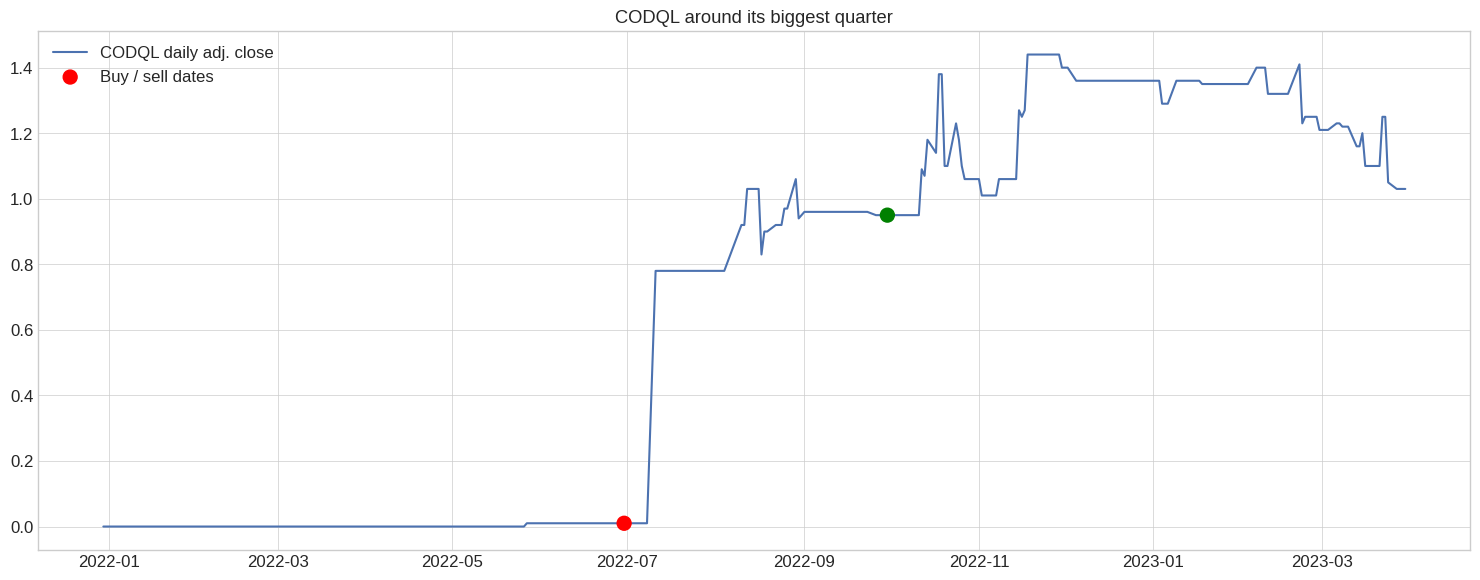

In [ ]:
s1 = sector_results[sector_results['Stage'] == '1. Pure P/B']
spike = s1.loc[s1['Best_Stock_Qtr_Return'].idxmax()]
ticker, q_start = spike['Best_Stock'], spike['Best_Stock_Date']
q_end = bt_dates[list(bt_dates).index(q_start) + 1]
print(f"Biggest single-stock quarter in stage 1: {ticker} returned {spike['Best_Stock_Qtr_Return']:.0%} "
      f"from {q_start.date()} to {q_end.date()} ({spike['Universe']})")
print(f"Price: ${data_matrices['prices'].at[q_start, ticker]:.2f} -> ${data_matrices['prices'].at[q_end, ticker]:.2f}")

print("\nThe 5 biggest single-stock quarters in stage 1:")
spikes = (pd.DataFrame([(t, d.date(), v) for key, log in sector_logs.items() if key[0] == '1. Pure P/B'
                        for d, sr in zip(log.index, log['Stock_Returns']) for t, v in sr.items()],
                       columns=['Ticker', 'Bought', 'Quarter Return'])
          .drop_duplicates().nlargest(5, 'Quarter Return'))
display(spikes.style.format({'Quarter Return': '{:.0%}'}))

daily = prices_daily[ticker].dropna()
window = daily.loc[q_start - pd.DateOffset(months=6): q_end + pd.DateOffset(months=6)]
plt.figure(figsize=(15, 6))
plt.plot(window.index, window.values, label=f'{ticker} daily adj. close')
plt.scatter([q_start, q_end], [data_matrices['prices'].at[q_start, ticker], data_matrices['prices'].at[q_end, ticker]],
            color=['red', 'green'], s=100, zorder=5, label='Buy / sell dates')
plt.title(f'{ticker} around its biggest quarter')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

**Findings:** Pure P/B beat its sector ETF only 35% of the time across all 132 runs (median gap -1.82 points a year). Its biggest wins came from penny-stock spikes like CODQL (+9,400% in one quarter), which were random chance, while sectors like Healthcare (-59.71% at K=5) and Consumer Cyclical (-71.56% at K=5) fell into value traps.

## Stage 2: Clean P/B

**Question:** Do the big returns survive once I remove tiny companies and penny stocks?

**Setup:** within each sector, drop the smallest 25% by market cap and the bottom 50% by book value, keep only the cheaper half by P/B, and require a price of at least \$1.

In [ ]:
res_stage2 = run_stage('2. Clean P/B')
show_stage(res_stage2)

print("\nBasic Materials, 5 stocks, cheapest P/B: before vs after cleaning")
bm = sector_results[(sector_results['Universe'] == 'Basic Materials') & (sector_results['Basket_Size'] == 5)
                    & (sector_results['Ranking_Metric'] == 'pb') & sector_results['Stage'].isin(['1. Pure P/B', '2. Clean P/B'])]
display(bm[['Stage', 'CAGR', 'Bench_CAGR', 'Volatility', 'Max_Drawdown', 'Best_Stock', 'Best_Stock_Qtr_Return']]
        .style.format({'CAGR': '{:.2%}', 'Bench_CAGR': '{:.2%}', 'Volatility': '{:.2%}', 'Max_Drawdown': '{:.2%}',
                       'Best_Stock_Qtr_Return': '{:.0%}'}))

▶ 2. Clean P/B


,ETF CAGR,CAGR K=5,CAGR K=10,CAGR K=50,CAGR K=100,Vol K=5,Vol K=100,Avg stocks held K=100,Sizes beating ETF
Universe,,,,,,,,,
Basic Materials,4.98%,24.15%,17.33%,15.10%,15.10%,30.02%,19.64%,19.9,4/4
Business Services,2.27%,-19.73%,-16.19%,-16.19%,-16.19%,19.68%,18.25%,7.4,0/4
Consumer Cyclical,9.09%,-6.15%,-4.51%,0.05%,-0.35%,30.79%,23.58%,57.9,0/4
Consumer Defensive,5.84%,6.43%,1.00%,-1.06%,-1.06%,23.15%,14.05%,22.2,1/4
Energy,18.64%,15.74%,24.67%,18.85%,18.85%,41.98%,29.53%,22.6,3/4
Financial Services,12.68%,17.46%,11.23%,6.73%,6.73%,44.92%,16.59%,31.0,1/4
Healthcare,5.66%,5.40%,4.61%,0.97%,-6.60%,55.15%,31.55%,99.6,0/4
Industrials,12.22%,13.66%,14.93%,6.34%,7.03%,24.17%,17.20%,57.8,2/4
Real Estate,4.83%,-2.70%,-2.35%,-1.12%,-1.12%,24.47%,18.17%,27.1,0/4


All 132 runs of this stage (11 sectors x 4 basket sizes x 3 rankings): beat the ETF 23% of the time, median CAGR gap vs ETF -5.96%

Basic Materials, 5 stocks, cheapest P/B: before vs after cleaning


,Stage,CAGR,Bench_CAGR,Volatility,Max_Drawdown,Best_Stock,Best_Stock_Qtr_Return
84,1. Pure P/B,41.50%,4.98%,886.64%,-75.20%,CODQL,9400%
216,2. Clean P/B,24.15%,4.98%,30.02%,-17.59%,VHI,88%


**Findings:** Removing tiny companies and stocks under \ cut the wild swings (Basic Materials K=5 volatility fell from 886.64% to 30.02%) and shrank the worst crashes, but the win rate also fell from 35% to 23% (median gap -5.96 points a year) once the random-chance penny-stock spikes were gone.

## Stage 3: Clean P/B + ROA

**Question:** Cheap can mean broken ("value traps"). Does requiring a profit help?

**Setup:** stage 2 plus ROA ≥ 0.1% for the quarter. I used an absolute floor instead of a sector percentile. The chart below shows why: in some sectors (like Healthcare) the median ROA is below zero, so a percentile cutoff would let in money-losing companies. In others (like Utilities) values bunch up near zero, so a percentile cutoff would throw out healthy companies. The appendix tests both.

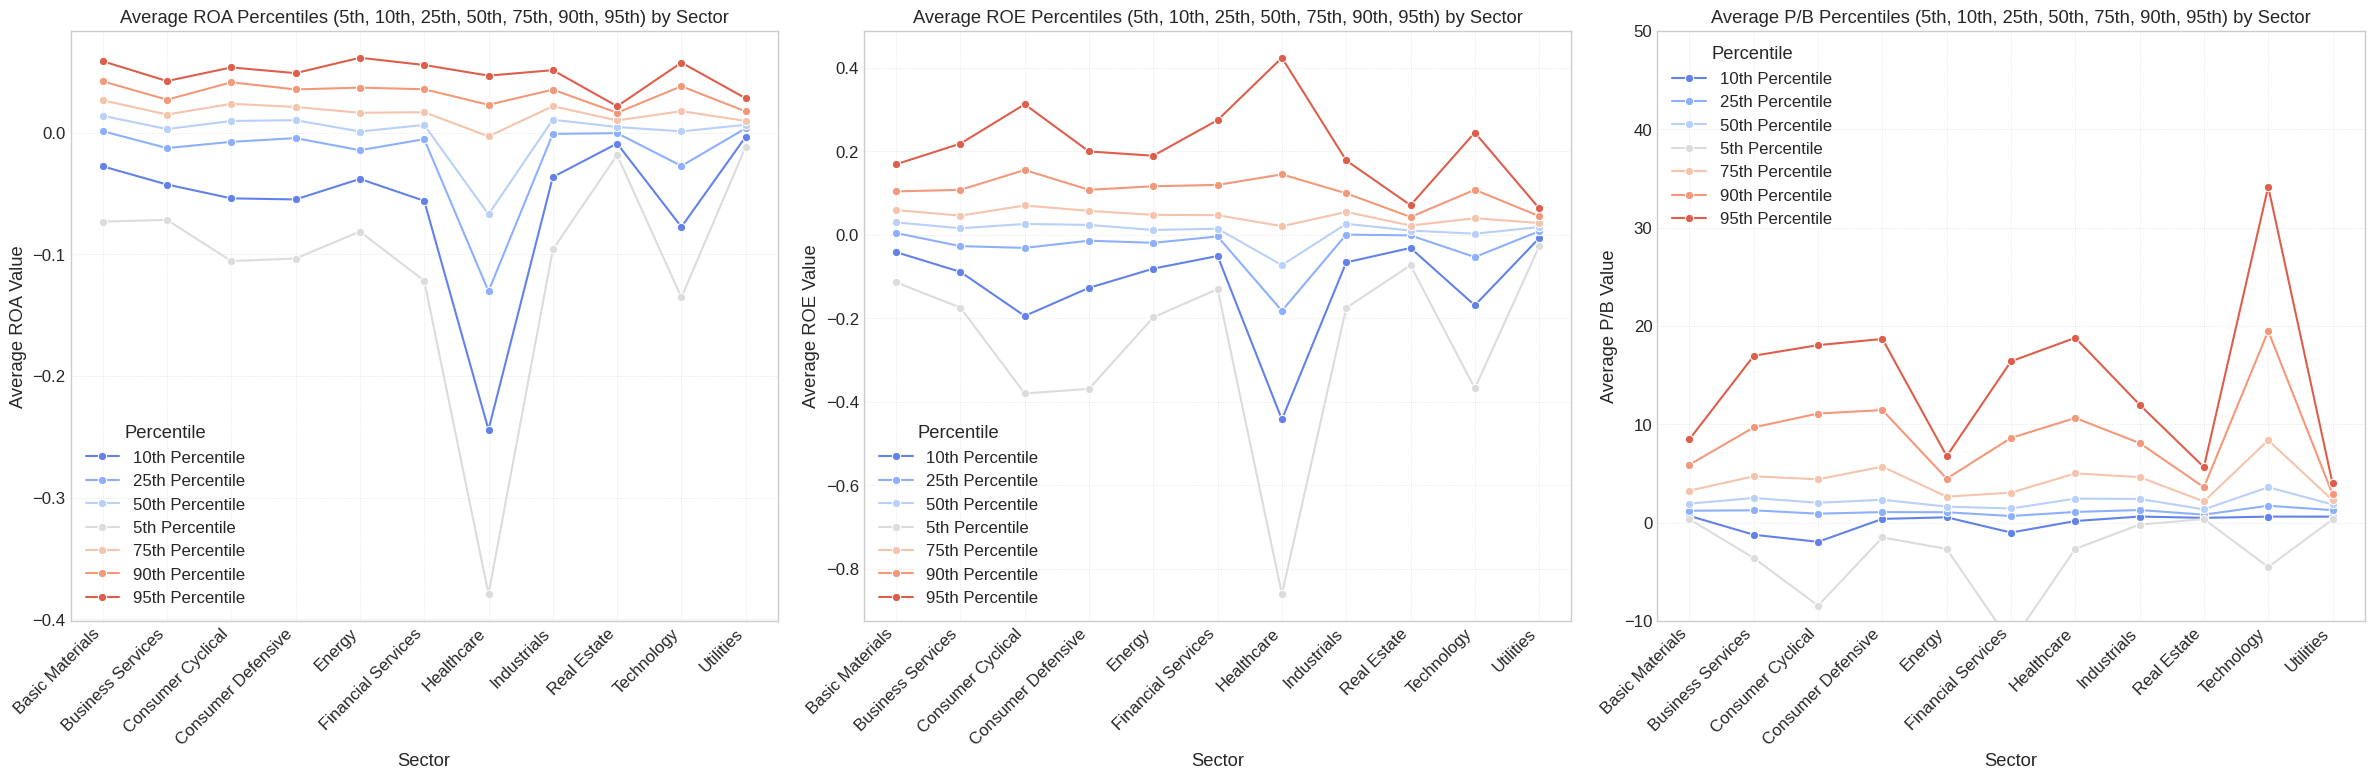

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics to plot - added 'pb'
metrics_to_plot = ['roa', 'roe', 'pb']

# Prepare data for plotting
plot_data = []

# Iterate through each sector in df_factor_percentiles
for sector in df_factor_percentiles.index.get_level_values('Sector').unique():
    sector_df = df_factor_percentiles.loc[sector]
    for metric_prefix in metrics_to_plot:
        # Select all columns related to the current metric (e.g., 'roa_0', 'roa_1', ..., 'roa_100')
        metric_columns = [col for col in sector_df.columns if col.startswith(metric_prefix)]

        # Melt these columns to create a long format
        melted_metric_df = sector_df[metric_columns].melt(var_name='Percentile_Key', value_name='Value', ignore_index=False)
        melted_metric_df['Sector'] = sector
        melted_metric_df['Metric'] = metric_prefix.upper() # ROA, ROE, or PB

        # The 'Percentile_Key' contains the percentile (e.g., 'roa_25' -> 25)
        # Extract the numeric percentile value
        melted_metric_df['Percentile'] = melted_metric_df['Percentile_Key'].apply(lambda x: int(x.split('_')[1]))

        plot_data.append(melted_metric_df)

df_plot = pd.concat(plot_data)

# Filter out NaN values, which can occur if no data was available for a sector/date/metric
df_plot.dropna(subset=['Value'], inplace=True)

# To get a clearer view of specific percentiles' average values across sectors

# Extract relevant percentile levels as requested by the user
percentile_levels_to_plot = [5, 10, 25, 50, 75, 90, 95]
filtered_df_plot = df_plot[df_plot['Percentile'].isin(percentile_levels_to_plot)].copy()

# Rename percentile values for better legend
filtered_df_plot['Percentile_Label'] = filtered_df_plot['Percentile'].astype(str) + 'th Percentile'

# Aggregate the filtered data to show average percentile levels per sector
summary_percentiles = filtered_df_plot.groupby(['Sector', 'Metric', 'Percentile_Label'])['Value'].mean().reset_index()

plt.figure(figsize=(24, 8)) # Increased figure size for 3 plots

# Plot for ROA percentiles
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.lineplot(
    data=summary_percentiles[summary_percentiles['Metric'] == 'ROA'],
    x='Sector', y='Value', hue='Percentile_Label', marker='o', palette='coolwarm'
)
plt.title('Average ROA Percentiles (5th, 10th, 25th, 50th, 75th, 90th, 95th) by Sector')
plt.xlabel('Sector')
plt.ylabel('Average ROA Value')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Percentile')

# Plot for ROE percentiles
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.lineplot(
    data=summary_percentiles[summary_percentiles['Metric'] == 'ROE'],
    x='Sector', y='Value', hue='Percentile_Label', marker='o', palette='coolwarm'
)
plt.title('Average ROE Percentiles (5th, 10th, 25th, 50th, 75th, 90th, 95th) by Sector')
plt.xlabel('Sector')
plt.ylabel('Average ROE Value')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Percentile')

# Plot for PB percentiles (NEW)
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.lineplot(
    data=summary_percentiles[summary_percentiles['Metric'] == 'PB'],
    x='Sector', y='Value', hue='Percentile_Label', marker='o', palette='coolwarm'
)
plt.title('Average P/B Percentiles (5th, 10th, 25th, 50th, 75th, 90th, 95th) by Sector')
plt.xlabel('Sector')
plt.ylabel('Average P/B Value')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Percentile')
plt.ylim(-10, 50) # Set y-axis limit for P/B plot

plt.tight_layout()
plt.show()

In [ ]:
res_stage3 = run_stage('3. Clean + ROA')
show_stage(res_stage3)

▶ 3. Clean + ROA


,ETF CAGR,CAGR K=5,CAGR K=10,CAGR K=50,CAGR K=100,Vol K=5,Vol K=100,Avg stocks held K=100,Sizes beating ETF
Universe,,,,,,,,,
Basic Materials,4.98%,26.19%,14.82%,17.39%,17.39%,23.29%,19.28%,14.3,4/4
Business Services,2.27%,-21.55%,-20.12%,-20.12%,-20.12%,21.19%,20.42%,4.6,0/4
Consumer Cyclical,9.09%,-5.27%,-2.08%,3.73%,3.52%,28.85%,23.51%,42.6,0/4
Consumer Defensive,5.84%,-1.38%,-0.03%,-0.85%,-0.85%,19.13%,12.07%,16.1,0/4
Energy,18.64%,21.33%,14.10%,12.67%,12.67%,25.85%,21.90%,14.7,1/4
Financial Services,12.68%,4.87%,8.70%,5.91%,5.91%,19.60%,14.00%,20.7,0/4
Healthcare,5.66%,-14.70%,-14.43%,-7.25%,-7.25%,35.06%,14.49%,25.4,0/4
Industrials,12.22%,8.89%,10.31%,8.65%,8.65%,19.85%,15.87%,44.9,0/4
Real Estate,4.83%,-3.88%,-2.83%,-1.10%,-1.10%,23.00%,17.67%,17.2,0/4


All 132 runs of this stage (11 sectors x 4 basket sizes x 3 rankings): beat the ETF 13% of the time, median CAGR gap vs ETF -5.98%


**Findings:** Requiring ROA ≥ 0.1% lowered average K=5 volatility from 32.35% to 23.39%, but it did not raise returns: the win rate fell to 13% (median gap -5.98 points a year). Smaller sectors like Utilities and Business Services also ran down to only about 5–6 passing stocks.

## Stage 4: Clean P/B + ROE

**Question:** Is ROE a better or worse profit check than ROA? ROE can be pumped up by debt (less equity means a bigger ROE), which I call the "leverage trap".

**Setup:** stage 2 plus ROE ≥ 0.1%, instead of ROA.

In [ ]:
res_stage4 = run_stage('4. Clean + ROE')
show_stage(res_stage4)

print("\nROA vs ROE, 5 stocks, cheapest P/B:")
rows = []
for u in SECTOR_UNIVERSES:
    pa, _ = sector_returns[('3. Clean + ROA', u, 5, 'pb')]
    pe, _ = sector_returns[('4. Clean + ROE', u, 5, 'pb')]
    rows.append({'Sector': u, 'ROA CAGR': calc_cagr(pa), 'ROE CAGR': calc_cagr(pe),
                 'Difference': calc_cagr(pe) - calc_cagr(pa),
                 'ROA Vol': calc_annualized_volatility(pa), 'ROE Vol': calc_annualized_volatility(pe),
                 'ROA Sharpe': calc_sharpe_ratio(pa), 'ROE Sharpe': calc_sharpe_ratio(pe)})
roa_vs_roe = pd.DataFrame(rows).set_index('Sector')
display(roa_vs_roe.style.format({c: '{:.2%}' for c in ['ROA CAGR', 'ROE CAGR', 'Difference', 'ROA Vol', 'ROE Vol']}
                                | {'ROA Sharpe': '{:.2f}', 'ROE Sharpe': '{:.2f}'}))

▶ 4. Clean + ROE


,ETF CAGR,CAGR K=5,CAGR K=10,CAGR K=50,CAGR K=100,Vol K=5,Vol K=100,Avg stocks held K=100,Sizes beating ETF
Universe,,,,,,,,,
Basic Materials,4.98%,26.76%,14.89%,17.44%,17.44%,23.32%,19.34%,14.6,4/4
Business Services,2.27%,-19.39%,-18.24%,-18.24%,-18.24%,21.00%,20.14%,4.9,0/4
Consumer Cyclical,9.09%,-9.31%,-3.56%,3.93%,3.69%,30.43%,23.46%,43.6,0/4
Consumer Defensive,5.84%,-3.39%,-1.43%,-1.80%,-1.80%,19.99%,12.32%,16.6,0/4
Energy,18.64%,22.92%,16.98%,14.16%,14.16%,25.12%,21.54%,14.9,1/4
Financial Services,12.68%,-4.52%,5.62%,4.82%,4.82%,21.68%,14.80%,21.4,0/4
Healthcare,5.66%,-10.32%,-13.89%,-6.61%,-6.61%,31.90%,14.14%,26.1,0/4
Industrials,12.22%,11.51%,12.00%,8.96%,9.08%,22.70%,15.86%,45.8,0/4
Real Estate,4.83%,-4.61%,-3.09%,-0.76%,-0.76%,22.91%,18.05%,17.9,0/4


All 132 runs of this stage (11 sectors x 4 basket sizes x 3 rankings): beat the ETF 12% of the time, median CAGR gap vs ETF -5.59%

ROA vs ROE, 5 stocks, cheapest P/B:


,ROA CAGR,ROE CAGR,Difference,ROA Vol,ROE Vol,ROA Sharpe,ROE Sharpe
Sector,,,,,,,
Technology,1.57%,-0.72%,-2.29%,27.08%,26.91%,-0.02,-0.10
Healthcare,-14.70%,-10.32%,4.38%,35.06%,31.90%,-0.48,-0.39
Financial Services,4.87%,-4.52%,-9.39%,19.60%,21.68%,0.15,-0.30
Consumer Defensive,-1.38%,-3.39%,-2.01%,19.13%,19.99%,-0.18,-0.27
Consumer Cyclical,-5.27%,-9.31%,-4.03%,28.85%,30.43%,-0.25,-0.37
Industrials,8.89%,11.51%,2.62%,19.85%,22.70%,0.35,0.42
Energy,21.33%,22.92%,1.59%,25.85%,25.12%,0.75,0.83
Basic Materials,26.19%,26.76%,0.57%,23.29%,23.32%,1.04,1.06
Real Estate,-3.88%,-4.61%,-0.73%,23.00%,22.91%,-0.26,-0.29


**Findings:** With positive equity required (which blocks the "zombie" negative-divided-by-negative ROE glitch), ROE ≥ 0.1% and ROA ≥ 0.1% were close to a tie overall (12% vs 13% win rate). The biggest difference was in Financial Services at K=5, where ROE trailed ROA by 9.39 points a year.

## Stage 5: Stacking the Filters (Clean P/B + ROA + ROE)

**Question:** Does requiring both profit checks help more than one?

In [ ]:
res_stage5 = run_stage('5. Clean + ROA + ROE')
show_stage(res_stage5)

same = all(set(sector_logs[('5. Clean + ROA + ROE',) + k[1:]]['Stock_Returns'].apply(tuple))
           == set(sector_logs[k]['Stock_Returns'].apply(tuple))
           for k in sector_logs if k[0] == '3. Clean + ROA')
print(f"\nStage 5 picks exactly the same stocks as stage 3 (ROA only): {same}")

▶ 5. Clean + ROA + ROE


,ETF CAGR,CAGR K=5,CAGR K=10,CAGR K=50,CAGR K=100,Vol K=5,Vol K=100,Avg stocks held K=100,Sizes beating ETF
Universe,,,,,,,,,
Basic Materials,4.98%,26.19%,14.82%,17.39%,17.39%,23.29%,19.28%,14.3,4/4
Business Services,2.27%,-21.55%,-20.12%,-20.12%,-20.12%,21.19%,20.42%,4.6,0/4
Consumer Cyclical,9.09%,-5.27%,-2.08%,3.73%,3.52%,28.85%,23.51%,42.6,0/4
Consumer Defensive,5.84%,-1.38%,-0.03%,-0.85%,-0.85%,19.13%,12.07%,16.1,0/4
Energy,18.64%,21.33%,14.10%,12.67%,12.67%,25.85%,21.90%,14.7,1/4
Financial Services,12.68%,4.87%,8.70%,5.91%,5.91%,19.60%,14.00%,20.7,0/4
Healthcare,5.66%,-14.70%,-14.43%,-7.25%,-7.25%,35.06%,14.49%,25.4,0/4
Industrials,12.22%,8.89%,10.31%,8.65%,8.65%,19.85%,15.87%,44.9,0/4
Real Estate,4.83%,-3.88%,-2.83%,-1.10%,-1.10%,23.00%,17.67%,17.2,0/4


All 132 runs of this stage (11 sectors x 4 basket sizes x 3 rankings): beat the ETF 13% of the time, median CAGR gap vs ETF -5.98%

Stage 5 picks exactly the same stocks as stage 3 (ROA only): True


**Why:** with positive equity, ROE is always at least as big as ROA, because equity is smaller than total assets (ROE = net income ÷ equity, ROA = net income ÷ assets). So if ROA ≥ 0.1%, ROE is too, and adding the ROE check removes nothing.

**Findings:** Every single basket and return in Stage 5 is identical to Stage 3.

# Part B: One Portfolio Across All Sectors (vs SPY)

In Part A, the small sectors ran out of stocks: after all the filters, the 50- and 100-stock baskets often held the same few companies. So here I pool the market. Each quarter I take the 500 biggest trading stocks (my stand-in for the S&P 500, rebuilt every quarter) and compare with SPY.

This time I build it the other way around:
1. **Start with everything.** Each quarter, one table with all 500 stocks, their numbers (P/B, ROA, ROE, market cap, book value, price, sector) and what each stock returned over the next quarter.
2. **Add one filter at a time** (a "filter ladder") and watch what each step does: how many stocks are left, and did the stocks it threw out actually do worse? The goal is to **weed out obvious losers**, not to guess the winners.
3. At the top of the ladder are my strict v1 broad-market filters (P/B ≤ 25th pct, ROA and ROE ≥ 75th pct, size filters).

Every step is run two ways. The only difference is **what the percentiles are measured against**:
- **Raw:** against all 500 stocks. One cutoff for everyone. Baskets buy the lowest P/B overall.
- **Sector-normalized ("Sector Neutrality"):** against the other top-500 stocks in the same sector, and baskets buy the lowest P/B *within its sector*. A bank is only compared with banks.

My guess: raw cutoffs will pile into sectors that naturally have low P/B and skip sectors like Technology, whatever the actual company quality.

## B1. The Trade-Ready Table

One row per stock per quarter. Everything is known on the buy date (the financials use the publish-date delay from Section 2), except `fwd_return`, which is what the stock did over the next quarter. Stocks that stopped trading keep their last price, the same as the engine.

Filtering is then just keeping some rows, and a portfolio is just the average `fwd_return` of the rows I keep. A quarter with nothing left is held in cash (0%).

In [ ]:
mid_date = bt_dates[len(bt_dates) // 2]  # a quarter in the middle, used for the filter funnels
T_DATES = list(bt_dates[:-1])
prices_q, alive_q = data_matrices['prices'], data_matrices['alive']

rows = []
for d0, d1 in zip(bt_dates[:-1], bt_dates[1:]):
    top = get_top_n_at_date(d0, data_matrices)
    df = pd.DataFrame({'Date': d0, 'Ticker': top, 'Sector': [sector_of.get(t) for t in top]})
    for m in ['pb', 'roa', 'roe', 'mcap', 'equity', 'pb_pct_top500']:
        df[m] = data_matrices[m].loc[d0, top].values
    df['price'] = data_matrices['prices'].loc[d0, top].values
    df['fwd_return'] = (prices_q.loc[d1, top] / prices_q.loc[d0, top] - 1).values
    df['delisted'] = (~alive_q.loc[d1, top].astype(bool)).values
    df['mcap_rank'] = range(len(top))  # 0 = biggest
    rows.append(df)
T = pd.concat(rows, ignore_index=True)

SPY_RETURNS = get_benchmark_prices('SPY').loc[bt_dates].pct_change().iloc[1:]
SPY_RETURNS.index, SPY_RETURNS.name = bt_dates[1:], None

_cutoffs = {}
def pct_cutoff(metric, level, pool):
    """Each row's percentile cutoff: across the whole top 500 ('TOP500_ALL') or its sector's top-500 stocks ('TOP500')."""
    if level not in VALID_LEVELS:
        raise ValueError(f"Percentile level {level} not available. Use one of {VALID_LEVELS}.")
    key = (metric, level, pool)
    if key not in _cutoffs:
        groups = ['Date'] if pool == 'TOP500_ALL' else ['Date', 'Sector']
        _cutoffs[key] = T.groupby(groups)[metric].transform(lambda s: s.quantile(level / 100))
    return _cutoffs[key]

def table_mask(**kw):
    """Rows that pass the filters. Same settings and same rules as the engine's selectors."""
    unknown = set(kw) - ALLOWED_KWARGS
    if unknown:
        raise ValueError(f"Unknown setting(s): {sorted(unknown)}")
    pool = kw.get('percentile_pool', 'TOP500_ALL')
    m = T[['pb', 'mcap', 'equity']].notna().all(axis=1) & (T['equity'] > 0) & (T['pb'] > 0) & (T['mcap'] > 0)
    m &= T['price'].notna() & (T['price'] >= (kw.get('min_price') or 0.0))
    for metric, key, side in [('mcap', 'mcap_min_percentile_level', 'min'), ('equity', 'bv_min_percentile_level', 'min'),
                              ('pb', 'pb_max_percentile_level', 'max')]:
        if kw.get(key) is not None:
            cut = pct_cutoff(metric, kw[key], pool)
            m &= (T[metric] >= cut) if side == 'min' else (T[metric] <= cut)
    for metric in ['roa', 'roe']:
        floor, level = kw.get(f'min_{metric}'), kw.get(f'min_{metric}_percentile_level')
        if floor is None and level is None:
            continue
        m &= T[metric].notna()
        if floor is not None:
            m &= T[metric] >= floor
        if level is not None and level > 0:
            m &= T[metric] >= pct_cutoff(metric, level, pool)
    return m

def table_backtest(K=10, mask=None, **kw):
    """K = number of stocks (cheapest first), or 'All' = equal-weight everything that passes."""
    pool = kw.get('percentile_pool', 'TOP500_ALL')
    mask = table_mask(**kw) if mask is None else mask
    metric = 'pb' if pool == 'TOP500_ALL' else 'pb_pct_top500'
    basket = T[mask]
    if K != 'All':
        basket = basket.sort_values(['Date', metric, 'mcap_rank']).groupby('Date').head(K)
    per_q = basket.groupby('Date')['fwd_return']
    port = per_q.mean().reindex(T_DATES).fillna(0.0)  # nothing passed -> cash
    port.index, port.name = bt_dates[1:], None
    sizes = per_q.size().reindex(T_DATES).fillna(0).astype(int)
    return port, SPY_RETURNS, basket, sizes

print(f"Trade-ready table: {len(T):,} rows ({T['Date'].nunique()} quarters x up to 500 stocks)")
print(f"Missing P/B: {T['pb'].isna().mean():.1%}, missing ROA: {T['roa'].isna().mean():.1%}, "
      f"negative equity: {(T['equity'] <= 0).mean():.1%}, under $1: {(T['price'] < 1).mean():.1%}")
display(T[T['Date'] == mid_date].head(5))

Trade-ready table: 9,000 rows (18 quarters x up to 500 stocks)
Missing P/B: 0.0%, missing ROA: 0.0%, negative equity: 6.2%, under $1: 0.0%


,Date,Ticker,Sector,pb,roa,roe,mcap,equity,pb_pct_top500,price,fwd_return,delisted,mcap_rank
4500,2023-06-30,AAPL,Technology,49.265328,0.072736,0.388687,3.062234e+12,6.215800e+10,0.941176,193.97,-0.116145,False,0
4501,2023-06-30,MSFT,Technology,13.003572,0.048144,0.093994,2.531574e+12,1.946830e+11,0.705882,340.54,-0.070833,False,1
4502,2023-06-30,GOOG,Technology,5.926229,0.040734,0.057690,1.546118e+12,2.608940e+11,0.421569,120.97,0.089961,False,2
4503,2023-06-30,AMZN,Consumer Cyclical,8.760587,0.006831,0.020527,1.353738e+12,1.545260e+11,0.689189,130.36,-0.024854,False,3
4504,2023-06-30,NVDA,Technology,42.610522,0.045951,0.083320,1.044810e+12,2.452000e+10,0.921569,42.30,0.028456,False,4


### **Check: Does the Table Give the Same Answer as the Engine?**

Before trusting the shortcut, I run the same settings through the Part A engine (`run_backtest`) and the table, and compare every quarterly return.

In [ ]:
STRICT_V1 = {'mcap_min_percentile_level': 25, 'bv_min_percentile_level': 50, 'pb_max_percentile_level': 25,
             'min_price': 1.0, 'min_roa_percentile_level': 75, 'min_roe_percentile_level': 75}
RELAXED = {'pb_max_percentile_level': 50, 'min_roa': 0.001, 'min_price': 1.0}
checks = []
for name, selector, kw in [('Strict v1', selector_pb_roa_roe, STRICT_V1), ('Relaxed', selector_pb_roa, RELAXED)]:
    for pool_name, pool, metric in [('Raw', 'TOP500_ALL', 'pb'), ('Sector-normalized', 'TOP500', 'pb_pct_top500')]:
        for K in [10, 50]:
            p_eng, _, log = run_backtest('TOP500', 'SPY', selector, **kw, percentile_pool=pool,
                                         ranking_metric=metric, rank_order='Asc', basket_size=K)
            p_tab, _, _, sizes = table_backtest(K, **kw, percentile_pool=pool)
            checks.append({'Filters': name, 'Cutoffs': pool_name, 'K': K,
                           'Engine CAGR': calc_cagr(p_eng), 'Table CAGR': calc_cagr(p_tab),
                           'Biggest quarterly difference': (p_eng - p_tab).abs().max(),
                           'Same basket sizes': (log['Basket_Size'].values == sizes.values).all()})
checks = pd.DataFrame(checks)
display(checks.style.format({'Engine CAGR': '{:.2%}', 'Table CAGR': '{:.2%}', 'Biggest quarterly difference': '{:.6f}'}))
print("✅ Table matches the engine" if (checks['Biggest quarterly difference'] < 1e-9).all() and checks['Same basket sizes'].all()
      else "⚠️ Table and engine differ - check before using the ladder")

,Filters,Cutoffs,K,Engine CAGR,Table CAGR,Biggest quarterly difference,Same basket sizes
0,Strict v1,Raw,10,21.07%,21.07%,0.000000,True
1,Strict v1,Raw,50,21.07%,21.07%,0.000000,True
2,Strict v1,Sector-normalized,10,2.69%,2.69%,0.000000,True
3,Strict v1,Sector-normalized,50,2.69%,2.69%,0.000000,True
4,Relaxed,Raw,10,-3.28%,-3.28%,0.000000,True
5,Relaxed,Raw,50,9.02%,9.02%,0.000000,True
6,Relaxed,Sector-normalized,10,3.19%,3.19%,0.000000,True
7,Relaxed,Sector-normalized,50,5.32%,5.32%,0.000000,True


✅ Table matches the engine


## B2. The Filter Ladder

Each step keeps the filters above it and adds one more:

| Step | Adds | Why |
|---|---|---|
| 1. Basic checks | positive equity, P/B and market cap known, price ≥ \$1 | can't value it, or a penny stock |
| 2. + cheaper half | P/B ≤ 50th pct | it's a value strategy |
| 3. + profitable | ROA ≥ 0.1% for the quarter | weed out money-losers (same floor as Part A) |
| 4. + ROE | ROE ≥ 0.1% | same as Part A stage 4 |
| 5. + size | market cap ≥ 25th pct, book value ≥ 50th pct | Part A's "clean" size filters |
| 6. + top-quarter quality | ROA and ROE ≥ 75th pct (instead of 0.1%) | now hunting for winners |
| 7. + cheapest quarter | P/B ≤ 25th pct | = my strict v1 broad-market filters |

Steps 1–5 only weed out; steps 6–7 try to pick winners. For each step I show the portfolio of **all** stocks that pass (equal weight), and baskets of the 100, 50 and 10 cheapest.

In [ ]:
LADDER = [
    ('1. Basic checks',          {'min_price': 1.0}),
    ('2. + cheaper half by P/B', {'min_price': 1.0, 'pb_max_percentile_level': 50}),
    ('3. + profitable (ROA)',    {'min_price': 1.0, 'pb_max_percentile_level': 50, 'min_roa': 0.001}),
    ('4. + ROE',                 {'min_price': 1.0, 'pb_max_percentile_level': 50, 'min_roa': 0.001, 'min_roe': 0.001}),
    ('5. + size',                {'min_price': 1.0, 'pb_max_percentile_level': 50, 'min_roa': 0.001, 'min_roe': 0.001,
                                  'mcap_min_percentile_level': 25, 'bv_min_percentile_level': 50}),
    ('6. + top-quarter quality', {'min_price': 1.0, 'pb_max_percentile_level': 50,
                                  'mcap_min_percentile_level': 25, 'bv_min_percentile_level': 50,
                                  'min_roa_percentile_level': 75, 'min_roe_percentile_level': 75}),
    ('7. + cheapest quarter (= strict v1)', STRICT_V1),
]
assert LADDER[2][1] == RELAXED
POOLS = {'Raw': ('TOP500_ALL', 'pb'), 'Sector-normalized': ('TOP500', 'pb_pct_top500')}
LADDER_SIZES = ['All', 100, 50, 10]

rows, ladder_returns, ladder_baskets, ladder_masks = [], {}, {}, {}
for pool_name, (pool, metric) in POOLS.items():
    for rung, kw in LADDER:
        mask = table_mask(**kw, percentile_pool=pool)
        ladder_masks[(pool_name, rung)] = mask
        label = f'{rung} ({pool_name})'
        passing = mask.groupby(T['Date']).sum()
        for K in LADDER_SIZES:
            p, b, basket, sizes = table_backtest(K, mask=mask, percentile_pool=pool)
            ladder_returns[(label, 'TOP500', K, metric)] = (p, b)
            ladder_baskets[(label, K)] = basket
            best = basket.loc[basket['fwd_return'].idxmax()] if basket['fwd_return'].notna().any() else None
            cagr, bench_cagr = calc_cagr(p), calc_cagr(b)
            rows.append({'Stage': label, 'Rung': rung, 'Pool': pool_name, 'Universe': 'TOP500', 'Basket_Size': K,
                         'Avg_Passing': passing.mean(), 'Min_Passing': passing.min(),
                         'CAGR': cagr, 'Bench_CAGR': bench_cagr, 'Excess_CAGR': cagr - bench_cagr,
                         'Beat_Benchmark': cagr > bench_cagr, 'Sharpe': calc_sharpe_ratio(p),
                         'Volatility': calc_annualized_volatility(p), 'Max_Drawdown': calc_max_drawdown(p),
                         'Avg_Basket': sizes.mean(), 'Cash_Drag_Pct': (sizes == 0).mean(),
                         'Delisted_Holdings': int(basket['delisted'].sum()),
                         'Best_Stock_Qtr_Return': np.nan if best is None else best['fwd_return'],
                         'Best_Stock': None if best is None else best['Ticker'],
                         'Best_Stock_Date': None if best is None else best['Date']})
ladder_results = pd.DataFrame(rows)

all500, _, _, _ = table_backtest('All', mask=pd.Series(True, index=T.index))
for name, r in [('SPY', SPY_RETURNS), ('All top 500, equal weight', all500)]:
    print(f"{name:27s} CAGR {calc_cagr(r):6.2%}   volatility {calc_annualized_volatility(r):6.2%}   "
          f"Sharpe {calc_sharpe_ratio(r):.2f}   max drawdown {calc_max_drawdown(r):.2%}")

def ladder_view(pool_name):
    g = ladder_results[ladder_results['Pool'] == pool_name]
    view = g.pivot_table(index='Rung', columns='Basket_Size', values='CAGR', sort=False)
    view = view[LADDER_SIZES]
    view.columns = [f'CAGR: {k}' if k == 'All' else f'CAGR K={k}' for k in view.columns]
    view.insert(0, 'Stocks passing (avg)', g.groupby('Rung', sort=False)['Avg_Passing'].first())
    view.insert(1, 'Stocks passing (fewest)', g.groupby('Rung', sort=False)['Min_Passing'].first())
    k10 = g[g['Basket_Size'] == 10].set_index('Rung')
    view['Volatility K=10'] = k10['Volatility']
    view['Avg held K=10'] = k10['Avg_Basket']
    view['Sharpe K=50'] = g[g['Basket_Size'] == 50].set_index('Rung')['Sharpe']
    return view

for pool_name in POOLS:
    print(f"\n{pool_name} cutoffs, ranked by {'cheapest P/B' if pool_name == 'Raw' else 'P/B within its sector'}:")
    v = ladder_view(pool_name)
    display(v.style.format('{:.2%}').format('{:.0f}', subset=['Stocks passing (avg)', 'Stocks passing (fewest)'])
             .format('{:.1f}', subset=['Avg held K=10']).format('{:.2f}', subset=['Sharpe K=50']))

SPY                         CAGR 13.81%   volatility 15.11%   Sharpe 0.78   max drawdown -23.93%
All top 500, equal weight   CAGR  7.55%   volatility 15.41%   Sharpe 0.36   max drawdown -26.16%

Raw cutoffs, ranked by cheapest P/B:


,Stocks passing (avg),Stocks passing (fewest),CAGR: All,CAGR K=100,CAGR K=50,CAGR K=10,Volatility K=10,Avg held K=10,Sharpe K=50
Rung,,,,,,,,,
1. Basic checks,469,464,7.32%,10.45%,10.62%,3.14%,17.42%,10.0,0.65
2. + cheaper half by P/B,219,214,7.66%,10.45%,10.62%,3.14%,17.42%,10.0,0.65
3. + profitable (ROA),187,170,7.88%,8.47%,9.02%,-3.28%,17.09%,10.0,0.52
4. + ROE,187,170,7.88%,8.47%,9.02%,-3.28%,17.09%,10.0,0.52
5. + size,122,107,8.51%,9.20%,9.81%,2.40%,15.17%,10.0,0.62
6. + top-quarter quality,7,1,14.20%,14.20%,14.20%,15.75%,21.04%,6.2,0.60
7. + cheapest quarter (= strict v1),2,0,21.07%,21.07%,21.07%,21.07%,35.87%,2.1,0.53



Sector-normalized cutoffs, ranked by P/B within its sector:


,Stocks passing (avg),Stocks passing (fewest),CAGR: All,CAGR K=100,CAGR K=50,CAGR K=10,Volatility K=10,Avg held K=10,Sharpe K=50
Rung,,,,,,,,,
1. Basic checks,469,464,7.32%,6.79%,7.86%,5.06%,23.61%,10.0,0.40
2. + cheaper half by P/B,222,216,7.04%,6.79%,7.86%,5.06%,23.61%,10.0,0.40
3. + profitable (ROA),187,167,7.59%,7.43%,5.32%,3.19%,20.39%,10.0,0.24
4. + ROE,187,167,7.59%,7.43%,5.32%,3.19%,20.39%,10.0,0.24
5. + size,119,98,7.97%,7.36%,7.17%,3.95%,18.51%,10.0,0.38
6. + top-quarter quality,7,2,25.93%,25.93%,25.93%,25.25%,20.52%,6.7,1.15
7. + cheapest quarter (= strict v1),2,0,2.69%,2.69%,2.69%,2.69%,26.62%,1.9,0.03


**Findings:** Against SPY (13.81% a year), the weeding-out steps (Steps 1–5) never beat the index, landing between 5.32% and 10.62% for 50-stock baskets (partly because equal-weighting all 500 stocks made only 7.55%). Only Step 6 (+ top-quarter quality: 14.20% raw, 25.93% sector-normalized) and Step 7 (strict v1: 21.07% raw, 2.69% sector-normalized) beat SPY, and those left only about 7 and 2 stocks on average.

## B3. Does Each Filter Weed Out Losers?

For each step, I split the stocks that passed the step before into the ones this step **removed** and the ones it **kept**, and compare what they did over the next quarter. A good weeding filter removes stocks that go on to do worse. (Step 1 is compared with all 500 stocks.)

In [ ]:
def weed_out_table(pool_name):
    rows, prev = [], pd.Series(True, index=T.index)
    for rung, _ in LADDER:
        cur = ladder_masks[(pool_name, rung)]
        removed = prev & ~cur
        r_rem = T[removed].groupby('Date')['fwd_return'].mean().reindex(T_DATES)
        r_keep = T[cur].groupby('Date')['fwd_return'].mean().reindex(T_DATES)
        both = r_rem.notna() & r_keep.notna()
        rows.append({'Filter step': rung,
                     'Removed per quarter (avg)': removed.groupby(T['Date']).sum().mean(),
                     'Kept per quarter (avg)': cur.groupby(T['Date']).sum().mean(),
                     'Removed: avg quarterly return': r_rem.mean(),
                     'Kept: avg quarterly return': r_keep.mean(),
                     'Kept minus removed': r_keep.mean() - r_rem.mean(),
                     'Quarters kept beat removed': (r_keep[both] > r_rem[both]).mean()})
        prev = cur
    return pd.DataFrame(rows).set_index('Filter step')

for pool_name in POOLS:
    print(f"\n{pool_name} cutoffs:")
    display(weed_out_table(pool_name).style
            .format('{:.2%}').format('{:.0f}', subset=['Removed per quarter (avg)', 'Kept per quarter (avg)'])
            .format('{:+.2%}', subset=['Kept minus removed']).format('{:.0%}', subset=['Quarters kept beat removed']))


Raw cutoffs:


,Removed per quarter (avg),Kept per quarter (avg),Removed: avg quarterly return,Kept: avg quarterly return,Kept minus removed,Quarters kept beat removed
Filter step,,,,,,
1. Basic checks,31,469,2.89%,2.08%,-0.81%,39%
2. + cheaper half by P/B,250,219,2.05%,2.09%,+0.04%,44%
3. + profitable (ROA),32,187,1.50%,2.13%,+0.63%,56%
4. + ROE,0,187,nan%,2.13%,+nan%,nan%
5. + size,65,122,1.86%,2.26%,+0.40%,56%
6. + top-quarter quality,115,7,2.09%,3.90%,+1.80%,67%
7. + cheapest quarter (= strict v1),5,2,2.92%,7.66%,+4.74%,60%



Sector-normalized cutoffs:


,Removed per quarter (avg),Kept per quarter (avg),Removed: avg quarterly return,Kept: avg quarterly return,Kept minus removed,Quarters kept beat removed
Filter step,,,,,,
1. Basic checks,31,469,2.89%,2.08%,-0.81%,39%
2. + cheaper half by P/B,247,222,2.16%,1.98%,-0.18%,50%
3. + profitable (ROA),35,187,1.08%,2.08%,+1.00%,44%
4. + ROE,0,187,nan%,2.08%,+nan%,nan%
5. + size,68,119,2.00%,2.17%,+0.17%,67%
6. + top-quarter quality,112,7,1.97%,6.44%,+4.46%,89%
7. + cheapest quarter (= strict v1),5,2,7.35%,1.75%,-5.59%,31%


**Findings:** Keeping the cheaper half by P/B did almost nothing (+0.04% a quarter raw, -0.18% sector-normalized). Requiring ROA ≥ 0.1% helped a little (+0.63% raw, +1.00% normalized), while the top-quarter quality filter (Step 6) had the biggest weeding effect (+4.46% a quarter sector-normalized, beating the removed stocks in 89% of quarters).

## B4. Raw vs Sector-Normalized: What Did It Buy?

Which sectors end up in the 10-stock and 50-stock baskets, and how the portfolios grew compared with SPY and with simply holding all 500 stocks.

,Step 1 Raw,Step 1 Sector-normalized,Step 3 Raw,Step 3 Sector-normalized,Step 7 Raw,Step 7 Sector-normalized
Sector,,,,,,
Consumer Cyclical,18%,20%,14%,16%,30%,11%
Financial Services,14%,0%,16%,3%,0%,0%
Consumer Defensive,14%,9%,16%,9%,0%,0%
Real Estate,9%,2%,8%,6%,0%,34%
Utilities,8%,0%,8%,0%,0%,6%
Business Services,8%,0%,11%,0%,0%,0%
Basic Materials,8%,1%,7%,7%,35%,6%
Healthcare,7%,18%,4%,12%,3%,23%
Technology,7%,30%,2%,16%,0%,9%


,Step 1 Raw,Step 1 Sector-normalized,Step 3 Raw,Step 3 Sector-normalized,Step 7 Raw,Step 7 Sector-normalized
Sector,,,,,,
Consumer Cyclical,15%,16%,14%,16%,30%,11%
Energy,12%,5%,15%,6%,30%,9%
Basic Materials,10%,5%,10%,5%,35%,6%
Real Estate,10%,6%,13%,6%,0%,34%
Industrials,9%,18%,10%,20%,3%,3%
Utilities,9%,2%,10%,2%,0%,6%
Financial Services,8%,4%,5%,4%,0%,0%
Consumer Defensive,8%,7%,9%,7%,0%,0%
Healthcare,8%,14%,6%,13%,3%,23%


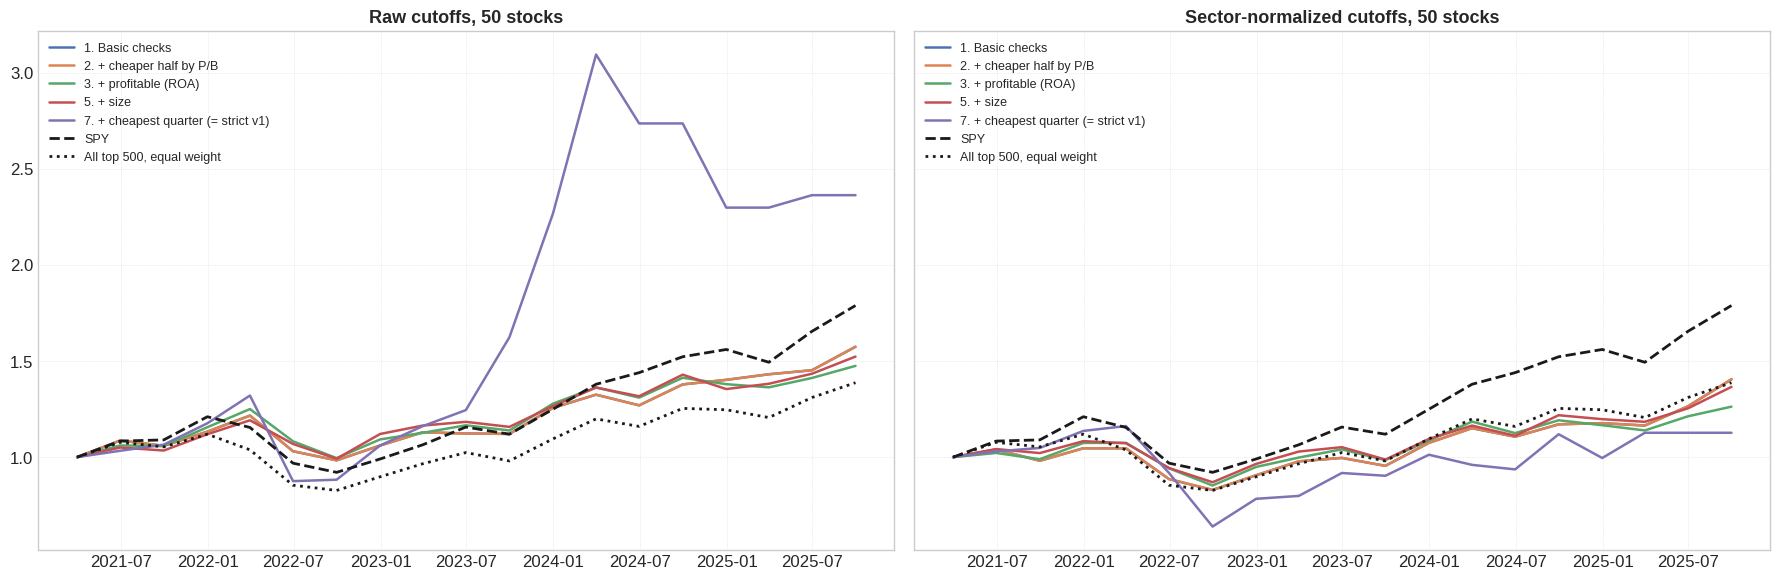

In [ ]:
MIX_RUNGS = ['1. Basic checks', '3. + profitable (ROA)', '7. + cheapest quarter (= strict v1)']
for K in [10, 50]:
    mix = pd.concat({(rung[:2].strip(' .'), pool_name): ladder_baskets[(f'{rung} ({pool_name})', K)]['Sector']
                     .value_counts(normalize=True)
                     for rung in MIX_RUNGS for pool_name in POOLS}, axis=1).fillna(0)
    mix.columns = [f'Step {r} {p}' for r, p in mix.columns]
    display(mix.sort_values(mix.columns[0], ascending=False).style.format('{:.0%}')
            .set_caption(f'Share of basket slots by sector ({K} stocks)'))

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
start = pd.Series([1.0], index=[bt_dates[0]])
for ax, (pool_name, (pool, metric)) in zip(axes, POOLS.items()):
    for rung in ['1. Basic checks', '2. + cheaper half by P/B', '3. + profitable (ROA)', '5. + size',
                 '7. + cheapest quarter (= strict v1)']:
        p, _ = ladder_returns[(f'{rung} ({pool_name})', 'TOP500', 50, metric)]
        curve = pd.concat([start, (1 + p).cumprod()])
        ax.plot(curve.index, curve.values, linewidth=1.8, label=rung)
    for series, label, style in [(SPY_RETURNS, 'SPY', 'k--'), (all500, 'All top 500, equal weight', 'k:')]:
        curve = pd.concat([start, (1 + series).cumprod()])
        ax.plot(curve.index, curve.values, style, linewidth=2, label=label)
    ax.set_title(f'{pool_name} cutoffs, 50 stocks', fontsize=13, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.7); ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

**Findings:** Raw cutoffs held much less Technology (7% vs 30% at Step 1 for K=10) and piled into naturally low-P/B sectors. Sector-normalized cutoffs fixed the sector mix and helped a lot at Step 6, though averaged across the full grid raw cutoffs still had a higher average CAGR (12.84% vs 9.72% at K=50).

# Overall Comparison of All Techniques

Every approach side by side. For Part A: how often the strategy beat its sector ETF, over all 132 runs per stage and for the 10-stock cheapest-P/B version. For Part B: every ladder step vs SPY, over its 4 portfolios (all passing, 100, 50 and 10 stocks) and for the 10-stock version.

In [ ]:
rows = []
for stage, g in sector_results.groupby('Stage'):
    k10 = g[(g['Basket_Size'] == 10) & (g['Ranking_Metric'] == 'pb')]
    rows.append({'Approach': f'A. {stage}', 'Compared with': 'sector ETFs',
                 'Beat benchmark (all runs)': g['Beat_Benchmark'].mean(),
                 'Median CAGR gap (all runs)': g['Excess_CAGR'].median(),
                 'K=10 median CAGR': k10['CAGR'].median(), 'K=10 benchmark median CAGR': k10['Bench_CAGR'].median(),
                 'K=10 median volatility': k10['Volatility'].median()})
for label, g in ladder_results.groupby('Stage', sort=False):
    k10 = g[g['Basket_Size'] == 10]
    rows.append({'Approach': f'B. {label}', 'Compared with': 'SPY',
                 'Beat benchmark (all runs)': g['Beat_Benchmark'].mean(),
                 'Median CAGR gap (all runs)': g['Excess_CAGR'].median(),
                 'K=10 median CAGR': k10['CAGR'].median(), 'K=10 benchmark median CAGR': k10['Bench_CAGR'].median(),
                 'K=10 median volatility': k10['Volatility'].median()})
overall = pd.DataFrame(rows).set_index('Approach')
display(overall.style.format({c: '{:.2%}' for c in overall.columns if c != 'Compared with'}
                             | {'Median CAGR gap (all runs)': '{:+.2%}', 'Beat benchmark (all runs)': '{:.0%}'}))

print("\nHow many stocks each filter removes (all sectors combined, on", mid_date.date(), "):")
funnel = pd.DataFrame({stage: filter_funnel(SECTOR_UNIVERSES, mid_date, sel, **kw)
                       for stage, (sel, kw) in SECTOR_STAGES.items()}).fillna(0).astype(int)
display(funnel.sort_index())

,Compared with,Beat benchmark (all runs),Median CAGR gap (all runs),K=10 median CAGR,K=10 benchmark median CAGR,K=10 median volatility
Approach,,,,,,
A. 1. Pure P/B,sector ETFs,35%,-1.82%,11.33%,9.09%,77.02%
A. 2. Clean P/B,sector ETFs,23%,-5.96%,2.07%,9.09%,24.84%
A. 3. Clean + ROA,sector ETFs,13%,-5.98%,-0.03%,9.09%,19.76%
A. 4. Clean + ROE,sector ETFs,12%,-5.59%,-1.43%,9.09%,20.14%
A. 5. Clean + ROA + ROE,sector ETFs,13%,-5.98%,-0.03%,9.09%,19.76%
B. 1. Basic checks (Raw),SPY,0%,-4.92%,3.14%,13.81%,17.42%
B. 2. + cheaper half by P/B (Raw),SPY,0%,-4.75%,3.14%,13.81%,17.42%
B. 3. + profitable (ROA) (Raw),SPY,0%,-5.63%,-3.28%,13.81%,17.09%
B. 4. + ROE (Raw),SPY,0%,-5.63%,-3.28%,13.81%,17.09%



How many stocks each filter removes (all sectors combined, on 2023-06-30 ):


,1. Pure P/B,2. Clean P/B,3. Clean + ROA,4. Clean + ROE,5. Clean + ROA + ROE
1. trading stocks,5133,5133,5133,5133,5133
P/B too high,0,717,717,717,717
PASSED,2140,440,231,242,231
ROA too low,0,0,209,0,209
ROE too low,0,0,0,198,0
book value too small,0,472,472,472,472
market cap too small,0,454,454,454,454
missing financials,2781,2781,2781,2781,2781
price below floor,0,57,57,57,57
zero/negative equity,212,212,212,212,212


## Which Variables Actually Mattered? (Logistic Regression on the 660 Part A Runs)

Across the 5 stages of Part A, I ran 660 backtests (11 sectors × 5 stages × 4 basket sizes × 3 rankings), and 127 of them (19.2%) beat their sector ETF. To see which settings actually mattered, I fit a simple logistic regression predicting whether a run beat its ETF (`Beat_Benchmark`) from the four choices (`Sector`, `Stage`, `Basket_Size`, and `Ranking_Metric`) and checked the $R^2$.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score

FACTORS = ['Sector', 'Stage', 'Basket_Size', 'Ranking_Metric']
y = sector_results['Beat_Benchmark'].astype(int)
X = pd.get_dummies(sector_results[FACTORS].astype(str))
model = LogisticRegression().fit(X, y)
print(f"All 4 variables together: R² = {r2_score(y, model.predict_proba(X)[:, 1]):.1%}\n")

rows = []
for col in FACTORS:
    Xi = pd.get_dummies(sector_results[[col]].astype(str))
    mi = LogisticRegression().fit(Xi, y)
    rows.append({'Variable': col, 'R²': r2_score(y, mi.predict_proba(Xi)[:, 1])})
display(pd.DataFrame(rows).set_index('Variable').style.format({'R²': '{:.1%}'}))

All 4 variables together: R² = 54.1%



,R²
Variable,
Sector,42.9%
Stage,5.1%
Basket_Size,2.0%
Ranking_Metric,0.2%


**Findings:** Together the 4 variables had an $R^2$ of **54.1%**. Almost all of it came from **Sector** ($R^2 = 42.9\%$ — Basic Materials beat XLB in 95% of its runs, and Industrials and Energy in 30% each, while Healthcare was 0%). **Stage** ($R^2 = 5.1\%$) and **Basket Size** ($R^2 = 2.0\%$) mattered much less, and **Ranking Metric** (cheapest P/B vs. biggest market cap or book value) added almost nothing ($R^2 = 0.2\%$: 20.9% vs. 20.0% vs. 16.8%).

## Conclusion

Cheapness alone did not beat the market. In my tests, how profitable a company was mattered about 3× more than how cheap its P/B ratio was. Some parameter settings outperformed their benchmark, but the only ones that beat SPY held tiny baskets (about 2 to 7 stocks) over just 18 quarters, where confidence is low and random chance plays a big part. For now, the index still wins.

# Appendix

Supporting cells: an engine walkthrough on one sector, extra sanity checks, the full grid search and experiments, and the full tables used in the report.

## Appendix A: Engine Walkthrough (Energy vs XLE)

### **Test Run: One Sector (Energy vs XLE)**

A single backtest to check that everything works: Energy stocks, P/B + ROE (ROE ≥ 0.1%), \$1 price floor, 10 stocks, cheapest P/B first. Then the QuantStats tear sheet and my own metrics.

Note: QuantStats is set to quarterly data (`periods_per_year=4`). My CAGR counts the number of quarters. QuantStats counts calendar days from the first to the last date, so its CAGR can be a little different.

  2021-03-31: 242 trading, 45 passed, holding 10
  2021-06-30: 244 trading, 54 passed, holding 10
  2021-09-30: 245 trading, 52 passed, holding 10
  2021-12-31: 245 trading, 65 passed, holding 10
  2022-03-31: 245 trading, 72 passed, holding 10
  2022-06-30: 247 trading, 60 passed, holding 10
  2022-09-30: 244 trading, 79 passed, holding 10
  2022-12-31: 241 trading, 82 passed, holding 10
  2023-03-31: 243 trading, 83 passed, holding 10
  2023-06-30: 243 trading, 87 passed, holding 10
  2023-09-30: 240 trading, 83 passed, holding 10
  2023-12-31: 235 trading, 89 passed, holding 10
  2024-03-31: 235 trading, 83 passed, holding 10
  2024-06-30: 231 trading, 80 passed, holding 10
  2024-09-30: 224 trading, 77 passed, holding 10
  2024-12-31: 219 trading, 75 passed, holding 10
  2025-03-31: 215 trading, 72 passed, holding 10
  2025-06-30: 215 trading, 71 passed, holding 10


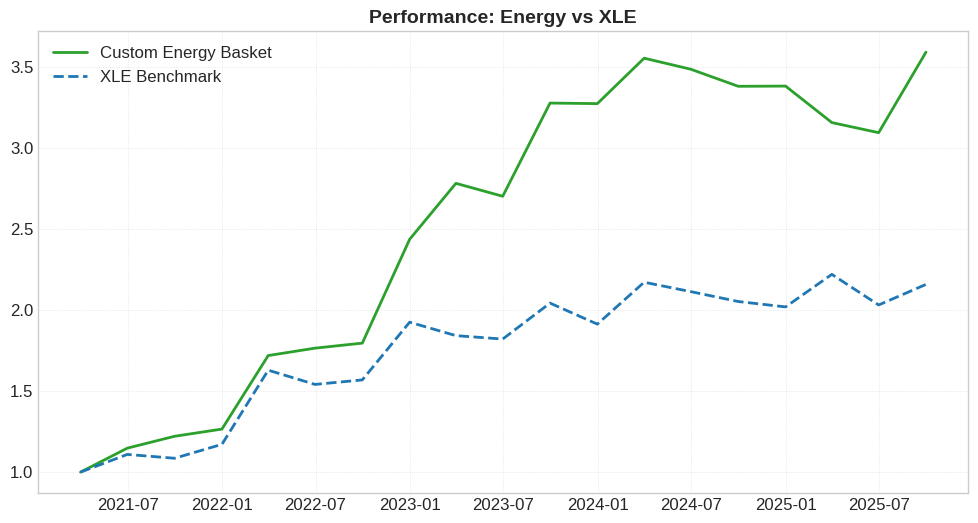


📊 Total Return: Strategy 259.17%, Benchmark 115.83%


,Strategy,Benchmark,Excess
2021-06-30,14.80%,10.93%,3.88%
2021-09-30,6.39%,-2.13%,8.52%
2021-12-31,3.63%,7.93%,-4.30%
2022-03-31,35.85%,39.05%,-3.20%
2022-06-30,2.65%,-5.40%,8.05%
2022-09-30,1.76%,1.81%,-0.05%
2022-12-31,35.66%,22.70%,12.96%
2023-03-31,14.18%,-4.32%,18.49%
2023-06-30,-2.87%,-1.14%,-1.72%
2023-09-30,21.28%,12.18%,9.10%


📊 QuantStats metrics: Custom Basket vs XLE (quarterly data)

Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    4
Compounded      Yes
Match Dates     Yes


                           Benchmark    Strategy
-------------------------  -----------  --------------
Start Period               2021-06-30   2021-06-30
End Period                 2025-09-30   2025-09-30
Risk-Free Rate             0.0%         0.0%
Time in Market             100.0%       100.0%

Cumulative Return          115.83%      259.17%
CAGR﹪                     18.64%       32.86%

Sharpe                     0.83         1.26
Prob. Sharpe Ratio         98.76%       99.99%
Smart Sharpe               0.77         1.18
Sortino                    3.1          8.18
Smart Sortino              2.89         7.63
Sortino/√2                 2.19         5.78
Smart Sortino/√2           2.04         5.4
Omega                      3.55         9.73

Max Drawdown               -

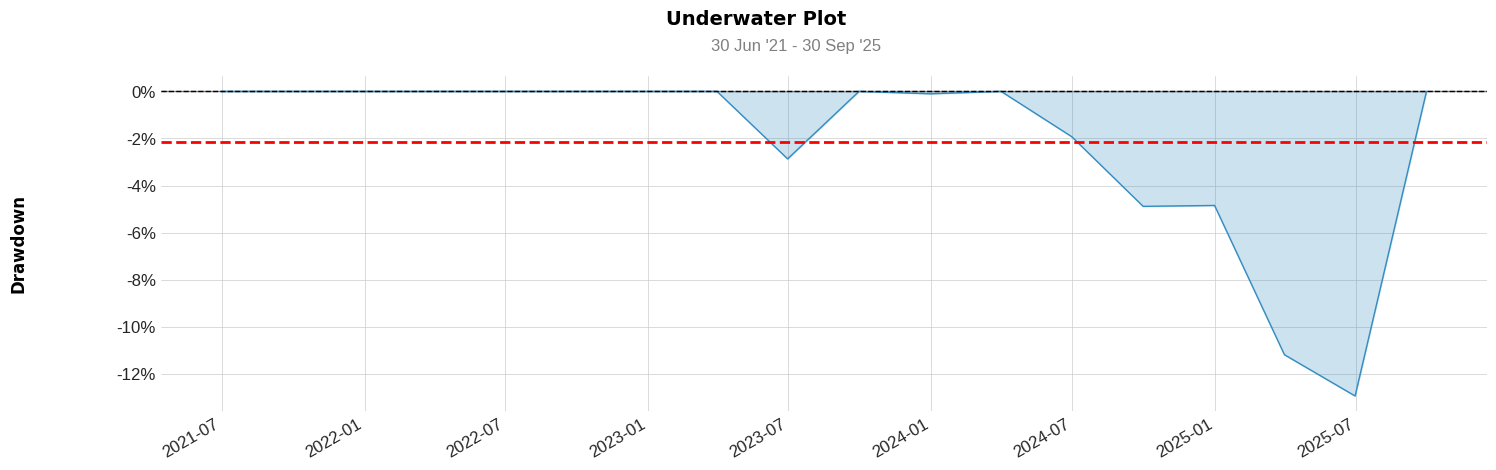

--- EXPLICIT RETURN METRICS ---
Portfolio CAGR:       32.86%
Benchmark CAGR:       18.64%
Portfolio Volatility: 25.38%
Benchmark Volatility: 23.94%
--- EXPLICIT RISK-ADJUSTED METRICS ---
Portfolio Sharpe:  1.22
Benchmark Sharpe:  0.70
Information Ratio: 0.89
--- EXPLICIT RELATIVE & DOWNSIDE METRICS ---
Portfolio alpha (vs Benchmark): 17.24%
Portfolio Beta (vs Benchmark):  0.84
Portfolio Max Drawdown:         -12.93%
Benchmark Max Drawdown:         -8.51%


In [ ]:
_selector_kwargs = {
    'mcap_min_percentile_level': 0,
    'bv_min_percentile_level': 0,
    'pb_max_percentile_level': 100,
    'ranking_metric': 'pb',
    'rank_order': 'Asc',
    'min_price': 1.0,
    'basket_size': 10,
    'min_roe': 0.001
}

port_ret, bench_ret, delta_log = run_backtest("Energy", "XLE", selector_pb_roe, verbose=True, **_selector_kwargs)

evaluate_performance(portfolio_ret=port_ret, benchmark_ret=bench_ret, sector="Energy", benchmark_name="XLE")

# ==============================================================================
# Institutional Performance Tear Sheet (QuantStats, quarterly)
# ==============================================================================
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

print("📊 QuantStats metrics: Custom Basket vs XLE (quarterly data)")
print("=" * 80)
try:
    qs.reports.metrics(port_ret, benchmark=bench_ret, mode='full', periods_per_year=4, prepare_returns=False)
except Exception as e:
    print(f"Metrics generation issue: {e}")

print("\n\n📉 Maximum Drawdown Profile:")
try:
    qs.plots.drawdown(port_ret, figsize=(15, 5))
    plt.show()
except Exception as e:
    print(f"Drawdown plot issue: {e}")

port_cagr, bench_cagr = calc_cagr(port_ret), calc_cagr(bench_ret)
port_vol, bench_vol = calc_annualized_volatility(port_ret), calc_annualized_volatility(bench_ret)
print("--- EXPLICIT RETURN METRICS ---")
print(f"Portfolio CAGR:       {port_cagr:.2%}")
print(f"Benchmark CAGR:       {bench_cagr:.2%}")
print(f"Portfolio Volatility: {port_vol:.2%}")
print(f"Benchmark Volatility: {bench_vol:.2%}")

port_sharpe, bench_sharpe = calc_sharpe_ratio(port_ret), calc_sharpe_ratio(bench_ret)
info_ratio = calc_information_ratio(port_ret, bench_ret)
print("--- EXPLICIT RISK-ADJUSTED METRICS ---")
print(f"Portfolio Sharpe:  {port_sharpe:.2f}")
print(f"Benchmark Sharpe:  {bench_sharpe:.2f}")
print(f"Information Ratio: {info_ratio:.2f}")

alpha, beta = calc_alpha(port_ret, bench_ret)
port_mdd, bench_mdd = calc_max_drawdown(port_ret), calc_max_drawdown(bench_ret)
print("--- EXPLICIT RELATIVE & DOWNSIDE METRICS ---")
print(f"Portfolio alpha (vs Benchmark): {alpha:.2%}")
print(f"Portfolio Beta (vs Benchmark):  {beta:.2f}")
print(f"Portfolio Max Drawdown:         {port_mdd:.2%}")
print(f"Benchmark Max Drawdown:         {bench_mdd:.2%}")

### **Metric Reconciliation: Manual vs. QuantStats**

To check my own metric code, I compare it with QuantStats on the metrics where both use the same formula: total return, volatility, the simple Sharpe (no risk-free rate) and max drawdown. They should match almost exactly. My main Sharpe uses CAGR minus a 2% risk-free rate, so it's a different formula and isn't compared here.

In [ ]:
checks = pd.DataFrame({
    'Metric': ['Total return', 'Volatility (annual)', 'Sharpe (simple, rf=0)', 'Max drawdown'],
    'Manual': [(1 + port_ret).prod() - 1, calc_annualized_volatility(port_ret),
               calc_sharpe_simple(port_ret), calc_max_drawdown(port_ret)],
    'QuantStats': [qs.stats.comp(port_ret), qs.stats.volatility(port_ret, periods=4, annualize=True),
                   qs.stats.sharpe(port_ret, rf=0.0, periods=4, annualize=True), qs.stats.max_drawdown(port_ret)],
})
checks['Abs Difference'] = (checks['Manual'] - checks['QuantStats']).abs()
checks['Status'] = np.where(checks['Abs Difference'] < 1e-4, '✅ Match', '❌ Different')
display(checks.style.format({'Manual': '{:.4f}', 'QuantStats': '{:.4f}', 'Abs Difference': '{:.6f}'}))

,Metric,Manual,QuantStats,Abs Difference,Status
0,Total return,2.5917,2.5917,0.000000,✅ Match
1,Volatility (annual),0.2538,0.2538,0.000000,✅ Match
2,"Sharpe (simple, rf=0)",1.2637,1.2637,0.000000,✅ Match
3,Max drawdown,-0.1293,-0.1293,0.000000,✅ Match


## Appendix B: Data Audits and Sanity Checks

These cells only report; nothing here changes the data. Audits 1-4 show the details behind the cleanup in section 1, and audit 5 checks the data against a second source (yfinance).

### **Data Audit 1: How Complete Is the Data?**

Before any backtest, I checked how much of the data is actually usable: companies missing a sector, missing financial statements, or missing prices, plus penny stocks and companies with both negative equity and negative net income ("zombie" companies).

In [ ]:
# --- Part 1: Initial Data Statistics (from original cell 7HB5QzdefAis) ---
print("--- Data Statistics on Missing Information ---")

# 1. Companies missing sector mapping
missing_sector_companies = df_companies['Sector'].isnull().sum()
total_companies = len(df_companies)
print(f"\n1. Companies missing Sector mapping: {missing_sector_companies} out of {total_companies} ({missing_sector_companies/total_companies:.2%})")

# Get all unique tickers from df_companies
all_companies_tickers = set(df_companies.index.unique())

# 2. Companies missing income data
# Get unique tickers present in df_income (from its MultiIndex)
companies_with_income_data = set(df_income.index.get_level_values('Ticker').unique())

# Find companies that are in df_companies but not in df_income
companies_missing_income = all_companies_tickers - companies_with_income_data
num_companies_missing_income = len(companies_missing_income)

print(f"2. Companies entirely missing Income data (from df_companies): {num_companies_missing_income} out of {total_companies} ({num_companies_missing_income/total_companies:.2%})")

# 3. Companies missing balance data
# Get unique tickers present in df_balance (from its MultiIndex)
companies_with_balance_data = set(df_balance.index.get_level_values('Ticker').unique())

# Find companies that are in df_companies but not in df_balance
companies_missing_balance = all_companies_tickers - companies_with_balance_data
num_companies_missing_balance = len(companies_missing_balance)

print(f"3. Companies entirely missing Balance data (from df_companies): {num_companies_missing_balance} out of {total_companies} ({num_companies_missing_balance/total_companies:.2%})")

print("\nNote: 'Entirely missing' means no records for the company in the respective SimFin DataFrame within the loaded date range.")


# --- Part 2: Penny Stock Analysis (from original cell e9edbef5) ---
print("\n--- Penny Stock Analysis for Companies Missing Financial Data ---")
# Combine tickers missing either income or balance data
companies_missing_financial_data = companies_missing_income.union(companies_missing_balance)

print(f"Total unique companies missing income or balance data: {len(companies_missing_financial_data)}")

# Define what a 'penny stock' is for this analysis
penny_stock_threshold = 1.0

missing_data_penny_stocks = []
missing_data_with_price = []
missing_data_no_price = []

for ticker in companies_missing_financial_data:
    try:
        # Select all dates for the ticker, then get 'Adj. Close', drop NaNs, and take the last value
        ticker_prices = df_prices.loc[(ticker, slice(None)), 'Adj. Close'].dropna()
        if not ticker_prices.empty:
            latest_price = ticker_prices.iloc[-1]
            missing_data_with_price.append((ticker, latest_price))
            if latest_price < penny_stock_threshold:
                missing_data_penny_stocks.append(ticker)
        else:
            missing_data_no_price.append(ticker)
    except KeyError: # Ticker not found in df_prices or 'Adj. Close' column missing for all dates
        missing_data_no_price.append(ticker)
    except Exception as e:
        # print(f"DEBUG: Unhandled error for ticker {ticker}: {e}") # Commented out debug print
        missing_data_no_price.append(ticker)

num_missing_data_penny_stocks = len(missing_data_penny_stocks)
num_missing_data_with_price = len(missing_data_with_price)
num_missing_data_no_price = len(missing_data_no_price)

print(f"\nCompanies missing financial data with available price: {num_missing_data_with_price}")
print(f"Companies missing financial data and no price data: {num_missing_data_no_price}")

if num_missing_data_with_price > 0:
    percentage_penny_stocks = (num_missing_data_penny_stocks / num_missing_data_with_price) * 100
    print(f"\nOut of those with price data, {num_missing_data_penny_stocks} are penny stocks (< ${penny_stock_threshold:.2f}).")
    print(f"This represents {percentage_penny_stocks:.2f}% of companies missing financial data that have price data.")
else:
    print("\nNo companies missing financial data have price data to analyze for penny stock status.")

print("\n--- Note on Filtering ---\nThe backtesting functions (`selector_pb`, `selector_pb_roa`, `selector_pb_roe`, `selector_pb_roa_roe`) already include a `min_price` parameter (defaulting to 0.0, but typically set to 1.0 in `selector_kwargs`) which filters out stocks below a specified price at *each rebalance date*. This effectively addresses the concern of penny stocks impacting the portfolio at the point of selection.")


# --- Part 3: Detailed Data Completeness Breakdown (from original cell c99122c3) ---
print("\n--- Detailed Data Completeness Breakdown: Sector, Income, and Price Data ---")

# Recalculate or retrieve base sets (ensure all are updated)
all_companies_tickers = set(df_companies.index.unique())
total_companies = len(all_companies_tickers)

# Companies with sector mapping
companies_with_sector = set(df_companies['Sector'].dropna().index.unique())

# Companies with price data
companies_with_price_data = set(df_prices.index.get_level_values('Ticker').unique())


# Derive missing sets
companies_missing_sector = all_companies_tickers - companies_with_sector
companies_missing_price = all_companies_tickers - companies_with_price_data
# companies_missing_income and companies_missing_balance are already defined from Part 1

print(f"Total unique companies in df_companies: {total_companies}\n")

# 1. Companies with sector mapping AND income data, BUT no price data
scenario_1 = (companies_with_sector.intersection(companies_with_income_data)) - companies_with_price_data
fraction_1 = len(scenario_1) / total_companies
print(f"1. Companies with sector AND income data, but NO price data: {len(scenario_1)} ({fraction_1:.2%})")

# 2. Companies with price data AND income data, BUT no sector mapping
scenario_2 = (companies_with_price_data.intersection(companies_with_income_data)) - companies_with_sector
fraction_2 = len(scenario_2) / total_companies
print(f"2. Companies with price AND income data, but NO sector mapping: {len(scenario_2)} ({fraction_2:.2%})")

# 3. Companies with sector mapping AND price data, BUT no income data
scenario_3 = (companies_with_sector.intersection(companies_with_price_data)) - companies_with_income_data
fraction_3 = len(scenario_3) / total_companies
print(f"3. Companies with sector AND price data, but NO income data: {len(scenario_3)} ({fraction_3:.2%})")

# 4. Companies with sector mapping AND price data AND income data (fully complete)
scenario_4 = companies_with_sector.intersection(companies_with_price_data).intersection(companies_with_income_data)
fraction_4 = len(scenario_4) / total_companies
print(f"4. Companies with sector AND price AND income data (fully complete): {len(scenario_4)} ({fraction_4:.2%})")

# 5. Companies with NO sector mapping AND NO income data AND NO price data (completely incomplete)
scenario_5 = companies_missing_sector.intersection(companies_missing_income).intersection(companies_missing_price)
fraction_5 = len(scenario_5) / total_companies
print(f"5. Companies with NO sector AND NO income AND NO price data: {len(scenario_5)} ({fraction_5:.2%})")

# Additional common cases based on the original phrasing

# "sector mapping or income data but no price data"
scenario_A = (companies_with_sector.union(companies_with_income_data)) - companies_with_price_data
fraction_A = len(scenario_A) / total_companies
print(f"\nAdditional - Companies with (sector OR income) data, but NO price data: {len(scenario_A)} ({fraction_A:.2%})")

# "price data but no sector mapping or no income data"
# This interpretation: price data present, AND (sector missing OR income missing)
scenario_B = companies_with_price_data.intersection(companies_missing_sector.union(companies_missing_income))
fraction_B = len(scenario_B) / total_companies
print(f"Additional - Companies with price data, but (NO sector OR NO income data): {len(scenario_B)} ({fraction_B:.2%})")


# --- Part 4: Summary Table Generation (from original cell c2db5d4b and previous turn's generation logic) ---
print("\n--- Summary of Data Completeness: Missing vs. Available ---")

# Create a dictionary to hold the data for the DataFrame
summary_data = {
    'Income Data': {
        'Available': len(companies_with_income_data),
        'Missing': len(companies_missing_income)
    },
    'Balance Data': {
        'Available': len(companies_with_balance_data),
        'Missing': len(companies_missing_balance)
    },
    'Price Data': {
        'Available': len(companies_with_price_data),
        'Missing': len(companies_missing_price)
    },
    'Sector Mapping': {
        'Available': len(companies_with_sector),
        'Missing': len(companies_missing_sector)
    }
}

# Create the DataFrame
df_completeness_summary = pd.DataFrame(summary_data)


# --- New Part: Negative Equity & Net Income Analysis ---
print("\n--- Analysis: Companies with Negative Equity AND Negative Net Income ---")

# 1. Identify companies with negative equity (at any point in df_balance)
# Ensure we only consider companies present in df_companies
all_companies_tickers_in_companies_df = set(df_companies.index.unique())
neg_equity_tickers_raw = set(df_balance[df_balance['Total Equity'] < 0].index.get_level_values('Ticker').unique())
neg_equity_tickers = neg_equity_tickers_raw.intersection(all_companies_tickers_in_companies_df)
print(f"Number of companies with negative equity (at any point): {len(neg_equity_tickers)}")

# 2. Identify companies with negative net income (at any point in df_income)
neg_income_tickers_raw = set(df_income[df_income['Net Income'] < 0].index.get_level_values('Ticker').unique())
neg_income_tickers = neg_income_tickers_raw.intersection(all_companies_tickers_in_companies_df)
print(f"Number of companies with negative net income (at any point): {len(neg_income_tickers)}")

# 3. Find companies with both negative equity AND negative net income
companies_with_neg_equity_and_income = neg_equity_tickers.intersection(neg_income_tickers)
num_companies_neg_eq_inc = len(companies_with_neg_equity_and_income)
print(f"Number of companies with BOTH negative equity AND negative net income: {num_companies_neg_eq_inc}")

# 4. Categorize these companies into penny vs. non-penny stocks
penny_stock_threshold = 1.0 # Re-using the same threshold
neg_financial_penny_stocks = []
neg_financial_non_penny_stocks = []
neg_financial_no_price = []

for ticker in companies_with_neg_equity_and_income:
    try:
        ticker_prices = df_prices.loc[(ticker, slice(None)), 'Adj. Close'].dropna()
        if not ticker_prices.empty:
            latest_price = ticker_prices.iloc[-1]
            if latest_price < penny_stock_threshold:
                neg_financial_penny_stocks.append(ticker)
            else:
                neg_financial_non_penny_stocks.append(ticker)
        else:
            neg_financial_no_price.append(ticker)
    except KeyError:
        neg_financial_no_price.append(ticker)
    except Exception as e:
        neg_financial_no_price.append(ticker)

num_neg_financial_penny_stocks = len(neg_financial_penny_stocks)
num_neg_financial_non_penny_stocks = len(neg_financial_non_penny_stocks)
num_neg_financial_no_price = len(neg_financial_no_price)

print(f"\nBreakdown of companies with negative equity AND negative net income:")
print(f"  - Penny Stocks (< ${penny_stock_threshold:.2f}): {num_neg_financial_penny_stocks}")
print(f"  - Non-Penny Stocks (>= ${penny_stock_threshold:.2f}): {num_neg_financial_non_penny_stocks}")
print(f"  - No Price Data Available: {num_neg_financial_no_price}")


# --- Update Summary Table to include the new metric as a column ---

# Create a new column in df_completeness_summary
df_completeness_summary['Negative Equity & Net Income'] = pd.Series(dtype=object)

# Populate the new column for 'Available' and 'Missing' rows (as N/A or empty for this new category)
df_completeness_summary.loc['Available', 'Negative Equity & Net Income'] = '' # Not applicable
df_completeness_summary.loc['Missing', 'Negative Equity & Net Income'] = '' # Not applicable

# Now, create additional rows for the breakdown. These rows will only have values in the new column.
new_breakdown_rows = pd.DataFrame({
    'Negative Equity & Net Income': [
        f"Total: {num_companies_neg_eq_inc}",
        f"Penny Stocks: {num_neg_financial_penny_stocks}",
        f"Non-Penny Stocks: {num_neg_financial_non_penny_stocks}"
    ]
}, index=[
    'Negative Eq & Inc (Total)',
    'Negative Eq & Inc (Penny)',
    'Negative Eq & Inc (Non-Penny)'
])

# Concatenate the main summary with the breakdown rows.
# Filling other columns of new_breakdown_rows with empty strings to avoid NaN display issues
for col in df_completeness_summary.columns:
    if col != 'Negative Equity & Net Income':
        new_breakdown_rows[col] = ''

df_completeness_summary_final = pd.concat([df_completeness_summary, new_breakdown_rows])


# Re-create df_completeness_summary_formatted from df_completeness_summary_final
df_completeness_summary_formatted = pd.DataFrame(index=df_completeness_summary_final.index)

for col in df_completeness_summary_final.columns:
    for idx in df_completeness_summary_final.index:
        count_or_value = df_completeness_summary_final.loc[idx, col]

        if count_or_value == '': # Handle empty cells
            df_completeness_summary_formatted.loc[idx, col] = ''
        elif idx in ['Available', 'Missing'] and col != 'Negative Equity & Net Income':
            # Format Available/Missing percentages for original columns
            total_companies_for_pct = len(all_companies_tickers)
            pct = (count_or_value / total_companies_for_pct) * 100
            df_completeness_summary_formatted.loc[idx, col] = f"{int(count_or_value)} ({pct:.2f}%)"
        else: # For the new column, or breakdown rows, just display as is (already formatted as string)
            df_completeness_summary_formatted.loc[idx, col] = str(count_or_value)


display(df_completeness_summary_formatted.style.set_caption("Data Completeness Overview (with percentages and Negative Financials)"))

--- Data Statistics on Missing Information ---

1. Companies missing Sector mapping: 314 out of 6592 (4.76%)
2. Companies entirely missing Income data (from df_companies): 2811 out of 6592 (42.64%)
3. Companies entirely missing Balance data (from df_companies): 2811 out of 6592 (42.64%)

Note: 'Entirely missing' means no records for the company in the respective SimFin DataFrame within the loaded date range.

--- Penny Stock Analysis for Companies Missing Financial Data ---
Total unique companies missing income or balance data: 2811

Companies missing financial data with available price: 2318
Companies missing financial data and no price data: 493

Out of those with price data, 188 are penny stocks (< $1.00).
This represents 8.11% of companies missing financial data that have price data.

--- Note on Filtering ---
The backtesting functions (`selector_pb`, `selector_pb_roa`, `selector_pb_roe`, `selector_pb_roa_roe`) already include a `min_price` parameter (defaulting to 0.0, but typical

,Income Data,Balance Data,Price Data,Sector Mapping,Negative Equity & Net Income
Available,3742 (57.10%),3742 (57.10%),5892 (89.91%),6278 (95.80%),
Missing,2811 (42.90%),2811 (42.90%),661 (10.09%),275 (4.20%),
Negative Eq & Inc (Total),,,,,Total: 643
Negative Eq & Inc (Penny),,,,,Penny Stocks: 154
Negative Eq & Inc (Non-Penny),,,,,Non-Penny Stocks: 425


### **Data Audit 2: Share-Count Cleanup Details**

The biggest share counts the cleanup removed, the three companies I first noticed (DLB, BLKB, MRTX) report by report, and a spot check of the worst ones against yfinance.

In [ ]:
def show_share_audit(sa):
    sh, biggest = sa['sh'], sa['biggest']
    cols = ['Ticker', 'Company', 'Report Date', 'Shares (Basic)', 'Company median', 'Price-file shares',
            'Price at report', 'Apparent market cap', 'Apparent P/B']
    print("Biggest flagged companies (by the wrong, apparent market cap):")
    display(biggest[cols].style.format({'Shares (Basic)': '{:,.0f}', 'Company median': '{:,.0f}',
                                        'Price-file shares': '{:,.0f}', 'Price at report': '{:.2f}',
                                        'Apparent market cap': '{:,.0f}', 'Apparent P/B': '{:,.0f}'}))
    print("\nThe three companies I first noticed, report by report:")
    for t in ['DLB', 'BLKB', 'MRTX']:
        rows = sh[sh['Ticker'] == t]
        print(f"  {t}: share counts {rows['Shares (Basic)'].map('{:,.0f}'.format).tolist()} "
              f"flagged {int(rows['Flag'].sum())}/{len(rows)}")
    # Spot check against yfinance's share-count history
    spot = []
    for _, r in biggest.head(8).iterrows():
        try:
            yf_sh = yf.Ticker(r['Ticker']).get_shares_full(start=r['Report Date'] - pd.Timedelta(days=90),
                                                             end=r['Report Date'] + pd.Timedelta(days=90))
            yf_val = float(yf_sh.median()) if yf_sh is not None and len(yf_sh) else np.nan
        except Exception:
            yf_val = np.nan
        spot.append({'Ticker': r['Ticker'], 'Report Date': r['Report Date'].date(), 'SimFin shares': r['Shares (Basic)'],
                     'yfinance shares': yf_val, 'SimFin / yfinance': r['Shares (Basic)'] / yf_val})
    print("\nSpot check vs yfinance:")
    display(pd.DataFrame(spot).style.format({'SimFin shares': '{:,.0f}', 'yfinance shares': '{:,.0f}',
                                             'SimFin / yfinance': '{:,.1f}'}, na_rep='-'))

show_share_audit(share_audit)

Biggest flagged companies (by the wrong, apparent market cap):


,Ticker,Company,Report Date,Shares (Basic),Company median,Price-file shares,Price at report,Apparent market cap,Apparent P/B
26293,OPRT,Oportun Financial Corporation,2023-06-30 00:00:00,"36,691,291,000,000","35,427,500","33,979,050",5.97,"219,047,007,270,000","300,103"
29166,RENT,"Rent the Runway, Inc.",2023-10-31 00:00:00,"3,464,848,400,000","3,399,398","3,380,414",10.74,"37,212,471,816,000",nan
26304,ACER,Acer Therapeutics Inc.,2023-06-30 00:00:00,"24,463,726,000,000","14,793,142","16,089,019",0.92,"22,506,627,920,000",nan
27834,WPC,W P Carey Inc,2023-09-30 00:00:00,"215,097,114,000","216,825,790","219,591,691",52.97,"11,393,694,128,580","1,246"
27922,FUBO,fuboTV Inc.,2023-09-30 00:00:00,"292,693,961,000","250,872,084","291,720,400",32.04,"9,377,914,510,440","28,125"
24099,DLB,"Dolby Laboratories, Inc.",2023-03-31 00:00:00,"95,820,000,000","96,117,000","95,905,000",85.42,"8,184,944,400,000","3,474"
31527,AYI,ACUITY BRANDS INC,2024-02-29 00:00:00,"30,864,000,000","32,178,000","30,816,757",251.24,"7,754,271,360,000","3,607"
26331,PLUG,PLUG POWER INC,2023-06-30 00:00:00,"598,053,390,000","597,466,782","558,182,177",10.39,"6,213,774,722,100","1,662"
33503,SPXC,SPX CORP,2024-03-31 00:00:00,"45,828,000,000","45,562,500","45,688,018",123.13,"5,642,801,640,000","4,560"
26817,NEOG,NEOGEN CORP,2023-08-31 00:00:00,"216,309,084,000","216,175,851","216,246,000",23.12,"5,001,066,022,080","1,590"



The three companies I first noticed, report by report:
  DLB: share counts ['100,716,000', '101,464,000', '101,090,000', '101,227,000', '101,227,000', '101,227,000', '99,990,000', '99,990,000', '95,905,000', '95,820,000,000', '95,658,000', '95,771,000', '95,376,000', '95,718,000', '95,686,000', '95,396,000', '95,615,000', '96,329,000', '95,897,000', '95,631,000'] flagged 1/20
  BLKB: share counts ['48,191,489', '47,363,197', '47,758,295', '47,542,746', '47,506,746', '46,989,624', '51,660,739', '51,692,152', '55,934,077', '53,171,410,000', '52,642,411', '52,704,974', '52,546,406', '52,052,370', '50,747,337', '50,409,292', '49,033,153', '48,429,061', '47,784,062', '47,680,002'] flagged 1/20
  MRTX: share counts ['48,623,580', '50,779,364', '51,472,901', '51,655,259', '52,713,512', '53,615,000', '53,615,000', '56,219,416', '56,219,416', '58,232,084,000', '58,232,084,000', '64,993,079'] flagged 2/12

Spot check vs yfinance:


,Ticker,Report Date,SimFin shares,yfinance shares,SimFin / yfinance
0,OPRT,2023-06-30,"36,691,291,000,000","33,888,000","1,082,722.2"
1,RENT,2023-10-31,"3,464,848,400,000","68,950,496","50,251.2"
2,ACER,2023-06-30,"24,463,726,000,000","24,300,100","1,006,733.6"
3,WPC,2023-09-30,"215,097,114,000","218,672,000",983.7
4,FUBO,2023-09-30,"292,693,961,000","292,806,016",999.6
5,DLB,2023-03-31,"95,820,000,000","95,821,904","1,000.0"
6,AYI,2024-02-29,"30,864,000,000","30,816,800","1,001.5"
7,PLUG,2023-06-30,"598,053,390,000","601,971,968",993.5


### **Data Audit 3: Other Numbers and Price Blips**

How many assets, liabilities, equity and net income numbers each check removed, with examples, and the biggest daily price blips.

In [ ]:
display(num_audit['summary'])
for title, rows, cols in num_audit['examples']:
    print(f"\n{title}: {len(rows)} reports (first 8)")
    display(rows.head(8).style.format({c: '{:,.0f}' for c in cols if c not in ('Ticker', 'Report Date', 'vs median')}
                                      | {'vs median': '{:,.1f}'}))
if len(blip_audit):
    print(f"\nDaily price blips: {len(blip_audit):,} removed. The 10 biggest:")
    display(blip_audit.head(10))

,Checked,Removed,Companies
Total assets (vs baseline),47857,75,45
Total liabilities (vs baseline),47848,93,44
Balance sheet adds up,47852,0,0
Equity vs assets,47852,10,4
Net income vs assets,47860,63,36



Total assets far from the company baseline: 75 reports (first 8)


,Ticker,Company,Report Date,Total Assets,vs median
516,ACER,Acer Therapeutics Inc.,2020-12-31 00:00:00,"14,613,688,000",534.2
943,ADMP,Adamis Pharmaceuticals Corporation,2023-03-31 00:00:00,"9,075",0.0
1104,AEHA,Aesther Healthcare Acquisition Corp.,2022-12-31 00:00:00,"1,842,000",0.4
1107,AEHA,Aesther Healthcare Acquisition Corp.,2023-09-30 00:00:00,"1,031,000",0.2
1162,AEYE,"AudioEye, Inc.",2021-03-31 00:00:00,"33,990",0.0
2402,AMPE,"Ampio Pharmaceuticals, Inc.",2021-06-30 00:00:00,"26,709,000,000",814.6
2403,AMPE,"Ampio Pharmaceuticals, Inc.",2021-09-30 00:00:00,"22,474,000,000",685.5
2406,AMPE,"Ampio Pharmaceuticals, Inc.",2022-06-30 00:00:00,"27,215,000,000",830.1



Equity bigger than assets: 10 reports (first 8)


,Ticker,Company,Report Date,Total Assets,Total Equity
7814,CCTC,"Clean Coal Technologies, Inc.",2023-09-30 00:00:00,"242,687","53,649,888"
11736,CYCA,CYTTA CORP.,2021-12-31 00:00:00,"4,107,388","27,763,749"
11737,CYCA,CYTTA CORP.,2022-03-31 00:00:00,"2,699,027","27,885,825"
11738,CYCA,CYTTA CORP.,2022-06-30 00:00:00,"1,850,656","28,014,224"
20794,HWGC,HWGC Holdings Limited,2022-12-31 00:00:00,"63,825,261","113,881,794"
20795,HWGC,HWGC Holdings Limited,2023-03-31 00:00:00,"63,221,938","113,899,387"
20796,HWGC,HWGC Holdings Limited,2023-06-30 00:00:00,"61,220,439","113,603,704"
20797,HWGC,HWGC Holdings Limited,2023-09-30 00:00:00,"60,488,977","113,443,166"



Net income bigger than assets: 63 reports (first 8)


,Ticker,Company,Report Date,Net Income,Total Assets
1107,AEHA,Aesther Healthcare Acquisition Corp.,2023-09-30 00:00:00,"-14,087,000","1,031,000"
1162,AEYE,"AudioEye, Inc.",2021-03-31 00:00:00,"-2,765,000","33,990"
3001,APHE,"Alpha Energy, Inc.",2020-12-31 00:00:00,"-1,411,961","100,000"
6011,BIVI,BioVie Inc.,2021-06-30 00:00:00,"-131,532,445","6,046,689"
6181,BKTI,BK Technologies,2024-03-31 00:00:00,"677,000","50,579"
6479,BNET,"Bion Environmental Technologies, Inc.",2025-03-31 00:00:00,"-511,156","16,845"
6480,BNET,"Bion Environmental Technologies, Inc.",2025-06-30 00:00:00,"-1,868,768","29,233"
6481,BNET,"Bion Environmental Technologies, Inc.",2025-09-30 00:00:00,"-581,329","54,568"



Daily price blips: 630 removed. The 10 biggest:


,Date,Ticker,Price / nearby median,Price,Nearby median
287,2023-08-24,PBAJ,0.001252,0.01,7.990
298,2023-10-10,PNYG,268.500000,5.37,0.020
297,2023-10-09,PNYG,268.500000,5.37,0.020
307,2023-11-13,CHTH,0.004484,0.02,4.460
27,2020-12-21,PBAJ,0.009685,0.02,2.065
20,2020-12-10,BCRD,99.607843,50.80,0.510
160,2021-12-14,BCRD,99.607843,50.80,0.510
159,2021-12-07,BCRD,99.607843,50.80,0.510
158,2021-11-30,BCRD,99.607843,50.80,0.510
155,2021-11-24,BCRD,99.607843,50.80,0.510


### **Data Audit 4: Biggest Companies Sanity Check**

The biggest companies by market cap after cleaning, to verify there are no fake trillion-dollar companies left.

In [ ]:
print("Sanity check, the biggest companies by market cap:")
_m = data_matrices['mcap'].where(data_matrices['alive'])
for _d in [pd.Timestamp('2023-06-30'), pd.Timestamp('2024-06-30')]:
    if _d in _m.index:
        _top = _m.loc[_d].dropna().nlargest(8)
        print(f"  Biggest on {_d.date()}: " + ", ".join(f"{t} ${v / 1e9:,.0f}B" for t, v in _top.items()))

Sanity check, the biggest companies by market cap:
  Biggest on 2023-06-30: AAPL ,062B, MSFT ,532B, GOOG ,546B, AMZN ,354B, NVDA ,045B, TSLA 30B, BRK-A 61B, META 37B
  Biggest on 2024-06-30: MSFT ,322B, AAPL ,230B, NVDA ,039B, GOOG ,308B, AMZN ,011B, META ,279B, BRK-A 00B, LLY 60B


### **Data Audit 5: Do SimFin's Prices Match a Second Source (yfinance)?**

The cleanup cells only compare SimFin with itself. This cell checks it against a different source, Yahoo Finance (`yfinance`). It only reports; nothing in the data is changed.

1. **Returns:** for every stock that was ever in the top 500, I compare each quarter's return from SimFin with the return from yfinance (both use adjusted prices). If one is more than 1.5x the other (as growth, e.g. +10% vs +65%), it's flagged.
2. **Share counts:** for the 100 biggest stocks on the last date, plus every stock flagged in step 1, I compare the share count I used for market cap with yfinance's share history. Off by more than 2x = flagged.

**Things to keep in mind:** yfinance only has stocks that still trade (delisted ones are missing), and a ticker can be reused by a new company later. So "no data" or a mismatch isn't always SimFin's fault.

In [ ]:
def yfinance_audit():
    # ==============================================================================
    # 2b. Cross-check with a second source (yfinance). Report only, no data changed.
    # ==============================================================================
    import time

    YF_RET_TOL = 1.5        # flag if one source's quarterly growth is > 1.5x the other's
    YF_SHARE_TOL = 2.0      # flag if share counts differ by > 2x
    YF_FRESH_DAYS = 7       # a quarter-end price must be from the last 7 days
    N_SHARE_CHECK = 100     # biggest stocks on the last date to share-check (plus flagged ones)
    YF_TIME_LIMIT = 300     # seconds; the share check stops after this

    mcap_all = data_matrices['mcap'].where(data_matrices['alive'])
    top_sets = {d: set(mcap_all.loc[d].dropna().nlargest(TOP_N).index) for d in bt_dates}
    yf_tickers = sorted(set().union(*top_sets.values()))
    print(f"Stocks ever in the top {TOP_N}: {len(yf_tickers)}")

    # ---- 1. download yfinance daily adjusted prices, in batches
    start = (bt_dates[0] - pd.Timedelta(days=15)).strftime('%Y-%m-%d')
    end = (bt_dates[-1] + pd.Timedelta(days=5)).strftime('%Y-%m-%d')
    yf_parts = []
    for i in range(0, len(yf_tickers), 100):
        batch = yf_tickers[i:i + 100]
        try:
            raw = yf.download(batch, start=start, end=end, auto_adjust=False, progress=False, threads=True)
            if raw is None or raw.empty:
                continue
            adj = raw['Adj Close'] if isinstance(raw.columns, pd.MultiIndex) else raw[['Adj Close']].rename(columns={'Adj Close': batch[0]})
            yf_parts.append(adj)
        except Exception as e:
            print(f"  batch {i // 100 + 1} failed: {type(e).__name__}: {e}")
    yf_daily = pd.concat(yf_parts, axis=1) if yf_parts else pd.DataFrame()
    if not yf_daily.empty:
        yf_daily.index = pd.to_datetime(yf_daily.index).tz_localize(None)
        yf_daily = yf_daily.loc[:, ~yf_daily.columns.duplicated()].sort_index()
        yf_daily = yf_daily.reindex(columns=yf_tickers).dropna(axis=1, how='all')
    no_yf = sorted(set(yf_tickers) - set(yf_daily.columns))
    print(f"yfinance has prices for {yf_daily.shape[1]} of them; no data for {len(no_yf)} "
          f"(mostly delisted or renamed): {', '.join(no_yf[:30])}{' ...' if len(no_yf) > 30 else ''}")

    # ---- 2. quarter-end prices from each source (only if the price is recent) and quarterly returns
    def fresh_quarter_end(daily, dates):
        # last price on or before each quarter end, only if there was a price in the last YF_FRESH_DAYS days
        px = as_of(daily.ffill(), dates)
        recent = pd.DataFrame({d: daily.loc[d - pd.Timedelta(days=YF_FRESH_DAYS):d].notna().any() for d in dates}).T
        return px.where(recent.reindex(index=dates, columns=px.columns, fill_value=False).astype(bool))

    common = yf_daily.columns.tolist()
    sf_daily = prices_daily.reindex(columns=common)
    sf_q = fresh_quarter_end(sf_daily, bt_dates)
    yf_q = fresh_quarter_end(yf_daily, bt_dates)
    sf_ret = sf_q / sf_q.shift(1) - 1
    yf_ret = yf_q / yf_q.shift(1) - 1
    in_top = pd.DataFrame({d: pd.Series(True, index=list(top_sets[d])) for d in bt_dates}).T
    in_top = in_top.reindex(index=bt_dates, columns=common).fillna(False).astype(bool).shift(1).fillna(False).astype(bool)

    both = sf_ret.notna() & yf_ret.notna()
    gap = np.log((1 + sf_ret) / (1 + yf_ret)).abs().replace([np.inf, -np.inf], np.nan)
    both = both & gap.notna()
    bad = both & (gap > np.log(YF_RET_TOL))
    n_both = max(int(both.values.sum()), 1)
    print(f"\nQuarterly returns compared: {n_both:,} stock-quarters")
    print(f"  within 1% of each other: {(both & (gap < np.log(1.01))).values.sum() / n_both:.1%}")
    print(f"  within 10%: {(both & (gap < np.log(1.10))).values.sum() / n_both:.1%}")
    print(f"  flagged (> {YF_RET_TOL}x apart): {int(bad.values.sum())} stock-quarters, {int(bad.any().sum())} stocks; "
          f"{int((bad & in_top).values.sum())} of them while in the top {TOP_N}")

    rows = []
    for d, t in bad.stack().loc[lambda s: s].index:
        rows.append({'Ticker': t, 'Quarter ending': d.date(), 'SimFin return': sf_ret.at[d, t],
                     'yfinance return': yf_ret.at[d, t], 'In top 500 at start': bool(in_top.at[d, t]),
                     'Times apart': float(np.exp(gap.at[d, t]))})
    yf_return_flags = pd.DataFrame(rows)
    if len(yf_return_flags):
        yf_return_flags = yf_return_flags.sort_values('Times apart', ascending=False).reset_index(drop=True)
        display(yf_return_flags.head(30).style.format({'SimFin return': '{:+.1%}', 'yfinance return': '{:+.1%}',
                                                         'Times apart': '{:.1f}x'}))

    # ---- 3. share counts: the count behind my market cap vs yfinance's share history
    shares_used = (data_matrices['mcap'] / data_matrices['prices']).replace([np.inf, -np.inf], np.nan)
    last_d = bt_dates[-1]
    to_check = list(mcap_all.loc[last_d].dropna().nlargest(N_SHARE_CHECK).index)
    to_check += [t for t in yf_return_flags['Ticker'].unique() if t not in to_check] if len(yf_return_flags) else []
    share_rows, t0, skipped = [], time.time(), 0
    for t in to_check:
        if time.time() - t0 > YF_TIME_LIMIT:
            skipped += 1
            continue
        try:
            s = yf.Ticker(t).get_shares_full(start=start, end=end)
            if s is None or len(s) == 0:
                continue
            s.index = pd.to_datetime(s.index).tz_localize(None)
            s = s.groupby(level=0).last().sort_index()
            yf_sh = as_of(s.to_frame('s'), bt_dates)['s']
            for d in bt_dates:
                mine = shares_used.at[d, t] if t in shares_used.columns else np.nan
                if pd.notna(mine) and pd.notna(yf_sh.get(d)) and yf_sh[d] > 0:
                    share_rows.append({'Ticker': t, 'Date': d.date(), 'Mine': mine, 'yfinance': yf_sh[d],
                                       'Ratio': mine / yf_sh[d]})
        except Exception as e:
            pass
    yf_share_check = pd.DataFrame(share_rows)
    if skipped:
        print(f"\n(time limit hit: skipped {skipped} stocks)")
    if len(yf_share_check):
        far = (yf_share_check['Ratio'] > YF_SHARE_TOL) | (yf_share_check['Ratio'] < 1 / YF_SHARE_TOL)
        print(f"\nShare counts compared: {len(yf_share_check):,} stock-quarters from {yf_share_check['Ticker'].nunique()} stocks")
        print(f"  median ratio (mine / yfinance): {yf_share_check['Ratio'].median():.3f}")
        print(f"  within 10%: {((yf_share_check['Ratio'] - 1).abs() < 0.10).mean():.1%}")
        print(f"  flagged (> {YF_SHARE_TOL}x apart): {int(far.sum())} stock-quarters, "
              f"{yf_share_check.loc[far, 'Ticker'].nunique()} stocks")
        yf_share_flags = yf_share_check[far].copy()
        yf_share_flags['Times apart'] = np.maximum(yf_share_flags['Ratio'], 1 / yf_share_flags['Ratio'])
        worst = (yf_share_flags.sort_values('Times apart', ascending=False).groupby('Ticker').head(1).head(20))
        if len(worst):
            display(worst.style.format({'Mine': '{:,.0f}', 'yfinance': '{:,.0f}', 'Ratio': '{:.3g}',
                                        'Times apart': '{:.1f}x'}))
    else:
        yf_share_flags = pd.DataFrame()
        print("\nShare check: no yfinance share data came back.")
    return yf_return_flags, yf_share_flags

yf_return_flags, yf_share_flags = yfinance_audit()

Stocks ever in the top 500: 778


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ATUS"}}}
ERROR:yfinance:
20 Failed downloads:
ERROR:yfinance:['ATUS', 'AZPN', 'ALXN', 'ACC', 'AVLR', 'BLD', 'AIRC', 'APLS', 'BKI', 'BGNE', 'ALCC', 'ABMD', 'ANSS', 'APY', 'ALTR', 'ATVI', 'AGR', 'AMED']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['AVB', 'BBBY']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-03-16 -> 2025-10-05) (Yahoo error = "Data doesn\'t exist for startDate = 1615867200, endDate = 1759636800")')
ERROR:yfinance:
12 Failed downloads:
ERROR:yfinance:['CTLT', 'CIVI', 'CUK', 'CERN', 'CDK', 'COUP', 'CHNG', 'CCCS', 'CLR', 'CTXS', 'CFLT', 'CONE']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
9 Failed downloads:
ERROR:yfinance:['DRE', 'DNB', 'FI', 'EXAS', 'DISH', 'FYBR', 'EAR', 'FLT']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['EQR']:

yfinance has prices for 665 of them; no data for 113 (mostly delisted or renamed): ABMD, ACC, AGR, AIRC, ALCC, ALTR, ALXN, AMED, ANSS, APLS, APY, ATUS, ATVI, AVB, AVLR, AZPN, BBBY, BGNE, BKI, BLD, CCCS, CDK, CERN, CFLT, CHNG, CIVI, CLR, CONE, COUP, CTLT ...

Quarterly returns compared: 11,819 stock-quarters
  within 1% of each other: 99.8%
  within 10%: 100.0%
  flagged (> 1.5x apart): 0 stock-quarters, 0 stocks; 0 of them while in the top 500

Share counts compared: 1,822 stock-quarters from 100 stocks
  median ratio (mine / yfinance): 1.000
  within 10%: 86.2%
  flagged (> 2.0x apart): 181 stock-quarters, 18 stocks


,Ticker,Date,Mine,yfinance,Ratio,Times apart
1,NVDA,2021-06-30,"24,920,000,000","623,000,000",40,40.0x
852,BKNG,2021-03-31,"1,589,050,000","40,961,800",38.8,38.8x
58,GOOG,2021-06-30,"13,403,275,860","657,920,000",20.4,20.4x
77,AMZN,2021-06-30,"10,086,474,720","497,809,984",20.3,20.3x
796,ANET,2021-06-30,"1,226,640,000","76,321,800",16.1,16.1x
1182,KLAC,2022-06-30,"1,482,190,000","142,686,000",10.4,10.4x
242,NFLX,2021-03-31,"4,433,837,320","437,816,000",10.1,10.1x
894,LRCX,2022-03-31,"1,406,300,000","139,500,000",10.1,10.1x
1293,PANW,2021-09-30,"584,436,678","97,406,096",6,6.0x
383,GE,2023-03-31,"208,511,934","1,101,049,984",0.189,5.3x


### **Sanity Check: Delisted Stocks and Basket Fill**

*   **Delisted holdings:** how many times a stock in the basket stopped trading during the quarter. It's sold at its last traded price.
*   **Basket fill:** the average number of stocks actually held. If fewer stocks pass than the basket size, the bigger baskets end up holding the same stocks ("over-filtering").

In [ ]:
display(sector_results.groupby('Stage')['Delisted_Holdings'].sum().to_frame('Delisted holdings (all runs)'))

fill = sector_results[sector_results['Ranking_Metric'] == 'pb'].pivot_table(
    index=['Stage', 'Universe'], columns='Basket_Size', values='Avg_Basket')
print("Average stocks actually held (cheapest-P/B ranking):")
display(fill.style.format('{:.1f}'))

,Delisted holdings (all runs)
Stage,
1. Pure P/B,1265
2. Clean P/B,520
3. Clean + ROA,349
4. Clean + ROE,353
5. Clean + ROA + ROE,349


Average stocks actually held (cheapest-P/B ranking):


### **Biggest Single-Stock Spike in Any Backtest**

Even after the \$1 floor, are any single stocks still driving the results?

Biggest single-stock quarter: CODQL returned 9400% from 2022-06-30 to 2022-09-30 (first seen in: 1. Pure P/B, Basic Materials)

Biggest spike per stage:


,Stage,Universe,Best_Stock,Best_Stock_Date,Best_Stock_Qtr_Return
660,1. Basic checks (Raw),TOP500,SMCI,2023-12-31 00:00:00,255%
688,1. Basic checks (Sector-normalized),TOP500,SMCI,2023-12-31 00:00:00,255%
84,1. Pure P/B,Basic Materials,CODQL,2022-06-30 00:00:00,9400%
664,2. + cheaper half by P/B (Raw),TOP500,SATS,2025-06-30 00:00:00,176%
692,2. + cheaper half by P/B (Sector-normalized),TOP500,SMCI,2023-12-31 00:00:00,255%
150,2. Clean P/B,Healthcare,RYTM,2022-06-30 00:00:00,490%
668,3. + profitable (ROA) (Raw),TOP500,WDC,2025-06-30 00:00:00,88%
696,3. + profitable (ROA) (Sector-normalized),TOP500,SMCI,2023-12-31 00:00:00,255%
276,3. Clean + ROA,Healthcare,TBIO,2022-12-31 00:00:00,158%
672,4. + ROE (Raw),TOP500,WDC,2025-06-30 00:00:00,88%


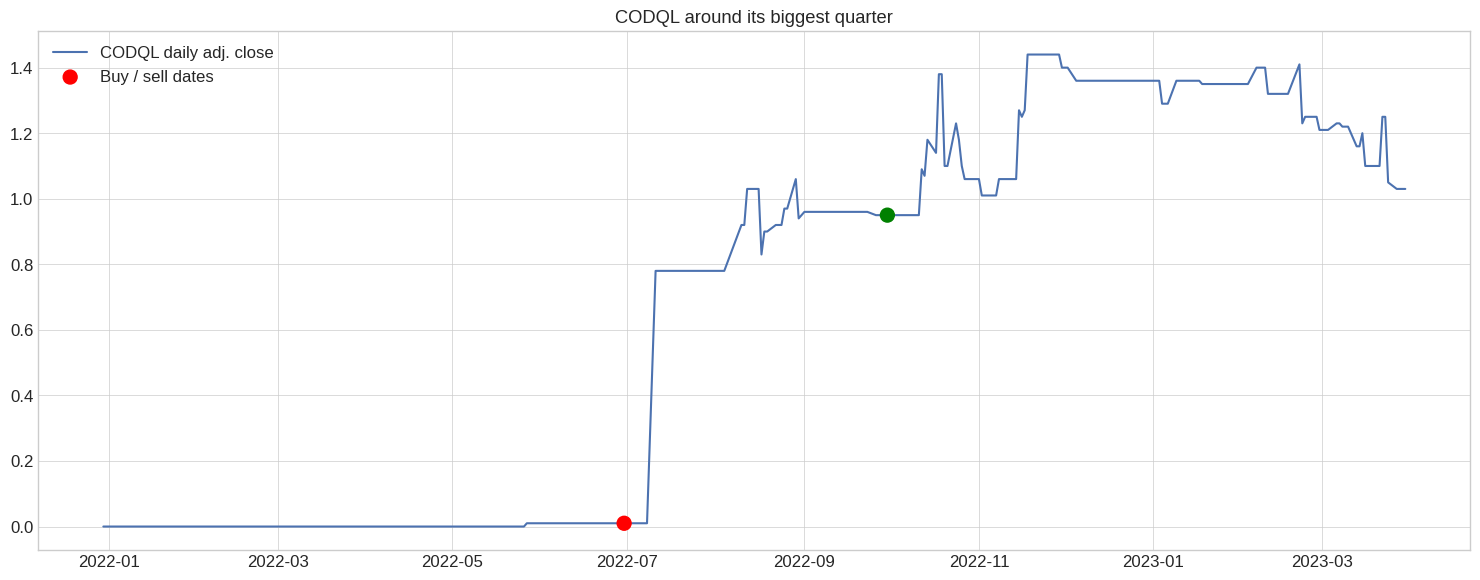

In [ ]:
all_results = pd.concat([sector_results, ladder_results], ignore_index=True)
spike = all_results.loc[all_results['Best_Stock_Qtr_Return'].idxmax()]
ticker, q_start = spike['Best_Stock'], spike['Best_Stock_Date']
q_end = bt_dates[list(bt_dates).index(q_start) + 1]
print(f"Biggest single-stock quarter: {ticker} returned {spike['Best_Stock_Qtr_Return']:.0%} "
      f"from {q_start.date()} to {q_end.date()} (first seen in: {spike['Stage']}, {spike['Universe']})")

print("\nBiggest spike per stage:")
display(all_results.loc[all_results.groupby('Stage')['Best_Stock_Qtr_Return'].idxmax(),
                        ['Stage', 'Universe', 'Best_Stock', 'Best_Stock_Date', 'Best_Stock_Qtr_Return']]
        .style.format({'Best_Stock_Qtr_Return': '{:.0%}'}))

daily = prices_daily[ticker].dropna()
window = daily.loc[q_start - pd.DateOffset(months=6): q_end + pd.DateOffset(months=6)]
plt.figure(figsize=(15, 6))
plt.plot(window.index, window.values, label=f'{ticker} daily adj. close')
plt.scatter([q_start, q_end], [data_matrices['prices'].at[q_start, ticker], data_matrices['prices'].at[q_end, ticker]],
            color=['red', 'green'], s=100, zorder=5, label='Buy / sell dates')
plt.title(f'{ticker} around its biggest quarter')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### Investigating 'CODQL': The Source of the v1 Spike

In v1, **'CODQL'** returned about **9400%** in Q3 2022 (from about \$0.01 to \$0.95) and caused the portfolio's huge spike. Here is its price again, if it's in this data.

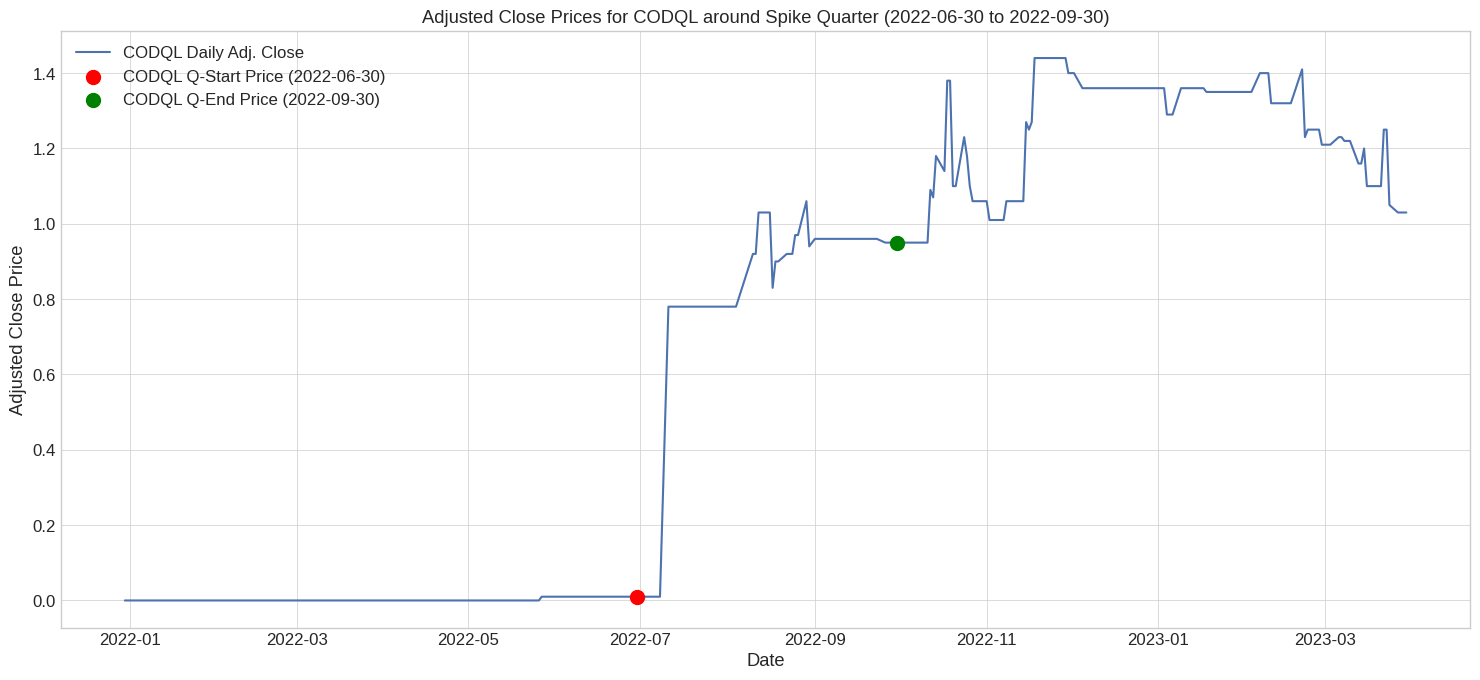


--- Daily Adjusted Close Prices for CODQL during the spike quarter ---


,Adj. Close
Date,
2022-06-30,0.01
2022-07-01,0.01
2022-07-05,0.01
2022-07-06,0.01
2022-07-07,0.01
...,...
2022-09-26,0.95
2022-09-27,0.95
2022-09-28,0.95


In [ ]:
if 'CODQL' in prices_daily.columns:
    import matplotlib.pyplot as plt

    tickers_to_plot = ['CODQL'] # Focus on CODQL
    rebalance_q_start = pd.Timestamp('2022-06-30')
    rebalance_q_end = pd.Timestamp('2022-09-30')

    plt.figure(figsize=(15, 7))

    for ticker in tickers_to_plot:
        # Extract daily prices for the ticker from df_prices
        daily_prices = df_prices.loc[(ticker, slice(None)), 'Adj. Close'].dropna()
        daily_prices.index = daily_prices.index.get_level_values('Date')

        # Filter for a window around the spike period
        plot_start = rebalance_q_start - pd.DateOffset(months=6) # 6 months before
        plot_end = rebalance_q_end + pd.DateOffset(months=6)   # 6 months after
        relevant_prices = daily_prices.loc[plot_start:plot_end]

        plt.plot(relevant_prices.index, relevant_prices.values, label=f'{ticker} Daily Adj. Close')

        # Mark the start and end of the spike quarter with actual quarterly values from data_matrices
        q_start_price = data_matrices['prices'].loc[rebalance_q_start, ticker]
        q_end_price = data_matrices['prices'].loc[rebalance_q_end, ticker]

        plt.scatter(rebalance_q_start, q_start_price, color='red', s=100, zorder=5, label=f'{ticker} Q-Start Price ({rebalance_q_start.strftime("%Y-%m-%d")})')
        plt.scatter(rebalance_q_end, q_end_price, color='green', s=100, zorder=5, label=f'{ticker} Q-End Price ({rebalance_q_end.strftime("%Y-%m-%d")})')

    plt.title(f'Adjusted Close Prices for {", ".join(tickers_to_plot)} around Spike Quarter ({rebalance_q_start.strftime("%Y-%m-%d")} to {rebalance_q_end.strftime("%Y-%m-%d")})')
    plt.xlabel('Date')
    plt.ylabel('Adjusted Close Price')
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.show()

    print(f"\n--- Daily Adjusted Close Prices for {tickers_to_plot[0]} during the spike quarter ---")
    display(daily_prices.loc[rebalance_q_start:rebalance_q_end].to_frame(name='Adj. Close'))
else:
    print("CODQL isn't in this SimFin download.")

## Appendix C: Grid Search and Experiments

### **Detailed Results: Stage 5 (Clean + ROA + ROE)**

The full table for the combined stage, sorted by Sharpe ratio, plus CAGR and Sharpe vs basket size for each sector.

In [ ]:
df_detailed_sweep_results = (sector_results[sector_results['Stage'] == '5. Clean + ROA + ROE']
                             .rename(columns={'Universe': 'Sector'}).reset_index(drop=True))
display(df_detailed_sweep_results.sort_values('Sharpe', ascending=False))

,Stage,Sector,Benchmark,Basket_Size,Ranking_Metric,Rank_Order,CAGR,Bench_CAGR,Excess_CAGR,Beat_Benchmark,Sharpe,Bench_Sharpe,Volatility,Max_Drawdown,Avg_Basket,Cash_Drag_Pct,Delisted_Holdings,Best_Stock_Qtr_Return,Best_Stock,Best_Stock_Date
84,5. Clean + ROA + ROE,Basic Materials,XLB,5,pb,Asc,0.261905,0.049809,0.212096,True,1.038787,0.173004,0.232872,-0.191355,5.000000,0.0,2,0.6963,MOS,2021-12-31
88,5. Clean + ROA + ROE,Basic Materials,XLB,10,equity,Desc,0.245370,0.049809,0.195561,True,0.955971,0.173004,0.235750,-0.232801,9.833333,0.0,3,0.6963,MOS,2021-12-31
62,5. Clean + ROA + ROE,Industrials,XLI,5,mcap,Desc,0.181863,0.122221,0.059642,True,0.897584,0.599506,0.180332,-0.212129,5.000000,0.0,0,0.7017,UAL,2024-09-30
89,5. Clean + ROA + ROE,Basic Materials,XLB,10,mcap,Desc,0.212320,0.049809,0.162511,True,0.819692,0.173004,0.234625,-0.233761,9.833333,0.0,1,0.6963,MOS,2021-12-31
91,5. Clean + ROA + ROE,Basic Materials,XLB,50,equity,Desc,0.173909,0.049809,0.124100,True,0.798402,0.173004,0.192771,-0.189464,14.277778,0.0,4,0.6963,MOS,2021-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,5. Clean + ROA + ROE,Business Services,IYZ,10,mcap,Desc,-0.201185,0.022667,-0.223852,False,-1.082978,0.015466,0.204238,-0.671755,4.611111,0.0,0,0.2569,PLUS,2023-09-30
129,5. Clean + ROA + ROE,Business Services,IYZ,100,pb,Asc,-0.201185,0.022667,-0.223852,False,-1.082978,0.015466,0.204238,-0.671755,4.611111,0.0,0,0.2569,PLUS,2023-09-30
131,5. Clean + ROA + ROE,Business Services,IYZ,100,mcap,Desc,-0.201185,0.022667,-0.223852,False,-1.082978,0.015466,0.204238,-0.671755,4.611111,0.0,0,0.2569,PLUS,2023-09-30
122,5. Clean + ROA + ROE,Business Services,IYZ,5,mcap,Desc,-0.183727,0.022667,-0.206394,False,-1.086587,0.015466,0.187493,-0.638215,4.166667,0.0,0,0.2569,PLUS,2023-09-30


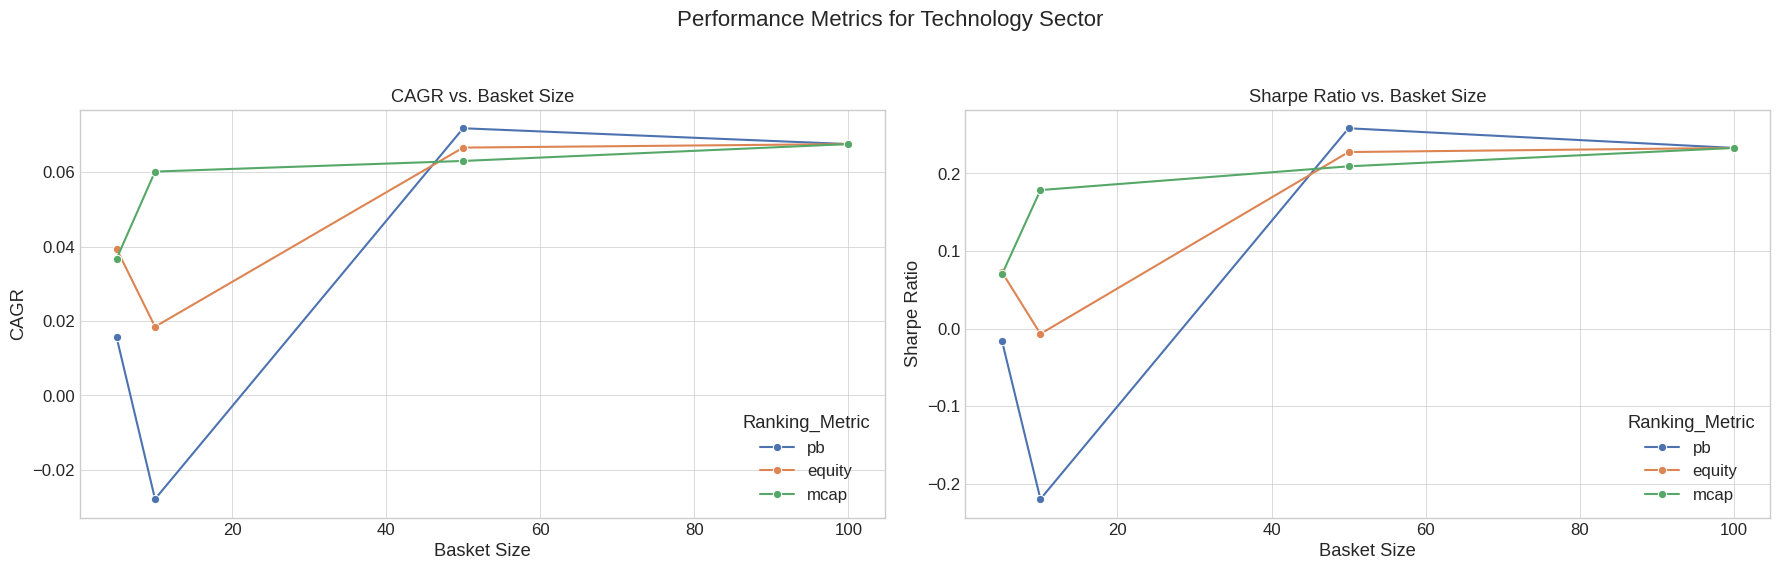

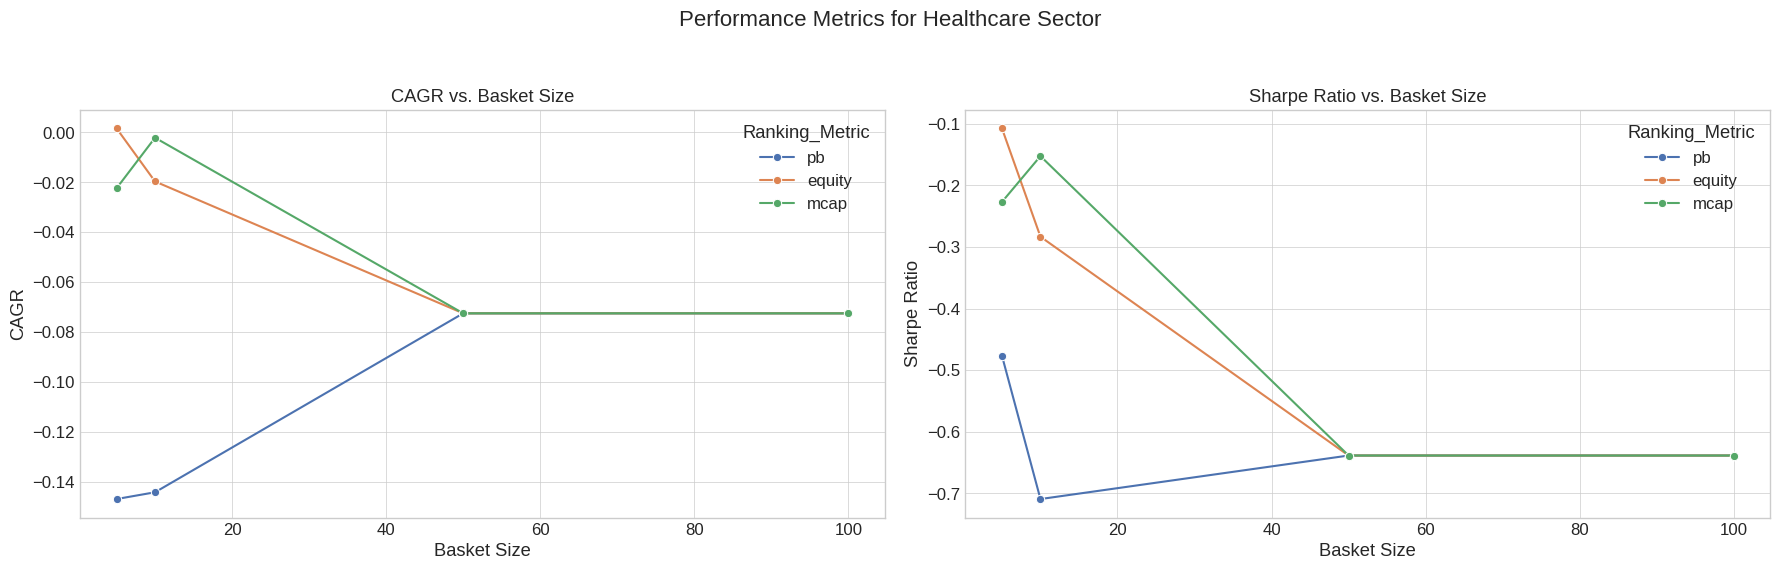

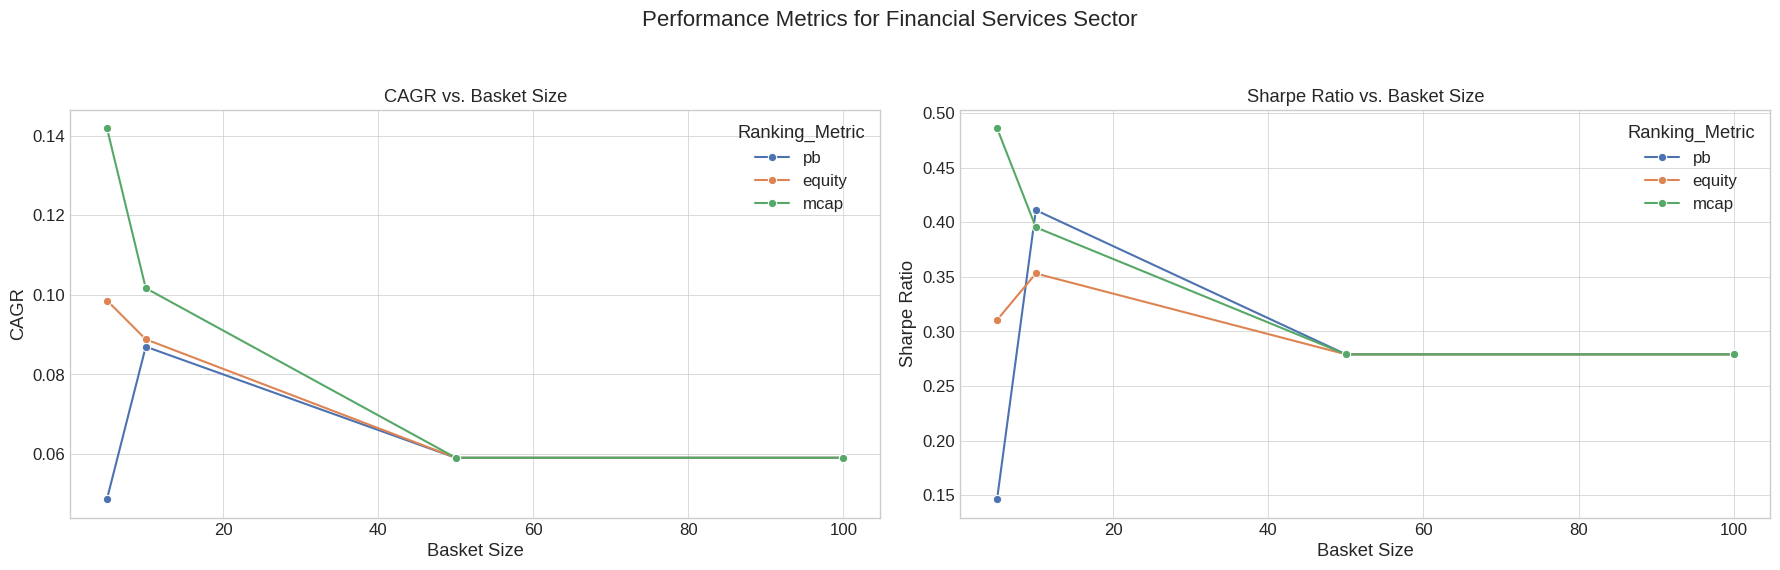

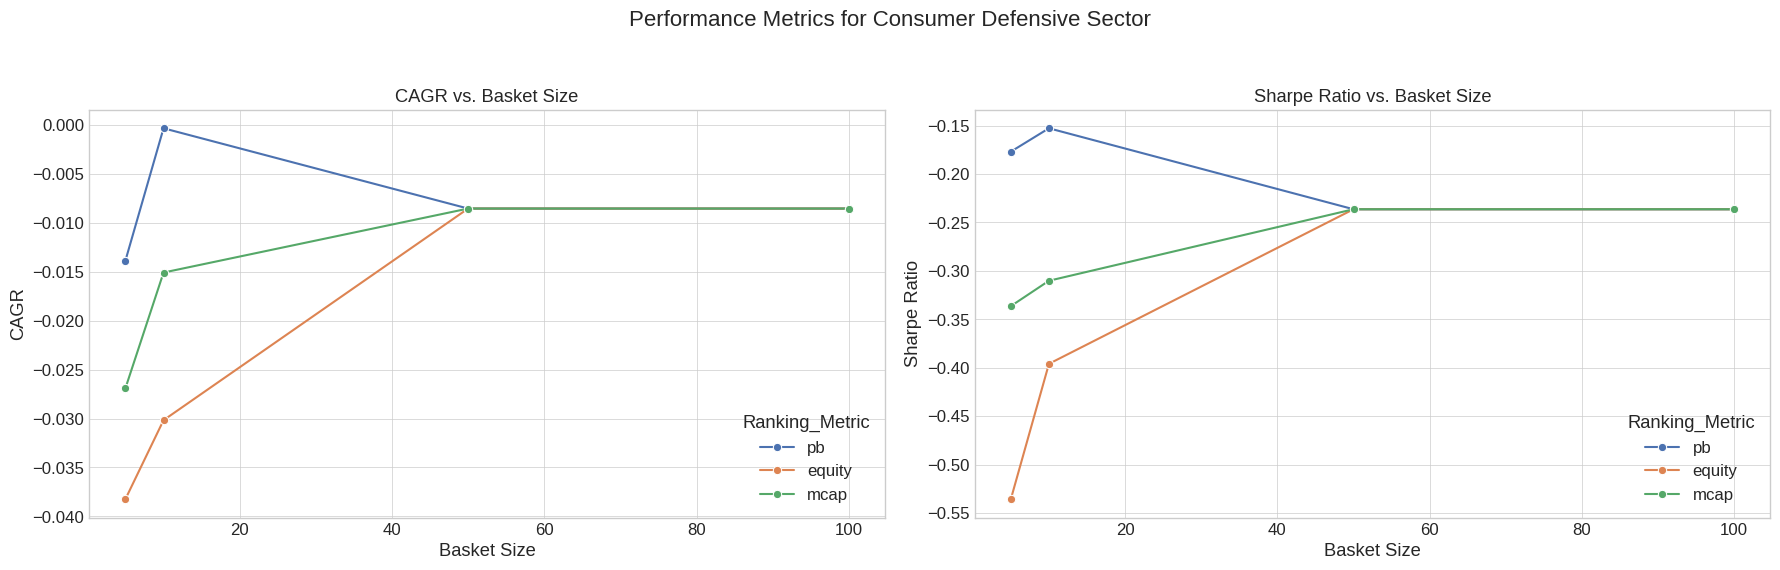

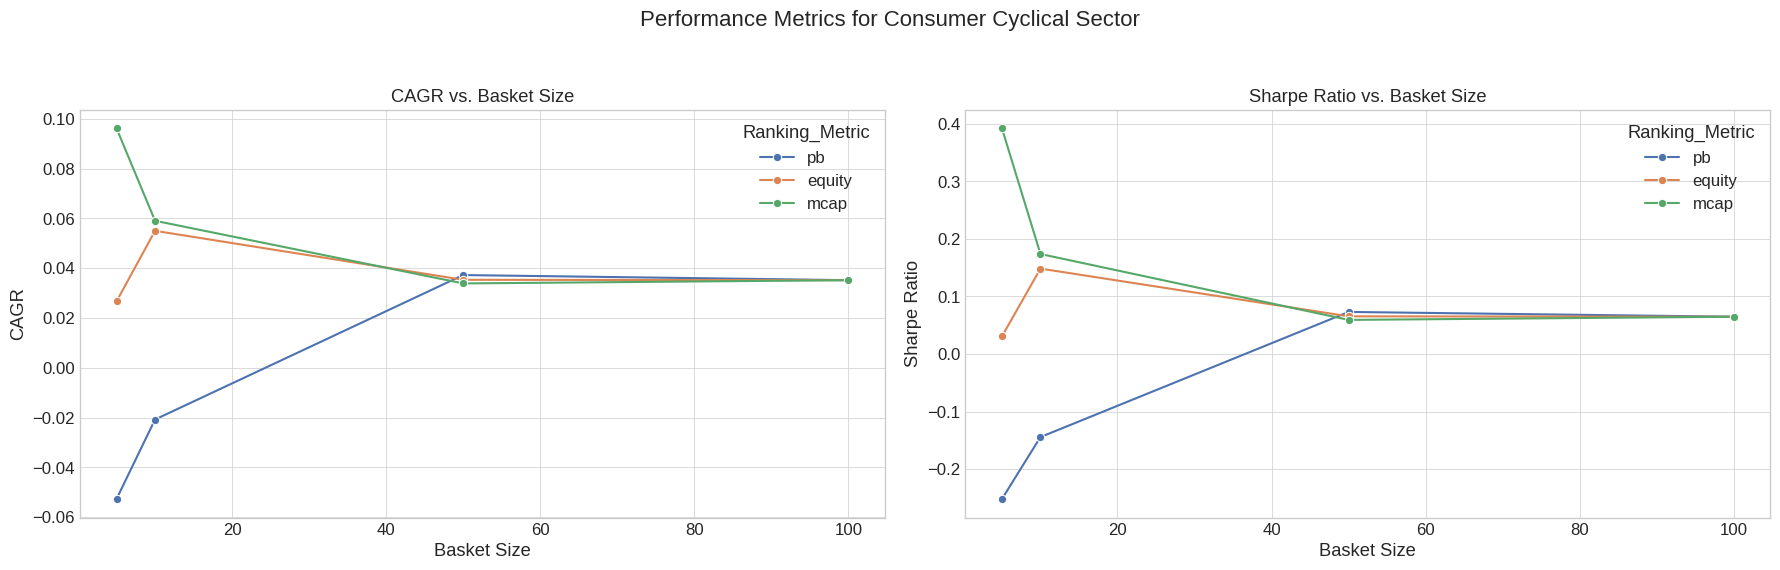

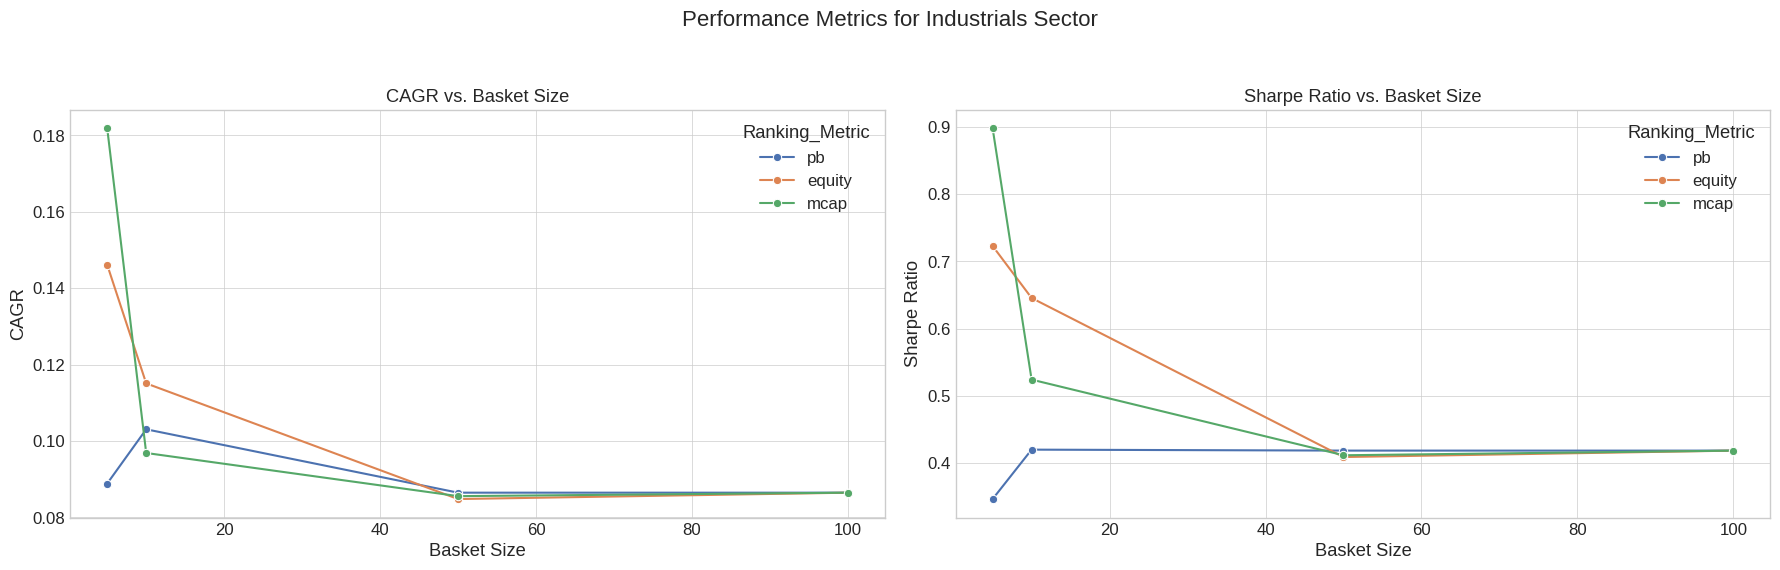

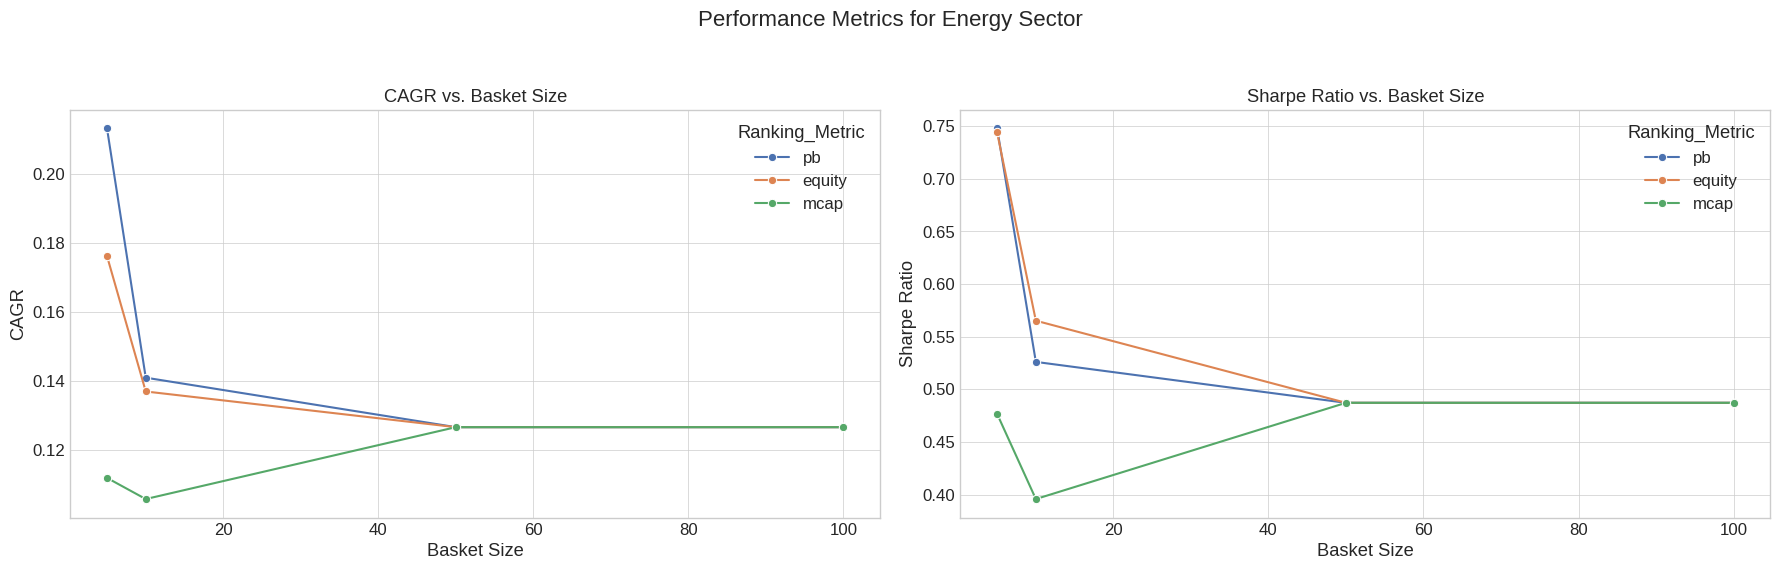

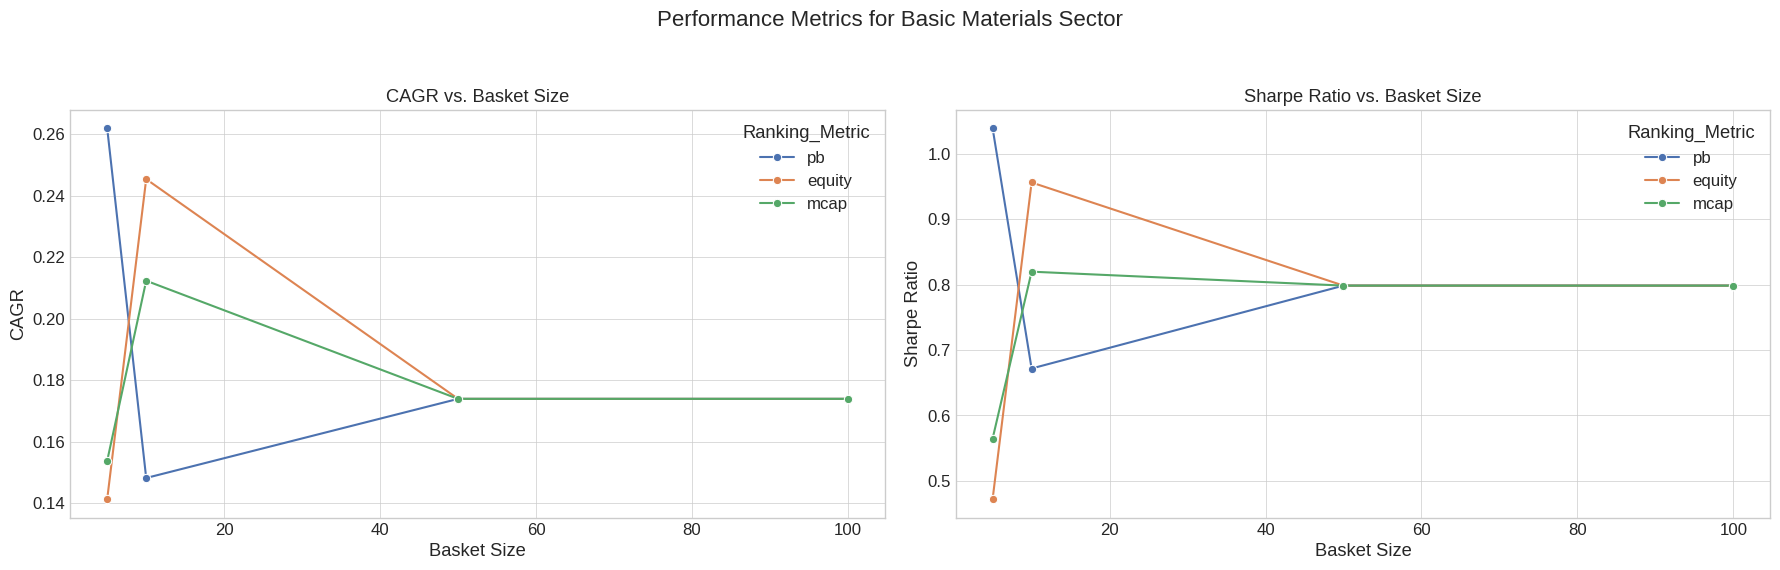

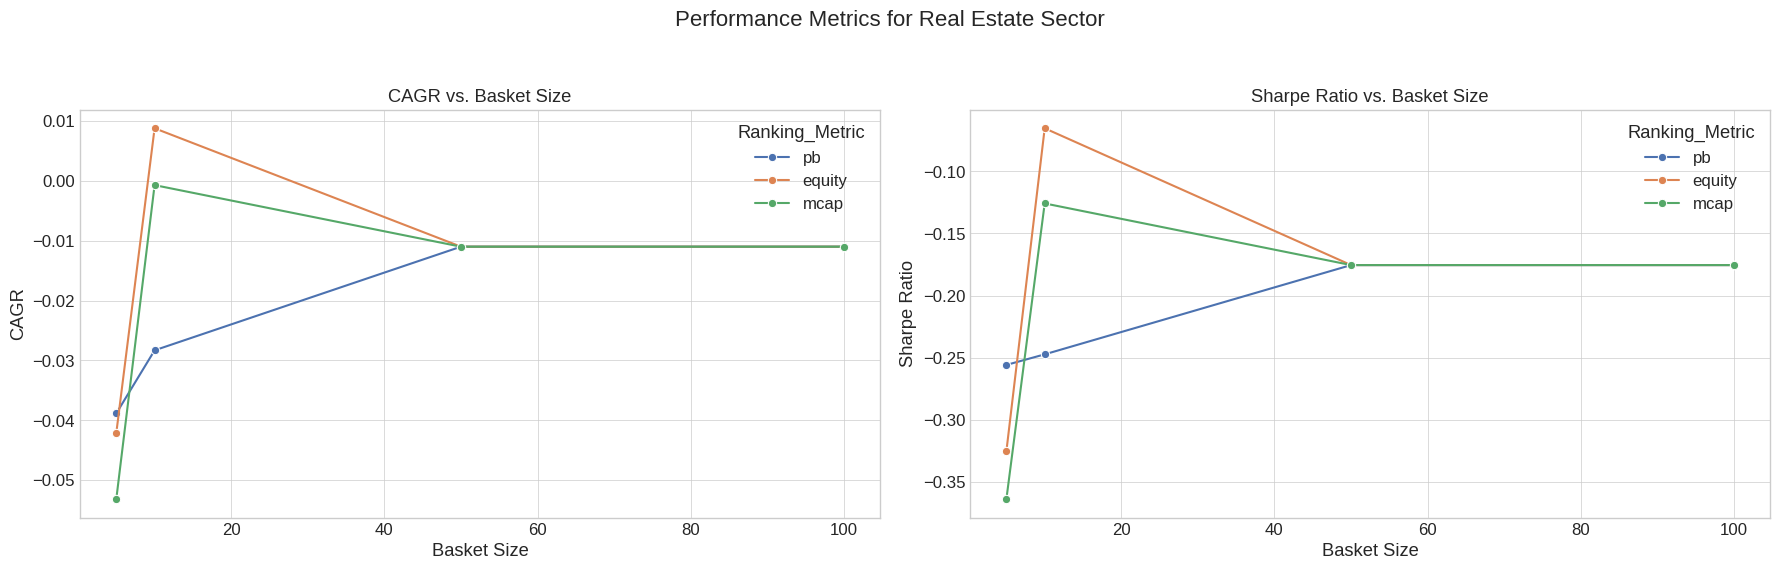

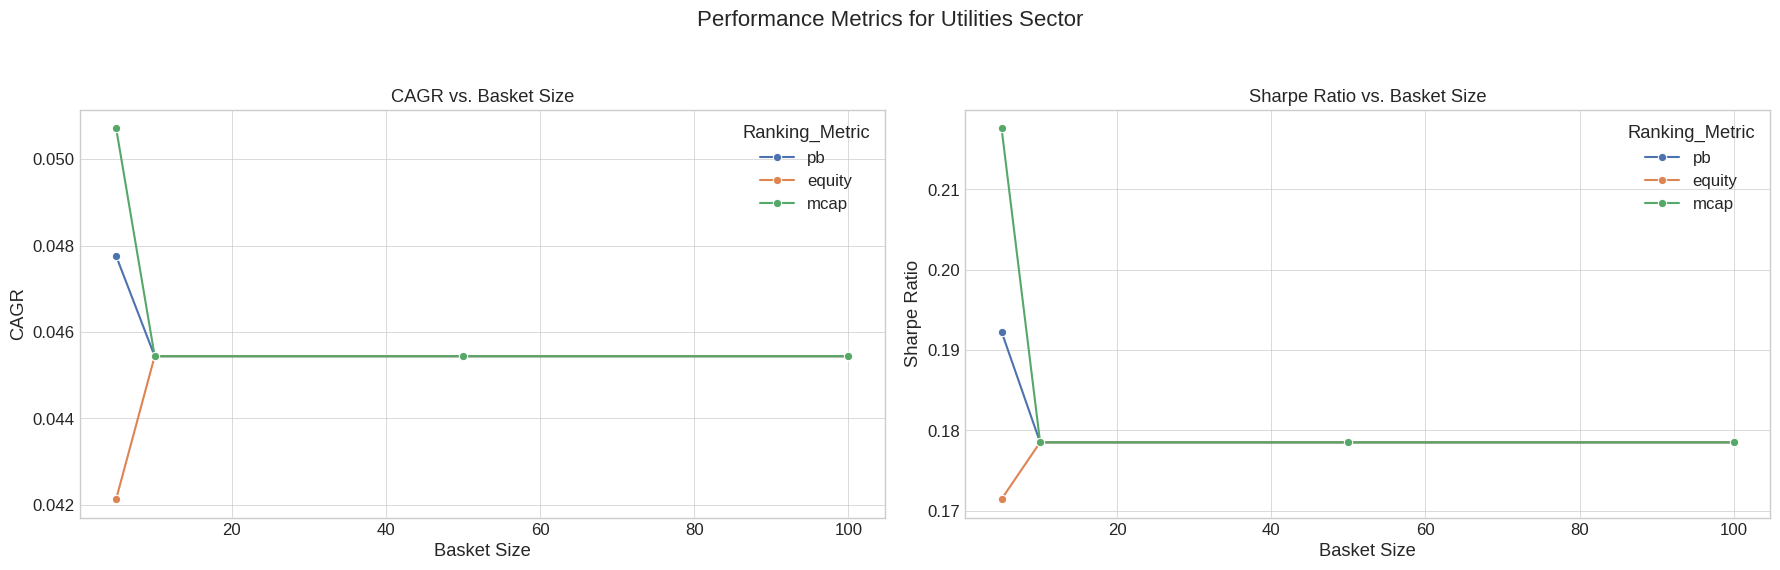

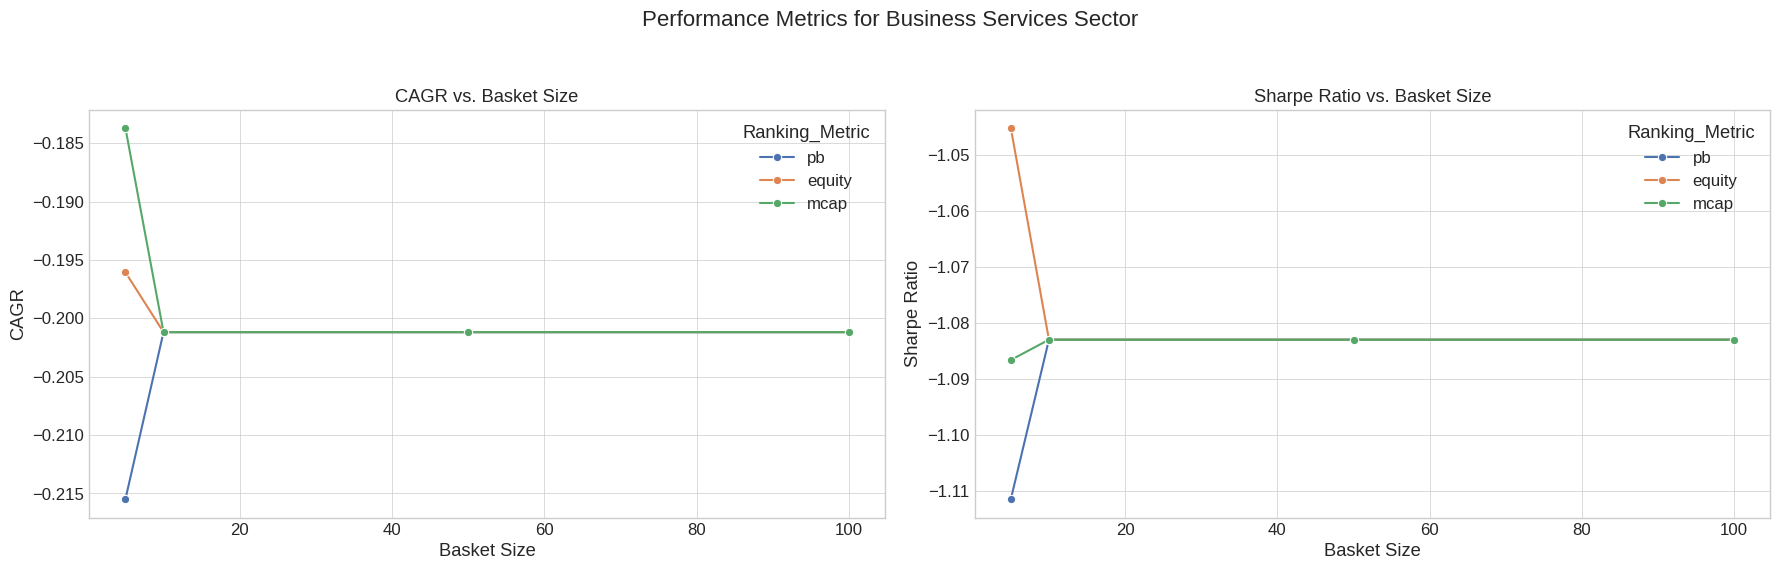

✅ Plots generated for all sectors.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_sectors = df_detailed_sweep_results['Sector'].unique()

for sector in unique_sectors:
    sector_df = df_detailed_sweep_results[df_detailed_sweep_results['Sector'] == sector]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)
    fig.suptitle(f'Performance Metrics for {sector} Sector', fontsize=16)

    # Plot CAGR
    sns.lineplot(
        data=sector_df,
        x='Basket_Size',
        y='CAGR',
        hue='Ranking_Metric',
        marker='o',
        ax=axes[0]
    )
    axes[0].set_title('CAGR vs. Basket Size')
    axes[0].set_ylabel('CAGR')
    axes[0].set_xlabel('Basket Size')
    axes[0].grid(True)

    # Plot Sharpe Ratio
    sns.lineplot(
        data=sector_df,
        x='Basket_Size',
        y='Sharpe',
        hue='Ranking_Metric',
        marker='o',
        ax=axes[1]
    )
    axes[1].set_title('Sharpe Ratio vs. Basket Size')
    axes[1].set_ylabel('Sharpe Ratio')
    axes[1].set_xlabel('Basket Size')
    axes[1].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("✅ Plots generated for all sectors.")

### Summary of Performance Against Broader Index

To provide a high-level overview, let's look at the average performance of the strategies across all sectors and compare them to their respective benchmarks. We'll also identify the overall best-performing strategy from the sweep.

In [ ]:

# Calculate average performance across all strategy combinations
avg_strategy_cagr = df_detailed_sweep_results['CAGR'].mean()
avg_strategy_sharpe = df_detailed_sweep_results['Sharpe'].mean()

# Calculate average performance across all benchmarks
avg_benchmark_cagr = df_detailed_sweep_results['Bench_CAGR'].mean()

print("\n--- Overall Performance Summary ---")
print(f"Average Strategy CAGR across all combinations: {avg_strategy_cagr:.2%}")
print(f"Average Benchmark CAGR across all sectors:    {avg_benchmark_cagr:.2%}")
print(f"Average Strategy Sharpe Ratio across all combinations: {avg_strategy_sharpe:.2f}")

# Identify the best performing strategy based on Sharpe Ratio
best_strategy = df_detailed_sweep_results.sort_values('Sharpe', ascending=False).iloc[0]

print("\n--- Top Performing Strategy (by Sharpe Ratio) ---")
print(f"Sector:           {best_strategy['Sector']}")
print(f"Benchmark:        {best_strategy['Benchmark']}")
print(f"Basket Size:      {best_strategy['Basket_Size']}")
print(f"Ranking Metric:   {best_strategy['Ranking_Metric']}")
print(f"Rank Order:       {best_strategy['Rank_Order']}")
print(f"CAGR:             {best_strategy['CAGR']:.2%}")
print(f"Benchmark CAGR:   {best_strategy['Bench_CAGR']:.2%}")
print(f"Sharpe Ratio:     {best_strategy['Sharpe']:.2f}")
print(f"Volatility:       {best_strategy['Volatility']:.2%}")
print(f"Max Drawdown:     {best_strategy['Max_Drawdown']:.2%}")

if best_strategy['CAGR'] > best_strategy['Bench_CAGR']:
    print("\nConclusion: The top strategy significantly outperformed its benchmark in terms of CAGR.")
elif best_strategy['CAGR'] < best_strategy['Bench_CAGR']:
    print("\nConclusion: The top strategy underperformed its benchmark in terms of CAGR, but still achieved a high Sharpe Ratio.")
else:
    print("\nConclusion: The top strategy performed similarly to its benchmark in terms of CAGR.")

# Identify the worst performing strategy based on Sharpe Ratio
worst_strategy = df_detailed_sweep_results.sort_values('Sharpe', ascending=True).iloc[0]

print("\n--- Worst Performing Strategy (by Sharpe Ratio) ---")
print(f"Sector:           {worst_strategy['Sector']}")
print(f"Benchmark:        {worst_strategy['Benchmark']}")
print(f"Basket Size:      {worst_strategy['Basket_Size']}")
print(f"Ranking Metric:   {worst_strategy['Ranking_Metric']}")
print(f"Rank Order:       {worst_strategy['Rank_Order']}")
print(f"CAGR:             {worst_strategy['CAGR']:.2%}")
print(f"Benchmark CAGR:   {worst_strategy['Bench_CAGR']:.2%}")
print(f"Sharpe Ratio:     {worst_strategy['Sharpe']:.2f}")
print(f"Volatility:       {worst_strategy['Volatility']:.2%}")
print(f"Max Drawdown:     {worst_strategy['Max_Drawdown']:.2%}")

if worst_strategy['CAGR'] > worst_strategy['Bench_CAGR']:
    print("\nConclusion: The worst strategy still managed to outperform its benchmark in terms of CAGR, but with lower risk-adjusted returns.")
elif worst_strategy['CAGR'] < worst_strategy['Bench_CAGR']:
    print("\nConclusion: The worst strategy significantly underperformed its benchmark in terms of CAGR and also had poor risk-adjusted returns.")
else:
    print("\nConclusion: The worst strategy performed similarly to its benchmark in terms of CAGR, but with lower risk-adjusted returns.")



--- Overall Performance Summary ---
Average Strategy CAGR across all combinations: 2.97%
Average Benchmark CAGR across all sectors:    9.62%
Average Strategy Sharpe Ratio across all combinations: 0.04

--- Top Performing Strategy (by Sharpe Ratio) ---
Sector:           Basic Materials
Benchmark:        XLB
Basket Size:      5
Ranking Metric:   pb
Rank Order:       Asc
CAGR:             26.19%
Benchmark CAGR:   4.98%
Sharpe Ratio:     1.04
Volatility:       23.29%
Max Drawdown:     -19.14%

Conclusion: The top strategy significantly outperformed its benchmark in terms of CAGR.

--- Worst Performing Strategy (by Sharpe Ratio) ---
Sector:           Business Services
Benchmark:        IYZ
Basket Size:      5
Ranking Metric:   pb
Rank Order:       Asc
CAGR:             -21.55%
Benchmark CAGR:   2.27%
Sharpe Ratio:     -1.11
Volatility:       21.19%
Max Drawdown:     -69.74%

Conclusion: The worst strategy significantly underperformed its benchmark in terms of CAGR and also had poor risk-ad

### **Comparison of ROA Filtering: Absolute Value vs. Percentile**

This cell conducts an experiment to compare the impact of two different Return on Assets (ROA) filtering methods on backtest performance: using an absolute minimum ROA value and using a minimum ROA percentile. It runs two separate backtests with identical parameters except for the ROA filter and presents a comparison summary of key performance metrics for each experiment.

In [ ]:
TARGET_SECTOR = "Energy"
ETF_BENCHMARK = "XLE"
BASKET_SIZE = 10

base = {**CLEAN, 'ranking_metric': 'pb', 'rank_order': 'Asc', 'basket_size': BASKET_SIZE}
experiments = {
    'Min ROA = 0.01 (absolute)': {**base, 'min_roa': 0.01},
    'Min ROA Percentile = 50':   {**base, 'min_roa_percentile_level': 50},
}

comparison_results = []
for name, kw in experiments.items():
    p, b, _ = run_backtest(TARGET_SECTOR, ETF_BENCHMARK, selector_pb_roa, **kw)
    comparison_results.append({'Experiment': name, 'CAGR': calc_cagr(p), 'Bench_CAGR': calc_cagr(b),
                               'Sharpe': calc_sharpe_ratio(p), 'Volatility': calc_annualized_volatility(p),
                               'Max_Drawdown': calc_max_drawdown(p)})

df_comparison = pd.DataFrame(comparison_results)
print(f"\n--- Comparison Summary for {TARGET_SECTOR} Sector (Basket Size {BASKET_SIZE}) ---")
display(df_comparison.style.format({'CAGR': '{:.2%}', 'Bench_CAGR': '{:.2%}', 'Sharpe': '{:.2f}',
                                    'Volatility': '{:.2%}', 'Max_Drawdown': '{:.2%}'})
        .set_caption("ROA Filter Impact Comparison"))


--- Comparison Summary for Energy Sector (Basket Size 10) ---


,Experiment,CAGR,Bench_CAGR,Sharpe,Volatility,Max_Drawdown
0,Min ROA = 0.01 (absolute),11.95%,18.64%,0.41,24.28%,-21.28%
1,Min ROA Percentile = 50,15.27%,18.64%,0.54,24.71%,-21.37%


### **Part B Grid Search (Top 500, on the Trade-Ready Table)**

Because each setting is just a filter on the table, I can try every combination of: P/B cutoff (none, 75th, 50th, 25th pct), profitability (none, ROA ≥ 0.1%, ROA ≥ 50th pct, ROA ≥ 75th pct), size filters (off/on), and raw vs sector-normalized. All keep the basic checks (positive equity, price ≥ \$1).

With only 18 quarters, the "best" setting here is probably random chance, so I use this to see patterns (which filters help on average), not to pick a winner.

In [ ]:
grid_rows = []
PROFIT = {'none': {}, 'ROA ≥ 0.1%': {'min_roa': 0.001},
          'ROA ≥ 50th pct': {'min_roa_percentile_level': 50}, 'ROA ≥ 75th pct': {'min_roa_percentile_level': 75}}
for pool_name, (pool, metric) in POOLS.items():
    for pb_level in [None, 75, 50, 25]:
        for profit_name, profit_kw in PROFIT.items():
            for size_on in [False, True]:
                kw = {'min_price': 1.0, **profit_kw, 'percentile_pool': pool}
                if pb_level is not None:
                    kw['pb_max_percentile_level'] = pb_level
                if size_on:
                    kw.update({'mcap_min_percentile_level': 25, 'bv_min_percentile_level': 50})
                mask = table_mask(**kw)
                for K in ['All', 50, 10]:
                    p, b, _, sizes = table_backtest(K, mask=mask, percentile_pool=pool)
                    grid_rows.append({'Cutoffs': pool_name, 'P/B filter': 'none' if pb_level is None else f'≤ {pb_level}th pct',
                                      'Profitability': profit_name, 'Size filters': 'on' if size_on else 'off', 'K': K,
                                      'Stocks passing (avg)': mask.groupby(T['Date']).sum().mean(),
                                      'CAGR': calc_cagr(p), 'Excess vs SPY': calc_cagr(p) - calc_cagr(b),
                                      'Volatility': calc_annualized_volatility(p), 'Sharpe': calc_sharpe_ratio(p),
                                      'Max drawdown': calc_max_drawdown(p), 'Avg held': sizes.mean()})
grid_b = pd.DataFrame(grid_rows)
print(f"{len(grid_b)} portfolios. Beat SPY: {(grid_b['Excess vs SPY'] > 0).mean():.0%}")
fmt = {'CAGR': '{:.2%}', 'Excess vs SPY': '{:+.2%}', 'Volatility': '{:.2%}', 'Sharpe': '{:.2f}',
       'Max drawdown': '{:.2%}', 'Avg held': '{:.1f}', 'Stocks passing (avg)': '{:.0f}'}

for K in ['All', 50]:
    print(f"\nAverage CAGR by filter choice (K={K}, averaged over the other settings):")
    g = grid_b[grid_b['K'] == K]
    for col in ['Cutoffs', 'P/B filter', 'Profitability', 'Size filters']:
        display(g.groupby(col, sort=False)[['CAGR', 'Excess vs SPY', 'Volatility', 'Sharpe', 'Stocks passing (avg)']]
                .mean().style.format(fmt))

print("\nCAGR matrix, K=50: P/B filter (rows) x profitability filter (columns),")
print("each cell averaged over raw/sector-normalized cutoffs and size filters on/off:")
pivot = (grid_b[grid_b['K'] == 50]
         .pivot_table(index='P/B filter', columns='Profitability', values='CAGR', aggfunc='mean', sort=False))
pivot['Row average'] = pivot.mean(axis=1)
pivot.loc['Column average'] = pivot.mean(axis=0)
display(pivot.style.format('{:.2%}'))

print("\nTop 10 and bottom 10 by Sharpe (K=50):")
g50 = grid_b[grid_b['K'] == 50].sort_values('Sharpe', ascending=False)
display(g50.head(10).style.format(fmt)); display(g50.tail(10).style.format(fmt))

192 portfolios. Beat SPY: 22%

Average CAGR by filter choice (K=All, averaged over the other settings):


,CAGR,Excess vs SPY,Volatility,Sharpe,Stocks passing (avg)
Cutoffs,,,,,
Raw,12.05%,-1.76%,15.40%,0.63,133
Sector-normalized,10.22%,-3.59%,15.45%,0.52,134


,CAGR,Excess vs SPY,Volatility,Sharpe,Stocks passing (avg)
P/B filter,,,,,
none,10.66%,-3.15%,15.56%,0.55,224
≤ 75th pct,10.12%,-3.68%,15.45%,0.52,165
≤ 50th pct,10.54%,-3.27%,15.12%,0.55,104
≤ 25th pct,13.21%,-0.59%,15.57%,0.68,42


,CAGR,Excess vs SPY,Volatility,Sharpe,Stocks passing (avg)
Profitability,,,,,
none,8.16%,-5.65%,14.31%,0.43,218
ROA ≥ 0.1%,8.70%,-5.10%,13.79%,0.49,187
ROA ≥ 50th pct,11.98%,-1.82%,15.41%,0.65,92
ROA ≥ 75th pct,15.69%,+1.88%,18.20%,0.74,38


,CAGR,Excess vs SPY,Volatility,Sharpe,Stocks passing (avg)
Size filters,,,,,
off,10.93%,-2.87%,15.66%,0.56,173
on,11.33%,-2.47%,15.19%,0.60,94


...


CAGR matrix, K=50: P/B filter (rows) x profitability filter (columns),
each cell averaged over raw/sector-normalized cutoffs and size filters on/off:


Profitability,none,ROA ≥ 0.1%,ROA ≥ 50th pct,ROA ≥ 75th pct,Row average
P/B filter,,,,,
none,9.15%,7.83%,11.07%,14.22%,10.57%
≤ 75th pct,9.15%,7.83%,11.07%,14.16%,10.55%
≤ 50th pct,9.15%,7.83%,10.95%,15.96%,10.97%
≤ 25th pct,9.27%,7.73%,14.88%,20.25%,13.03%
Column average,9.18%,7.81%,11.99%,16.15%,11.28%



Top 10 and bottom 10 by Sharpe (K=50):


,Cutoffs,P/B filter,Profitability,Size filters,K,Stocks passing (avg),CAGR,Excess vs SPY,Volatility,Sharpe,Max drawdown,Avg held
94,Raw,≤ 25th pct,ROA ≥ 75th pct,on,50,5,29.91%,+16.10%,22.95%,1.22,-17.74%,5.2
85,Raw,≤ 25th pct,ROA ≥ 50th pct,off,50,23,19.78%,+5.98%,15.36%,1.16,-15.85%,23.3
91,Raw,≤ 25th pct,ROA ≥ 75th pct,off,50,8,27.10%,+13.29%,21.81%,1.15,-17.81%,7.6
88,Raw,≤ 25th pct,ROA ≥ 50th pct,on,50,16,18.61%,+4.80%,16.09%,1.03,-16.09%,15.6
163,Sector-normalized,≤ 50th pct,ROA ≥ 75th pct,off,50,26,17.85%,+4.05%,17.23%,0.92,-22.18%,26.4
166,Sector-normalized,≤ 50th pct,ROA ≥ 75th pct,on,50,16,16.02%,+2.21%,16.93%,0.83,-22.15%,15.8
187,Sector-normalized,≤ 25th pct,ROA ≥ 75th pct,off,50,8,15.39%,+1.59%,16.91%,0.79,-18.34%,7.5
115,Sector-normalized,none,ROA ≥ 75th pct,off,50,116,15.34%,+1.53%,16.91%,0.79,-22.80%,50.0
139,Sector-normalized,≤ 75th pct,ROA ≥ 75th pct,off,50,65,15.34%,+1.53%,16.91%,0.79,-22.80%,50.0
67,Raw,≤ 50th pct,ROA ≥ 75th pct,off,50,23,15.87%,+2.06%,19.01%,0.73,-26.42%,22.6


,Cutoffs,P/B filter,Profitability,Size filters,K,Stocks passing (avg),CAGR,Excess vs SPY,Volatility,Sharpe,Max drawdown,Avg held
178,Sector-normalized,≤ 25th pct,ROA ≥ 0.1%,on,50,49,6.77%,-7.03%,13.14%,0.36,-19.58%,46.7
172,Sector-normalized,≤ 25th pct,none,on,50,61,7.23%,-6.57%,14.50%,0.36,-20.73%,50.0
190,Sector-normalized,≤ 25th pct,ROA ≥ 75th pct,on,50,5,8.59%,-5.22%,18.82%,0.35,-25.40%,4.6
148,Sector-normalized,≤ 50th pct,none,on,50,138,6.76%,-7.05%,14.69%,0.32,-22.66%,50.0
100,Sector-normalized,none,none,on,50,225,6.76%,-7.05%,14.69%,0.32,-22.66%,50.0
124,Sector-normalized,≤ 75th pct,none,on,50,191,6.76%,-7.05%,14.69%,0.32,-22.66%,50.0
127,Sector-normalized,≤ 75th pct,ROA ≥ 0.1%,off,50,291,5.32%,-8.48%,13.81%,0.24,-20.66%,50.0
103,Sector-normalized,none,ROA ≥ 0.1%,off,50,399,5.32%,-8.48%,13.81%,0.24,-20.66%,50.0
151,Sector-normalized,≤ 50th pct,ROA ≥ 0.1%,off,50,187,5.32%,-8.48%,13.81%,0.24,-20.66%,50.0
175,Sector-normalized,≤ 25th pct,ROA ≥ 0.1%,off,50,78,4.99%,-8.81%,13.68%,0.22,-20.66%,50.0


## Appendix D: Report Tables

The full numbers I use in the write-up. For each stage and sector: the benchmark ETF, then baskets of 5, 10, 50 and 100 stocks ranked by cheapest P/B, biggest market cap or biggest book value. "Avg Qtr Return" is the average quarterly return (μ). "Alpha" is the return left over after accounting for how much the basket moves with its benchmark (beta). The "ALL SECTORS" rows are simple averages across the 11 sectors.

In [ ]:
pd.set_option('display.width', 250)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 30)

PCT_COLS = ['CAGR', 'Volatility', 'Max_DD', 'Avg_Qtr_Return', 'Alpha']
def show(df):
    fm = {c: (lambda x: '' if pd.isna(x) else f'{x:.2%}') for c in PCT_COLS if c in df.columns}
    fm['Sharpe'] = lambda x: f'{x:.2f}'
    print(df.to_string(index=False, formatters=fm))

def stats_row(p, b=None):
    row = {'CAGR': calc_cagr(p), 'Volatility': calc_annualized_volatility(p), 'Sharpe': calc_sharpe_ratio(p),
           'Max_DD': calc_max_drawdown(p), 'Avg_Qtr_Return': p.mean(), 'Alpha': np.nan}
    if b is not None:
        row['Alpha'] = calc_alpha(p, b)[0]
    return row

def report_table(stage, returns, universes, sizes=(5, 10, 50, 100), metrics=('pb', 'mcap', 'equity')):
    rows = []
    for u, bench in universes.items():
        b = returns[(stage, u, sizes[0], metrics[0])][1]
        rows.append({'Universe': u, 'K': '-', 'Metric': f'Benchmark {bench}', **stats_row(b)})
        for K in sizes:
            for m in metrics:
                p, b = returns[(stage, u, K, m)]
                rows.append({'Universe': u, 'K': K, 'Metric': m, **stats_row(p, b)})
    df = pd.DataFrame(rows)
    agg = df.assign(Metric=df['Metric'].where(df['K'] != '-', 'Benchmark')).groupby(['K', 'Metric'], sort=False)[
        ['CAGR', 'Volatility', 'Sharpe', 'Max_DD', 'Avg_Qtr_Return', 'Alpha']].mean().reset_index()
    agg.insert(0, 'Universe', 'ALL SECTORS (avg)')
    return pd.concat([df, agg], ignore_index=True)

print(f"Backtest window: picks from {bt_dates[0].date()} to {bt_dates[-2].date()}, "
      f"returns through {bt_dates[-1].date()} ({len(bt_dates) - 1} quarters)\n")
for stage in ['1. Pure P/B', '2. Clean P/B', '3. Clean + ROA', '4. Clean + ROE']:  # stage 5 = stage 3
    print('=' * 110 + f'\n{stage}\n' + '=' * 110)
    show(report_table(stage, sector_returns, SECTOR_UNIVERSES))
    print()
print("(Stage 5 'Clean + ROA + ROE' is identical to stage 3.)\n")

print('=' * 110 + '\nROA vs ROE, 5 stocks, cheapest P/B\n' + '=' * 110)
rows = []
for u in SECTOR_UNIVERSES:
    pa, _ = sector_returns[('3. Clean + ROA', u, 5, 'pb')]
    pe, _ = sector_returns[('4. Clean + ROE', u, 5, 'pb')]
    rows.append({'Sector': u, 'ROA_CAGR': calc_cagr(pa), 'ROE_CAGR': calc_cagr(pe), 'Delta': calc_cagr(pe) - calc_cagr(pa),
                 'ROA_Vol': calc_annualized_volatility(pa), 'ROE_Vol': calc_annualized_volatility(pe),
                 'ROA_Sharpe': calc_sharpe_ratio(pa), 'ROE_Sharpe': calc_sharpe_ratio(pe)})
roa_roe = pd.DataFrame(rows)
print(roa_roe.to_string(index=False, formatters={c: (lambda x: f'{x:.2%}') for c in ['ROA_CAGR', 'ROE_CAGR', 'Delta', 'ROA_Vol', 'ROE_Vol']}
                        | {c: (lambda x: f'{x:.2f}') for c in ['ROA_Sharpe', 'ROE_Sharpe']}))
print()

print('=' * 110 + '\nPart B: top 500 vs SPY (filter ladder)\n' + '=' * 110)
show(pd.DataFrame([{'Universe': 'TOP500', 'K': '-', 'Metric': 'All top 500, equal weight', **stats_row(all500, SPY_RETURNS)}]))
for pool_name, (pool, metric) in POOLS.items():
    for rung, _ in LADDER:
        label = f'{rung} ({pool_name})'
        print('-' * 110 + f'\n{label}')
        show(report_table(label, ladder_returns, {'TOP500': 'SPY'}, sizes=tuple(LADDER_SIZES), metrics=(metric,)))
        print("  stocks held each quarter (K=10):",
              ladder_baskets[(label, 10)].groupby('Date').size().reindex(T_DATES).fillna(0).astype(int).tolist())
    print()
print('=' * 110 + '\nWeed-out table (raw / sector-normalized)\n' + '=' * 110)
for pool_name in POOLS:
    print(pool_name)
    print(weed_out_table(pool_name).to_string())
print()
print(checks.to_string(index=False))

Backtest window: picks from 2021-03-31 to 2025-06-30, returns through 2025-09-30 (18 quarters)

1. Pure P/B
          Universe   K         Metric    CAGR Volatility Sharpe  Max_DD Avg_Qtr_Return   Alpha
        Technology   -  Benchmark XLK  19.14%     23.97%   0.71 -31.21%          5.14%     NaN
        Technology   5             pb  68.44%    354.04%   0.19 -52.17%         45.48%  58.91%
        Technology   5           mcap  34.58%     35.79%   0.91 -41.79%          9.14%   8.38%
        Technology   5         equity  18.03%     29.86%   0.54 -42.95%          5.23%  -3.73%
        Technology  10             pb  53.56%    181.59%   0.28 -41.86%         25.24%  38.06%
        Technology  10           mcap  20.97%     28.92%   0.66 -42.29%          5.85%  -1.16%
        Technology  10         equity  20.48%     30.17%   0.61 -41.39%          5.79%  -1.67%
        Technology  50             pb  26.31%     63.93%   0.38 -22.93%          8.98%  16.17%
        Technology  50           mcap